In [75]:
#import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

In [2]:
filename = "data/Interview_export_6.csv"
df_i= pd.read_csv(filename, sep=';', encoding='latin1',decimal=',')
print(f"Loaded {len(df_i)} responses")


Loaded 11 responses


In [3]:

#df_q = pd.read_csv('data/results.csv', sep=';', encoding='utf-8',decimal=',')
df_q = pd.read_csv('data\data-490054-2025-07-01-1620.csv', sep=';', encoding='utf-8',decimal=',') #raw results
print(f"Loaded {len(df_q)} responses")

Loaded 24 responses


In [4]:
# load the IEEE data
df_ieee=pd.read_csv('Data\IEEE_data_export.csv',sep=';',decimal=',',encoding='latin1')
df_ieee_methods = df_ieee[[col for col in df_ieee if col.startswith('method')]].dropna() 
df_ieee_software= df_ieee[[col for col in df_ieee if col.startswith('software')]].dropna()
df_ieee_feature= df_ieee[[col for col in df_ieee if col.startswith('feature')]].dropna() 
df_ieee_indicators= df_ieee[[col for col in df_ieee if col.startswith('indicator')]].dropna() 
df_ieee_uncertainty= df_ieee[[col for col in df_ieee if col.startswith('uncertainty')]].dropna() 



### Software Comparison

### Software comparison and merging

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ========================================
# 1. CONFIGURATION: Short names and merging
# ========================================
SHORT_NAME_MAPPING = {
    'Netbas (Volue/Powel)': 'Netbas',
    'PSS/E, and/or PSS Sincal': 'PSS/E',
    'Trimble NIS': 'Trimble NIS',
    'Self-developed software': 'In-house/Self-developed',
    'Self-developed': 'In-house/Self-developed',
    'Egentuviklet programvare (Spesifiser under påfølgende spørsmål)': 'In-house/Self-developed',
    'Python libraries (PyPSA, PandaPower)': 'Python lib',
    'Fosweb (National Register)': 'Fosweb',
    'Hitachi Network Manager (SCADA)': 'Scada',
    'Other software': 'Other Software',
    'SIMATIC SCADA Systems og/eller Hitachi Network Manager (Scada), og/eller Spectrum Power': 'Scada',
    'Excel': 'Excel',
    'Aristo': 'Aristo',
    'Matlab & Simulink': 'Matlab',
    'Do not use software': 'None',
    'Eterra': 'Scada',
    'PSAT': 'PSAT',
    'Revisjonsverktøy Internally developed (among DSOs)': 'Revision tool',
    'Samnett': 'Samnett',
    'SSAT': 'SSAT',
    'Promaps': 'Promaps',
    'Power BI': 'Power BI',
    'ETRAN (PSS\\E and PSCAD)': 'PSS/E',
    'SIMATIC SCADA Systems': 'Scada',
    'PowerFactory': 'PowerFactory',
    'PSS/E': 'PSS/E',
    'DMS': 'DMS',
    'Digpro dpPower': 'Digpro',
    'IPSA': 'IPSA',
    'CYMEDIST': 'CYMEDIST',
    'RelyPES': 'RelyPES',
    'Julia Power Tools': 'Julia Power Tools',
    'MatDyn': 'MatDyn',
    'Synergi Electric': 'Synergi Electric',
    'General Electric Digital ADMS': 'DMS',
    'POWSYBL': 'Powsybl',
    'GridLAB-D': 'Gridlab-D',
    'OpenModellica': 'OpenModellica',
    'ETAP Distribution Network Analysis': 'ETAP',
    'DYMOLA': 'DYMOLA',
    'ERACS': 'ERACS',
    'AVEVA Scada': 'Scada',
    'ATP-EMTP and/or EMTP-RV': 'ATP-EMTP',
    'GridCal Sk': 'Gridcal Sk',
    'DINID': 'DINID',
    'Power World': 'Power World',
    'PowerGEM TARA': 'Powergem Tara',
    'MathPower': 'MathPower',
    'Dynawo': 'Dynawo',
    'RTDS, and/or OPAL-RT HYPERSIM': 'OPALRT',
    'SKM Power Tools': 'SKM Power Tools',
    'NEPLAN': 'NEPLAN',
    'CIMPLICITY Scada': 'Scada',
    'PSCAD/EMTDC': 'Pscad/Emtdc',
    'OpenDSS': 'OpenDSS',
}

# Standardize Norwegian names to English
NORWEGIAN_TO_ENGLISH = {
    'PSS/E, og/eller PSS Sincal': 'PSS/E, and/or PSS Sincal',
    'Python bibliotek (PyPSA, PandaPower og/eller PyPower)': 'Python libraries (PyPSA, PandaPower)',
    'RTDS, og/eller OPAL RT HYPERSIM': 'RTDS, and/or OPAL-RT HYPERSIM',
    'Annen programvare (Spesifiser under påfølgende spørsmål)': 'Other software',
    'Egentuviklet programvare (Spesifiser under påfølgende spørsmål)': 'In-house/Self-developed',
    'Bruker ikke programvare': 'Do not use software',
}

# Questionnaire column mapping
SOFTWARE_MAPPING = {
    'software_type.1': 'ATP-EMTP and/or EMTP-RV',
    'software_type.2': 'AVEVA Scada',
    'software_type.3': 'CIMPLICITY Scada',
    'software_type.4': 'CYMEDIST',
    'software_type.5': 'Digpro dpPower',
    'software_type.6': 'DINID',
    'software_type.7': 'DYMOLA',
    'software_type.8': 'Dynawo',
    'software_type.9': 'ERACS',
    'software_type.10': 'ETAP Distribution Network Analysis',
    'software_type.11': 'ETRAN (PSS\\E and PSCAD)',
    'software_type.12': 'General Electric Digital ADMS',
    'software_type.13': 'GridCal Sk',
    'software_type.14': 'GridLAB-D',
    'software_type.15': 'Hitachi Network Manager (SCADA)',
    'software_type.16': 'IPSA',
    'software_type.17': 'Joulia',
    'software_type.18': 'Julia Power Tools',
    'software_type.19': 'MatDyn',
    'software_type.20': 'MathPower',
    'software_type.21': 'Matlab & Simulink',
    'software_type.22': 'NEPLAN',
    'software_type.23': 'Netbas (Volue/Powel)',
    'software_type.24': 'OpenDSS',
    'software_type.25': 'OpenModellica',
    'software_type.26': 'Power World',
    'software_type.27': 'PowerFactory',
    'software_type.28': 'PowerGEM TARA',
    'software_type.29': 'POWSYBL',
    'software_type.30': 'PSAT',
    'software_type.31': 'PSCAD/EMTDC',
    'software_type.32': 'PSS/E, and/or PSS Sincal',
    'software_type.33': 'Python libraries (PyPSA, PandaPower)',
    'software_type.34': 'RelyPES',
    'software_type.35': 'RTDS, and/or OPAL-RT HYPERSIM',
    'software_type.36': 'SIMATIC SCADA Systems',
    'software_type.37': 'SKM Power Tools',
    'software_type.38': 'Synergi Electric',
    'software_type.39': 'Trimble NIS',
    'software_type.40': 'Other software',
    'software_type.41': 'Self-developed software',
    'software_type.42': 'Do not use software'
}

SOFTWARE_COMPARISON_MAPPING = {
    # ===== EXACT MATCHES =====
    'PSS/E': 'PSS/E',
    'PowerFactory': 'PowerFactory',
    'NEPLAN': 'NEPLAN',
    'ETAP': 'ETAP',
    
    # ===== SCADA SOFTWARE → Scada =====
    'DMS': 'SCADA/DMS',
    'Scada': 'SCADA/DMS',
    
    # ===== SIMILAR/VARIANT NAMES =====
    # EMTP variants
    'EMTP': 'EMTP',
    'ATP-EMTP': 'EMTP',
    'Pscad/Emtdc': 'EMTP/PSCAD',
    
    # PowerWorld variants
    'PowerWorld Simulator': 'PowerWorld',
    'Power World': 'PowerWorld',
    
    # Matlab/Python
    'Matlab': 'MATLAB',
    'Python lib': 'Python',
    
    # GridLab variants
    'Gridlab-D': 'GridLab-D',
    
    # Self-developed/In-house

    'Self-developed': 'In-house/Self-developed',
    'in-house models': 'In-house/Self-developed',
    'In-house/Self-developed': 'In-house/Self-developed', 
    
    
    # ===== INDUSTRY SURVEY ONLY (no match in Norwegian) =====
    'MARS': 'MARS',
    'PLEXOS': 'PLEXOS',
    'GridView': 'GridView',
    'TRELSS / TransCARE': 'TRELSS/TransCARE',
    'SERVM': 'SERVM',
    'ANTARES': 'ANTARES',
    'BID3': 'BID3',
    'REMARK': 'REMARK',
    'PROMOD IV (MARELI)': 'PROMOD IV',
    'CORAL': 'CORAL',
    'Westinghouse Capacity Model': 'Westinghouse Capacity Model',
    'TRANSREL': 'TRANSREL',
    'SRRM': 'SRRM',
    'PRAS': 'PRAS',
    'POWRSYM': 'POWRSYM',
    'POM-OPM': 'POM-OPM',
    'Planning and Risk': 'Planning and Risk',
    'PCI GenTrader': 'PCI GenTrader',
    'MiniTab': 'MiniTab',
    'MECORE': 'MECORE',
    'GRARE': 'GRARE',
    'GENESYS': 'GENESYS',
    'CREAM': 'CREAM',
    
    # ===== NORWEGIAN SURVEY ONLY (no match in industry) =====
    'CYMEDIST': 'CYMEDIST',
    'Digpro': 'Digpro',
    'DINID': 'DINID',
    'DYMOLA': 'DYMOLA',
    'Dynawo': 'Dynawo',
    'ERACS': 'ERACS',
    'Gridcal Sk': 'GridCal',
    'IPSA': 'IPSA',
    'Joulia': 'Joulia',
    'Julia Power Tools': 'Julia Power Tools',
    'MatDyn': 'MatDyn',
    'MathPower': 'MathPower',
    'Netbas': 'Netbas',
    'OpenDSS': 'OpenDSS',
    'OpenModellica': 'OpenModelica',
    'Powergem Tara': 'Powergem Tara',
    'Powsybl': 'PowSyBl',
    'PSAT': 'PSAT',
    'RelyPES': 'RelyPES',
    'OPALRT': 'OPAL-RT',
    'SKM Power Tools': 'SKM Power Tools',
    'Synergi Electric': 'Synergi Electric',
    'Trimble NIS': 'Trimble NIS',
    'Other Software': 'Other',
    'None': 'None'
}

In [6]:
# ========================================
# 2. DATA PREPARATION
# ========================================

# Rename questionnaire columns
for col, name in SOFTWARE_MAPPING.items():
    if col in df_q.columns:
        df_q.rename(columns={col: f"Software-{name}"}, inplace=True)

# Get software columns
i_software_cols = [col for col in df_i.columns if col.startswith("Software-")]
q_software_cols = [col for col in df_q.columns if col.startswith("Software-")]

df_ieee_software.rename(columns={'software use_count':'count','software use_percentage':'percentage'}, inplace=True)
df_ieee_software = df_ieee_software.set_index('software_name')
df_ieee_software['percentage'] = df_ieee_software['percentage'] * 100
# Helper functions
def clean_software_name(col):
    """Remove 'Software-' prefix and clean whitespace"""
    return col.replace("Software-", "").replace("Software- ", "").strip()

def standardize_name(name):
    """Standardize Norwegian to English names"""
    return NORWEGIAN_TO_ENGLISH.get(name, name)

def get_short_name(name):
    """Get short name for plotting"""
    return SHORT_NAME_MAPPING.get(name, name)

In [7]:
# ========================================
# 3. CALCULATE USAGE STATISTICS (updated to include IEEE)
# ========================================

def calculate_usage(df, software_cols):
    """Calculate user count and percentage for each software"""
    usage = {}
    total = len(df)
    
    for col in software_cols:
        software_name = standardize_name(clean_software_name(col))
        short_name = get_short_name(software_name)
        
        # Count users (non-zero or non-null)
        if df[col].dtype in ['float64', 'int64']:
            users = (df[col] > 0).sum()
        else:
            users = df[col].notna().sum()
        
        # Merge counts for software with same short name
        if short_name in usage:
            usage[short_name]['count'] += users
        else:
            usage[short_name] = {
                'count': users,
                'percentage': 0
            }
    
    # Calculate percentages after merging
    for software in usage:
        usage[software]['percentage'] = (usage[software]['count'] / total) * 100
    
    return usage

# Calculate for all three datasets
i_usage = calculate_usage(df_i, i_software_cols)
q_usage = calculate_usage(df_q, q_software_cols)

# Prepare IEEE data with name mapping
ieee_usage = {}
for software, row in df_ieee_software.iterrows():
    # Apply name mapping
    mapped_name = SOFTWARE_COMPARISON_MAPPING.get(software, software)
    
    if mapped_name in ieee_usage:
        ieee_usage[mapped_name]['count'] += row['count']
    else:
        ieee_usage[mapped_name] = {
            'count': row['count'],
            'percentage': row['percentage']
        }

In [8]:
# ========================================
# 4. CREATE COMPARISON DATAFRAME (with IEEE included)
# ========================================

all_software = set(i_usage.keys()).union(set(q_usage.keys())).union(set(ieee_usage.keys()))
i_total = len(df_i)
q_total = len(df_q)
ieee_total = 50  # Adjust to actual IEEE sample size

comparison_data = []
for software in all_software:
    i_count = i_usage.get(software, {}).get('count', 0)
    i_pct = i_usage.get(software, {}).get('percentage', 0)
    q_count = q_usage.get(software, {}).get('count', 0)
    q_pct = q_usage.get(software, {}).get('percentage', 0)
    ieee_count = ieee_usage.get(software, {}).get('count', 0)
    ieee_pct = ieee_usage.get(software, {}).get('percentage', 0)
    
    total_count = i_count + q_count
    total_pct = (total_count / (i_total + q_total)) * 100
    
    comparison_data.append({
        'Software': software,
        'Interview Count': i_count,
        'Interview (%)': round(i_pct, 1),
        'Questionnaire Count': q_count,
        'Questionnaire (%)': round(q_pct, 1),
        'Total Count': total_count,
        'Total (%)': round(total_pct, 1),
        'IEEE Count': ieee_count,
        'IEEE (%)': round(ieee_pct, 1)
    })

df_software_comparison = pd.DataFrame(comparison_data)
df_software_comparison = df_software_comparison.sort_values('Total (%)', ascending=False).reset_index(drop=True)
# save to csv
df_software_comparison.to_csv('software_usage_comparison_with_ieee.csv', index=False)
print(df_software_comparison)

                       Software  Interview Count  Interview (%)  \
0                        Netbas                3           27.3   
1                         PSS/E                4           36.4   
2                         Scada                5           45.5   
3                   Trimble NIS                2           18.2   
4       In-house/Self-developed                6           54.5   
..                          ...              ...            ...   
64  Westinghouse Capacity Model                0            0.0   
65                  Pscad/Emtdc                0            0.0   
66                     GridView                0            0.0   
67                        GRARE                0            0.0   
68                         PRAS                0            0.0   

    Questionnaire Count  Questionnaire (%)  Total Count  Total (%)  \
0                    15               62.5           18       51.4   
1                    13               54.2           17

In [9]:
def plot_software_pie_chart(df, save_path=None):
        # ==========================================
        # PLOT 2: Pie Chart
        # ==========================================
        df_filtered = df[df['Total (%)'] > 0]
        fig, ax = plt.subplots(figsize=(12, 12))

        pie_data = df_filtered['Total (%)'].values
        pie_labels = df_filtered['Software'].values

        # Create color palette
        colors = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))

        # Create pie chart
        wedges, texts, autotexts = ax.pie(pie_data, 
                                        labels=pie_labels,
                                        autopct='%1.1f%%',
                                        startangle=90,
                                        colors=colors,
                                        textprops={'fontsize': 10},
                                        pctdistance=0.85)

        # Make percentage text bold and white
        for autotext in autotexts:
                autotext.set_color('white')
                autotext.set_fontweight('bold')
                autotext.set_fontsize(9)

        ax.set_title(f'Total Software Tool Usage (% of respondents) ', 
                fontsize=16, fontweight='bold', pad=20)

        plt.tight_layout()
        if save_path is not None:plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
        plt.show()
        return

# ========================================
# UPDATED: Plot function with IEEE comparison option
# ========================================

def plot_software_bar_chart(df, datasets=['Interview', 'Questionnaire', 'Total'], 
                           save_path=None, figsize=(12, 10), top_k=None, min_count=2, sample_sizes=None,
                           fontsize=12, title=True):
    """
    Plot software usage comparison
    
    Parameters:
    -----------
    datasets : list
        List of datasets to plot. Options: 'Interview', 'Questionnaire', 'Total', 'IEEE'
        Examples: ['Total', 'IEEE'], ['Interview', 'Questionnaire', 'Total']
    min_count : int
        Minimum count in ANY included dataset to keep software
    """
    df_filtered = df.copy()
    
    # Filter by min_count across selected datasets
    count_cols = [f"{ds} Count" for ds in datasets]
    df_filtered['max_count'] = df_filtered[count_cols].max(axis=1)
    df_filtered = df_filtered[df_filtered['max_count'] >= min_count]
    df_filtered = df_filtered.drop('max_count', axis=1)
    
    print(f"After min_count filter ({min_count}): {len(df_filtered)} software")
    
    # Sort by maximum percentage across selected datasets
    pct_cols = [f"{ds} (%)" for ds in datasets if ds in ['Total','IEEE']]
    df_filtered['max_pct'] = df_filtered[pct_cols].max(axis=1)
    df_filtered = df_filtered.sort_values('max_pct', ascending=False)
    df_filtered = df_filtered.drop('max_pct', axis=1)
    
    # Apply top_k
    if top_k is not None and top_k < len(df_filtered):
        df_filtered = df_filtered.head(top_k)
        print(f"Showing top {top_k} software")
    
    # Reverse for plotting
    df_plot = df_filtered.iloc[::-1]
        # Calculate sample sizes if not provided
    if sample_sizes is None:
        sample_sizes = {}
        if 'Interview' in datasets:
            sample_sizes['Interview'] = i_total
        if 'Questionnaire' in datasets:
            sample_sizes['Questionnaire'] = q_total
        if 'Total' in datasets:
            sample_sizes['Total'] = i_total + q_total
        if 'IEEE' in datasets:
            sample_sizes['IEEE'] = ieee_total
    # ==========================================
    # PLOT
    # ==========================================
    fig, ax = plt.subplots(figsize=figsize)
    y = range(len(df_plot))
    
    n_bars = len(datasets)
    
    # Define colors and emphasis
    colors = {
        'Interview': '#2E86AB',
        'Questionnaire': "#209770",
        'Total': '#C786A9',
        'IEEE': '#F18F01'
    }
    
    
    # Emphasize certain bars
    emphasize = ['Total', 'IEEE']
    # add hatch if IEEE
    hatch_patterns = {'IEEE': '///'}
    # Calculate bar positions
    if n_bars <= 3:
        height_small = 0.25
        height_large = 0.25
        gap = 0.3
    else:
        height_small = 0.15
        height_large = 0.25
        gap = 0.3
    
    # Center positions around 0
    positions = [(i - (n_bars-1)/2) * gap for i in range(n_bars)]
    
    # Plot bars
    for idx, dataset in enumerate(datasets):
        pct_col = f"{dataset} (%)"
        is_emphasized = dataset in emphasize
        
        height = height_large if is_emphasized else height_small
        alpha = 0.95 if is_emphasized else 0.5
        hatch= hatch_patterns.get(dataset, '') if is_emphasized else ''
        edgecolor = 'black' if is_emphasized else 'none'
        linewidth = 1 if is_emphasized else 0
        zorder = 2 if is_emphasized else 1
        
        n = sample_sizes.get(dataset, '?')
        label = f"{dataset} (n={n})"

        ax.barh([i + positions[idx] for i in y], df_plot[pct_col], height,
                label=label, alpha=alpha, color=colors[dataset],hatch=hatch,
                edgecolor=edgecolor, linewidth=linewidth, zorder=zorder)
    
    ax.set_ylabel('Software Tools', fontsize=fontsize)#, fontweight='bold')
    ax.set_xlabel('Percentage of Users (%)', fontsize=fontsize)#, fontweight='bold')
    
    title=""
    if title: 
        if top_k:
            title += f"Top {top_k} "
        title += f"Software Usage: {', '.join(datasets)}"
        if min_count:
            title+= f"\n (Only softwares used by {min_count} or more respondents included)"
        
        ax.set_title(title, fontsize=fontsize, fontweight='bold', pad=15)
    ax.set_yticks(y)
    ax.set_yticklabels(df_plot['Software'].values, fontsize=fontsize)
    ax.tick_params(axis='x',labelsize=fontsize)
    ax.legend(fontsize=fontsize, loc='lower right', framealpha=0.9)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')#, dpi=300)
    plt.show()
    plt.close(fig)



After min_count filter (2): 22 software


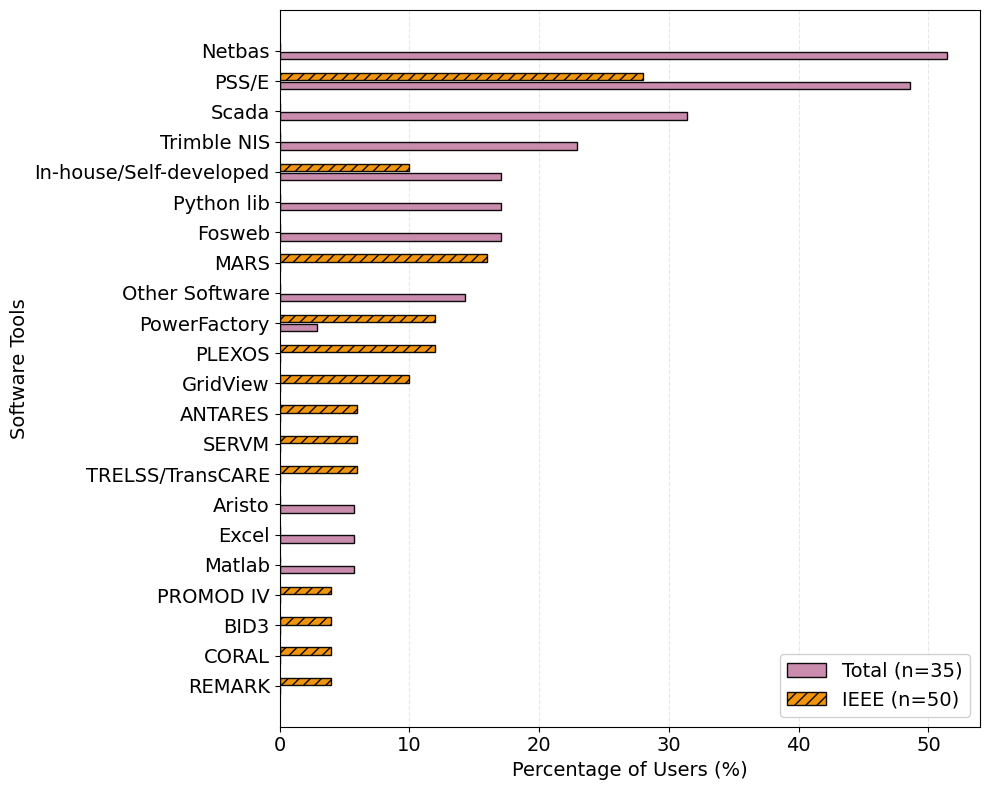

After min_count filter (2): 22 software


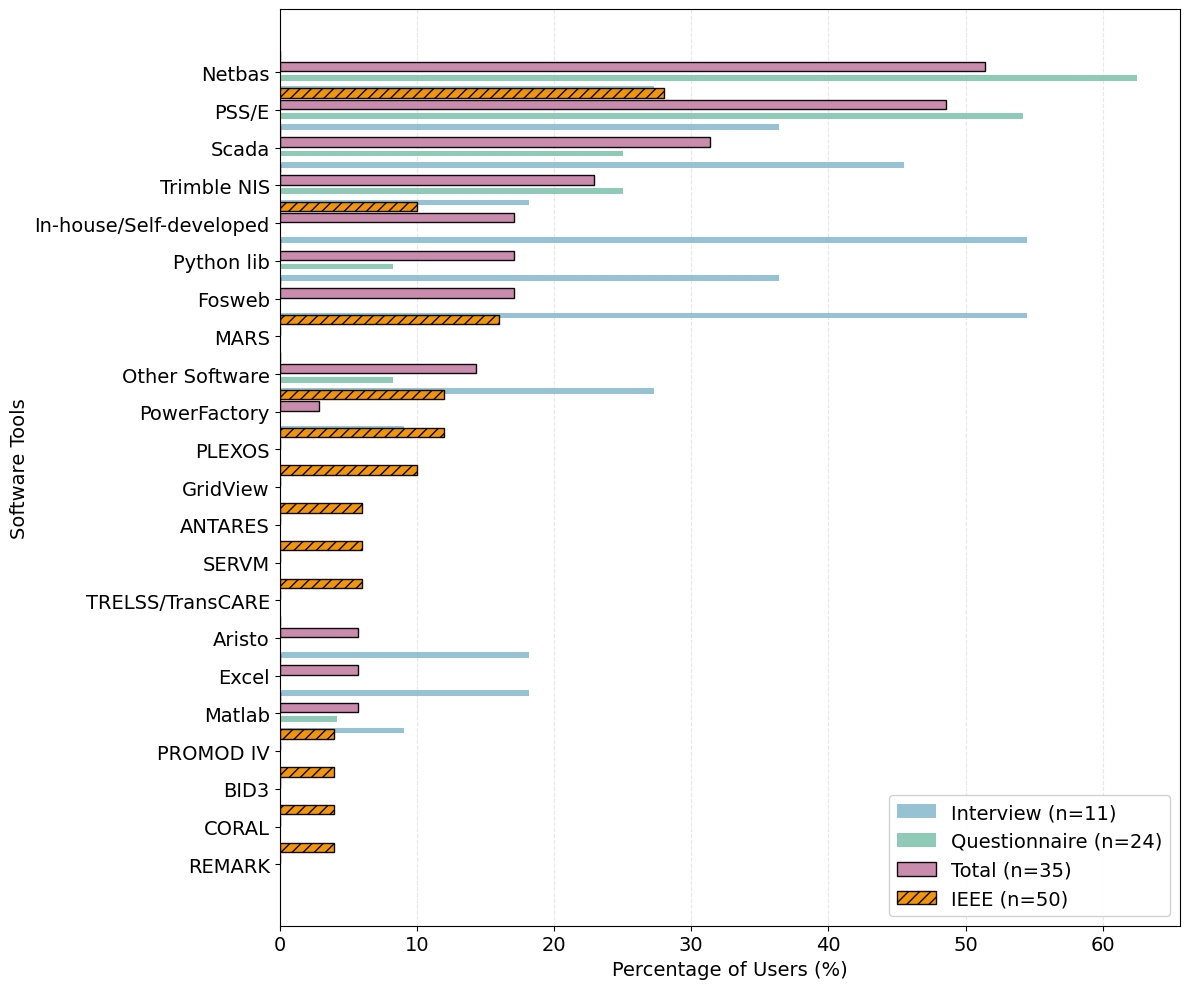

In [10]:
# ========================================

fontsize=14
# Norwegian only (3 bars)
#plot_software_bar_chart(
#    df_software_comparison,
#    datasets=['Interview', 'Questionnaire', 'Total'],
#    save_path='plots/software_norwegian.pdf',
#    #top_k=20,
#    min_count=2,
#    fontsize=fontsize, title=False
#)

# Comparison: Total vs IEEE (2 bars, both emphasized)
plot_software_bar_chart(
    df_software_comparison,
    datasets=['Total', 'IEEE'],
    save_path='plots/software_comparison_ieee.pdf',
    #top_k=20,
    figsize=(10,8),
    min_count=2,
    fontsize=fontsize, title=False)

# Full comparison with all 4 (Interview/Questionnaire faded, Total/IEEE emphasized)
plot_software_bar_chart(
    df_software_comparison,
    datasets=['Interview', 'Questionnaire', 'Total', 'IEEE'],
    save_path='plots/software_comparison_full.pdf',
    #top_k=25,
    min_count=2,
    fontsize=fontsize
)

### Method and features

In [11]:
def count_grouped_software_usage(df, software_mapping, software_groups):
    """Count software usage and organize by groups"""
    
    # First get individual software counts
    software_counts = {}
    software_type_cols = [col for col in df.columns if col.startswith("software_type")]
    
    for col in software_type_cols:
        if col in software_mapping:
            count = df[col].astype(int).sum()
            software_name = software_mapping[col]
            software_counts[software_name] = count
    
    # Create reverse mapping: software -> group
    software_to_group = {}
    for group, software_list in software_groups.items():
        for software in software_list:
            software_to_group[software] = group
    
    # Organize counts by groups
    grouped_counts = {group: {} for group in software_groups.keys()}
    group_totals = {group: 0 for group in software_groups.keys()}
    
    for software, count in software_counts.items():
        if count > 0:  # Only include used software
            group = software_to_group.get(software, 'Other/Specialized')
            grouped_counts[group][software] = count
            group_totals[group] += count
    
    return software_counts, grouped_counts, group_totals


def create_group_pie_chart_with_details(grouped_counts, group_totals, min_count=1):
    """Create pie chart showing group totals with individual software details in legend/table"""
    
    # Filter out groups with zero or low counts
    filtered_groups = {group: software_dict for group, software_dict in grouped_counts.items() 
                      if group_totals[group] >= min_count}
    filtered_totals = {group: total for group, total in group_totals.items() 
                      if total >= min_count}
    
    if not filtered_groups:
        print("No software usage data to display")
        return
    
    # Prepare data for pie chart
    group_names = list(filtered_totals.keys())
    group_counts = list(filtered_totals.values())
    
    # Colors for groups
    colors = plt.cm.Set3(np.linspace(0, 1, len(group_names)))
    
    # Create pie chart
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Pie chart showing group totals
    wedges, texts, autotexts = ax1.pie(group_counts, labels=group_names, colors=colors,
                                       autopct='%1.1f%%\n(%d)', startangle=90, pctdistance=0.85)
    
    # Improve text readability
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(10)
    
    for text in texts:
        text.set_fontsize(10)
        text.set_fontweight('bold')
    
    # Add center circle for donut effect
    centre_circle = plt.Circle((0,0), 0.65, fc='white')
    ax1.add_artist(centre_circle)
    
    ax1.set_title('Software Usage by Functional Group', fontsize=14, fontweight='bold')
    
    # Create detailed breakdown table
    ax2.axis('off')  # Hide axes for table
    
    # Prepare table data
    table_data = []
    row_colors = []
    
    for i, (group, software_dict) in enumerate(filtered_groups.items()):
        # Group header row
        table_data.append([f"{group} (Total: {filtered_totals[group]})", "Count", "%"])
        row_colors.append(colors[i])
        
        # Individual software rows
        total_group_count = filtered_totals[group]
        for software, count in sorted(software_dict.items(), key=lambda x: x[1], reverse=True):
            if count > 0:
                percentage = (count / total_group_count) * 100
                table_data.append([f"  • {software}", str(count), f"{percentage:.1f}%"])
                row_colors.append('lightgray')
        
        # Add separator row
        table_data.append(["", "", ""])
        row_colors.append('white')
    
    # Remove last separator
    if table_data:
        table_data.pop()
        row_colors.pop()
    
    # Create table
    table = ax2.table(cellText=table_data,
                     colLabels=['Software', 'Users', '% of Group'],
                     cellLoc='left',
                     loc='center',
                     colWidths=[0.6, 0.2, 0.2])
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)
    
    # Color code the table rows
    for i, color in enumerate(row_colors):
        for j in range(3):
            if i < len(table_data):
                cell = table[(i+1, j)]  # +1 because row 0 is header
                if table_data[i][0].startswith('  •'):  # Individual software
                    cell.set_facecolor('white')
                elif not table_data[i][0].strip():  # Separator
                    cell.set_facecolor('white')
                else:  # Group header
                    cell.set_facecolor(color)
                    cell.set_text_props(weight='bold')
    
    ax2.set_title('Detailed Breakdown', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return filtered_groups

def create_grouped_software_bar_chart(grouped_counts, group_totals):
    """Create grouped horizontal bar chart"""
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    y_pos = 0
    colors = cm.Set3(np.linspace(0, 1, len(SOFTWARE_GROUPS)))
    group_colors = {group: colors[i] for i, group in enumerate(SOFTWARE_GROUPS.keys())}
    
    yticks = []
    yticklabels = []
    
    for group, software_dict in grouped_counts.items():
        if group_totals[group] > 0:
            # Sort software within group by count
            sorted_software = sorted(software_dict.items(), key=lambda x: x[1], reverse=True)
            
            # Group header
            ax.text(-0.5, y_pos, f'{group} ({group_totals[group]} total)', 
                   fontweight='bold', fontsize=11, ha='right')
            yticks.append(y_pos)
            yticklabels.append('')
            y_pos += 1
            
            # Individual software in group
            for software, count in sorted_software:
                bars = ax.barh(y_pos, count, color=group_colors[group], alpha=0.7)
                ax.text(count + 0.2, y_pos, f'{software} ({count})', 
                       va='center', fontsize=9)
                y_pos += 1
            
            y_pos += 0.5  # Space between groups
    
    ax.set_xlabel('Number of Respondents')
    ax.set_title('Software Tool Usage by Functional Group')
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    # Get the counts



In [12]:
def count_software_usage(df):
    """Count software usage and map to readable names"""
    software_counts = {}
    
    # Get all software_type columns that exist in the dataframe
    software_type_cols = [col for col in df.columns if col.startswith("Software")]
    software_names = [col.replace("Software-", "").strip() for col in sorted_scores.index]
    for i,col in enumerate(software_type_cols):
        count = df[col].astype(int).sum().item()
        software_counts[software_names[i]] = count    
    return software_counts


### Method comparison

In [13]:
PARENT_MAP = { # for mapping which variables are dependent on other variables and thus deciding on respondent elegibility
    # analyze type 1
    "analyze_type1_subtype.1": "analyze_type.1",
    "analyze_type1_subtype.2": "analyze_type.1",
    "analyze_type1_subtype.3": "analyze_type.1",
    "analyze_type1_subtype.4": "analyze_type.1",
    "analyze_type1_subtype.5": "analyze_type.1",
    "analyze_type1_subtype.6": "analyze_type.1",
    "analyze_type1_subtype.7": "analyze_type.1",
    "analyze_type1_subtype_other_desc": "analyze_type.1",
    "analyze_type1_uncertainty.1": "analyze_type.1",
    "analyze_type1_uncertainty.2": "analyze_type.1",
    "analyze_type1_uncertainty.3": "analyze_type.1",
    "analyze_type1_uncertainty.4": "analyze_type.1",
    "analyze_type1_uncertainty.5": "analyze_type.1",
    "analyze_type1_uncertainty_comments": "analyze_type.1",

    # analyze type 2
    "analyze_type2_subtype.1": "analyze_type.2",
    "analyze_type2_subtype.2": "analyze_type.2",
    "analyze_type2_subtype.3": "analyze_type.2",
    "analyze_type2_subtype.4": "analyze_type.2",
    "analyze_type2_subtype.5": "analyze_type.2",
    "analyze_type2_subtype.6": "analyze_type.2",
    "analyze_type2_subtype_other_desc": "analyze_type.2",

    # sub‑sub of analyze_type2_subtype.1
    "analyze_type2_subtype1_subsubtype.1": "analyze_type2_subtype.1",
    "analyze_type2_subtype1_subsubtype.2": "analyze_type2_subtype.1",
    "analyze_type2_subtype1_subsubtype.3": "analyze_type2_subtype.1",
    "analyze_type2_subtype1_subsubtype.4": "analyze_type2_subtype.1",
    "analyze_type2_subtype1_subsubtype.5": "analyze_type2_subtype.1",
    "analyze_type2_subtype1_subsubtype.6": "analyze_type2_subtype.1",
    "analyze_type2_subtype1_other_desc": "analyze_type2_subtype.1",

    # analyze type 3
    "analyze_type3_subtype.1": "analyze_type.3",
    "analyze_type3_subtype.2": "analyze_type.3",
    "analyze_type3_subtype.3": "analyze_type.3",
    "analyze_type3_subtype.4": "analyze_type.3",
    "analyze_type3_subtype.5": "analyze_type.3",
    "analyze_type3_subtype.6": "analyze_type.3",
    "analyze_type3_subtype_other_desc": "analyze_type.3",
    "analyze_type3_uncertainty.1": "analyze_type.3",
    "analyze_type3_uncertainty.2": "analyze_type.3",
    "analyze_type3_uncertainty.3": "analyze_type.3",
    "analyze_type3_uncertainty.4": "analyze_type.3",
    "analyze_type3_uncertainty.5": "analyze_type.3",
    "analyze_type3_uncertainty.6": "analyze_type.3",
    "analyze_type3_uncertainty_comments": "analyze_type.3",

    # analyze type 4
    "analyze_type4_subtype.1": "analyze_type.4",
    "analyze_type4_subtype.2": "analyze_type.4",
    "analyze_type4_subtype.3": "analyze_type.4",

    # simulation types
    "simulation_type7_desc": "simulation_type.7",

    "simulation_type1_subtype.1": "simulation_type.1",
    "simulation_type1_subtype.2": "simulation_type.1",
    "simulation_type1_subtype.3": "simulation_type.1",
    "simulation_type1_subtype.4": "simulation_type.1",

    "simulation_type1_subtype3_subsubtype.1": "simulation_type1_subtype.3",
    "simulation_type1_subtype3_subsubtype.2": "simulation_type1_subtype.3",
    "simulation_type1_subtype3_subsubtype.3": "simulation_type1_subtype.3",
    "simulation_type1_subtype3_subsubtype.4": "simulation_type1_subtype.3",
    "simulation_type1_subtype3_subsubtype.5": "simulation_type1_subtype.3",
    "simulation_type1_subtype3_subsubtype.6": "simulation_type1_subtype.3",
    "simulation_type1_subtype3_subsubtype_other": "simulation_type1_subtype.3",

    "simulation_type2_subtype.1": "simulation_type.2",
    "simulation_type2_subtype.2": "simulation_type.2",
    "simulation_type2_subtype.3": "simulation_type.2",
    "simulation_type2_subtype.4": "simulation_type.2",
    "simulation_type2_subtype.5": "simulation_type.2",
    "simulation_type2_subtype.6": "simulation_type.2",
    "simulation_type2_subtype.7": "simulation_type.2",
    "simulation_type2_subtype6_desc": "simulation_type2_subtype.6",

    # simulation uncertainty
    "simulation_uncertainty_type7_desc": "simulation_uncertainty.7",
    # (optionally) gate comments on "any uncertainty selected"
    # "simulation_uncertainty_comments":  <no single parent; handle separately>
}

METHOD_MAP = {
    # Avbruddsanalyser (analyze_type.1)
    'analyze_type.1': {'methods': ['contingency analysis'], 'score': 2},
    'analyze_type1_subtype.1': {'methods': ['generation outage model'], 'score': 3},  # Utfall av produksjon
    'analyze_type1_subtype.2': {'methods': ['grid failure modeling'], 'score': 3},  # Utfall av nettkomponent
    'analyze_type1_subtype.3': {'methods': ['weather dependent outage'], 'score': 3},  # Væravhengige avbrudd
    'analyze_type1_subtype.4': {'methods': ['cascading failure'], 'score': 3},  # Kaskadefeil
    
    # Analyser for driftsplanlegging og koordinering (type2)
    #'analyze_type2_subtype.1': {'methods': ['load shedding analysis'], 'score': 1},
    'analyze_type2_subtype1_subtype.1': {'methods': ['load curtailment'], 'score': 2},  # Lastbegrensning
    'analyze_type2_subtype1_subtype.2': {'methods': ['optimal dispatch'], 'score': 1},  # Produksjonstilpasning
    'analyze_type2_subtype1_subtype.3': {'methods': ['dynamic reactive power compensation', 'voltage reactive power', 
                                                     'optimal reactive power', 'reactive power sharing', 
                                                     'static var compensator'], 'score': 1},  # Reaktiv effektregulering
    'analyze_type2_subtype1_subtype.4': {'methods': ['voltage control strategy'], 'score': 1},  # Transformatorjustering
    'analyze_type2_subtype.2': {'methods': ['automatic generation control agc'], 'score': 1},  # Last- eller produksjonsisolering
    'analyze_type2_subtype.3': {'methods': ['congestion management'], 'score': 3},  # Flaskehalshåndtering
    
    # Modellering (type3)
    'analyze_type3_subtype.1': {'methods': ['load forecasting'], 'score': 2},  # Lastmodellering
    'analyze_type3_subtype.2': {'methods': ['power generation modeling'], 'score': 2},  # Produksjonsmodellering
    'analyze_type3_subtype.3': {'methods': ['demand response','demand side management dsm', 'power system flexibility'], 'score': 3},  # Fleksibilitet/Demand-Respons
    
    # Usikkerhet i avbruddsanalyser (type1_uncertainty)
    'analyze_type1_uncertainty.1': {'methods': ['probabilistic analysis'], 'score': 3},  # Probabilistisk
    'analyze_type1_uncertainty.2': {'methods': ['scenario analysis'], 'score': 3},  # Scenariobasert
    'analyze_type1_uncertainty.3': {'methods': ['time series analysis'], 'score':1},  # Fast verdi basert på historiske verdier
    
    # Usikkerhet i modellering (type3_uncertainty)
    'analyze_type3_uncertainty.1': {'methods': ['probabilistic analysis'], 'score': 3},  # Probabilistisk
    'analyze_type3_uncertainty.2': {'methods': ['scenario analysis'], 'score': 3},  # Scenariobasert
    'analyze_type3_uncertainty.3': {'methods': ['time series analysis'], 'score': 3},  # Tidsserie basert på profil
    'analyze_type3_uncertainty.4': {'methods': ['time series analysis'], 'score': 1},  # Fast verdi
    
    # Økonomiske analyser (type4)
    'analyze_type4_subtype.1': {'methods': ['cost of energy not served'], 'score': 2},  # Avbruddskostnader (KILE)
    'analyze_type4_subtype.2': {'methods': ['energy market forecasting'], 'score': 2},  # Markedsinnflytelse
    
    # Simuleringsusikkerhet (simulation_uncertainty)
    'simulation_uncertainty.1': {'methods': ['probabilistic analysis'], 'score': 3},  # Probabilistisk
    'simulation_uncertainty.2': {'methods': ['scenario analysis'], 'score': 3},  # Scenariobasert
    'simulation_uncertainty.3': {'methods': ['time series analysis'], 'score': 3},  # Aggregert tidsserie
    #'simulation_uncertainty.4': {'methods': ['fixed value'], 'score': 3},  # Faste verdier
    #'simulation_uncertainty.5': {'methods': ['fixed value'], 'score': 2},  # Faste verdier
    
    # Simuleringstyper (simulation_type)
    'simulation_type.1': {'methods': ['power flow analysis'], 'score': 3},  # Lastflytanalyser
    'simulation_type.2': {'methods': ['state estimation'], 'score': 2},  # Tilstandsanalyser
    'simulation_type.3': {'methods': ['stochastic simulation','stochastic model'], 'score': 3},  # Stokastiske simuleringer
    'simulation_type.5': {'methods': ['energy market forecasting'], 'score': 3},  # Markedssimuleringer
    'simulation_type.6': {'methods': ['time series analysis'], 'score': 3},  # Tidsseriesimuleringer
    'simulation_type1_subtype.1': {'methods': ['power flow analysis'], 'score': 3},  # Ordinær lastflyt
    'simulation_type1_subtype.2': {'methods': ['optimal power flow'], 'score': 3},  # Optimal lastflyt
    'simulation_type1_subtype.3': {'methods': ['security-constrained optimal power flow'], 'score': 2},  # Sikkerhetsbegrenset OPF
    'simulation_type1_subtype3_subsubtype.3': {'methods': ['voltage stability'], 'score': 1},  # Spenningsstabilitet
    'simulation_type2_subtype.1': {'methods': ['contingency analysis','grid failure modeling'], 'score': 3},  # Utfallsanalyser
    'simulation_type2_subtype.2': {'methods': ['monte carlo','markov chain monte carlo','markov chain'], 'score': 3},  # Markov Chain/Monte Carlo
    'simulation_type2_subtype.3': {'methods': ['fault tree analysis', 'minimal cut set'], 'score': 3},  # Feiltre-analyse
    'simulation_type2_subtype.4': {'methods': ['failure mode effects analysis'], 'score': 2},  # FMEA/FMECA
    'simulation_type2_subtype.5': {'methods': ['state estimation','state-space modeling'], 'score': 3},  # Tilstandsromanalyse
    
    # Indicators (1-5 scale) - these use indicator conversion: 0-1=0, 2-3=1, 4=2, 5=3
    'indicators_type.1': {'methods': ['capacity outage probability table'], 'indicator': True},  # COPT
    'indicators_type.2': {'methods': ['customer average interruption duration', 
                                     'customer average interruption frequency'], 'indicator': True},  # CAIDI/CAIFI
    'indicators_type.3': {'methods': ['energy not served', 'average energy not served'], 'indicator': True},  # ENS/AENS
    'indicators_type.4': {'methods': ['expected energy not served'], 'indicator': True},  # EENS
    'indicators_type.5': {'methods': ['forced outage rate'], 'indicator': True},  # FOR
    'indicators_type.6': {'methods': ['energy not served'], 'indicator': True},  # ILE
    'indicators_type.7': {'methods': ['cost of energy not served'], 'indicator': True},  # KILE
    'indicators_type.8': {'methods': ['loss of load expectancy'], 'indicator': True},  # LOLE
    'indicators_type.9': {'methods': ['loss of load frequency', 'loss of load duration'], 'indicator': True},  # LOLF/LOLD
    'indicators_type.10': {'methods': ['loss of load probability'], 'indicator': True},  # LOLP
    'indicators_type.11': {'methods': ['failure statistical modeling'], 'indicator': True},  # MTTF/MTBF
    'indicators_type.12': {'methods': ['failure statistical modeling'], 'indicator': True},  # MTTR
    'indicators_type.13': {'methods': ['system average interruption duration index', 
                                      'system average interruption frequency index'], 'indicator': True},  # SAIDI/SAIFI
}

### IEEE comparison of features first

In [14]:
# ========================================
# SIMPLIFIED FEATURE MAP (no scores, binary only)
# ========================================

# ========================================
# FEATURE MAP (same format as METHOD_MAP)
# ========================================

FEATURE_IEEE_MAP = {
    # ===== OUTAGE ANALYSIS =====
    # These map to 'failure modeling' in METHOD_MAP which has score: 1
    'analyze_type1_subtype.1': {'features': ['Gen outages'], 'score': 3},  # Generation outages → failure modeling
    'analyze_type1_subtype.2': {'features': ['Tx outages'], 'score': 3},  # Transmission outages → failure modeling
    'analyze_type1_subtype.3': {'features': ['Wx-dependent outages'], 'score': 3},  # Weather-dependent → failure modeling
    'analyze_type1_subtype.4': {'features': ['Cascading collapse'], 'score': 3},  # Cascading → failure modeling
    'analyze_type1_subtype.5': {'features': ['Other depend. outages'], 'score': 3},  # UNCLEAR - not in METHOD_MAP, assuming similar to other outages
    
    # ===== OPERATIONAL PLANNING =====
    # Map to corresponding analyze_type2 entries in METHOD_MAP
    'analyze_type2_subtype.1': {'features': ['Emergency operating'], 'score': 3},  # Maps to load shedding analysis
    'analyze_type2_subtype1_subtype_1': {'features': ['Load curtailment'], 'score': 3},  # Load shedding
    'analyze_type2_subtype1_subtype_2': {'features': ['Generator redispatch'], 'score': 3},  # Optimal dispatch
    'analyze_type2_subtype1_subtype_3': {'features': ['Switching shunt devices'], 'score': 3},  # Reactive power control
    'analyze_type2_subtype1_subtype_4': {'features': ['Transformer adjustments'], 'score': 3},  # Voltage control
    'analyze_type2_subtype.2': {'features': ['Load or gen isolation'], 'score': 3},  # AGC
    'analyze_type2_subtype.3': {'features': ['Tx congestion mgmt'], 'score': 3},  # Bottleneck identification
    'analyze_type2_subtype.4': {'features': ['Flowgate violations'], 'score': 3},  # ⚠️ UNCLEAR - not in METHOD_MAP, assuming similar complexity to congestion mgmt
    'analyze_type2_subtype.5': {'features': ['Other'], 'score': 1},  # ⚠️ UNCLEAR - generic category, using low score
    
    # ===== MODELING =====
    # Map to analyze_type3 in METHOD_MAP
    'analyze_type3_subtype.1': {'features': ['Load'], 'score': 2},  # Load forecasting
    #'analyze_type3_subtype.2': {'features': ['VER generation'], 'score': 2},  # Power generation modeling - no feasible alternative found VER is something different than production forecasting in general
    'analyze_type3_subtype.3': {'features': ['Demand response'], 'score': 3},  # Demand response/flexibility
    
    # ===== UNCERTAINTY MODELING =====
    # Map to analyze_type1_uncertainty and analyze_type3_uncertainty in METHOD_MAP
    'analyze_type1_uncertainty.1': {'features': ['Stochastic'], 'score': 3},  # Probabilistic analysis
    'analyze_type1_uncertainty.2': {'features': ['Varied scenarios'], 'score': 3},  # Scenario-based analysis
    'analyze_type1_uncertainty.3': {'features': ['Fixed values'], 'score': 2},  # Time series (fixed/historical)
    'analyze_type1_uncertainty.4': {'features': ['Fixed values'], 'score': 2},  # ⚠️ UNCLEAR - duplicate of .3, not in METHOD_MAP
    'analyze_type3_uncertainty.1': {'features': ['Stochastic'], 'score': 3},  # Probabilistic
    'analyze_type3_uncertainty.2': {'features': ['Varied scenarios'], 'score': 3},  # Scenario-based
    'analyze_type3_uncertainty.3': {'features': ['Fixed values'], 'score': 3},  # Time series (profile-based)
    'analyze_type3_uncertainty.4': {'features': ['Fixed values'], 'score': 2},  # Fixed values
        # Simuleringsusikkerhet (simulation_uncertainty)
    'simulation_uncertainty.1': {'features': ['Stochastic'], 'score': 3},  # Probabilistisk
    'simulation_uncertainty.2': {'features': ['Varied scenarios'], 'score': 3},  # Scenariobasert
    'simulation_uncertainty.3': {'features': ['Varied scenarios'], 'score': 3},  # Aggregert tidsserie
    'simulation_uncertainty.4': {'features': ['Fixed values'], 'score': 3},  # Faste verdier basert på analyse
    'simulation_uncertainty.5': {'features': ['Fixed values'], 'score': 2},  # Faste verdier basert på ekspertuttalelse
    # ===== SIMULATION TYPES =====
    # Map to simulation_type entries in METHOD_MAP
    'simulation_type.1': {'features': ['Power flow analysis'], 'score': 3},  # Power flow analysis
    'simulation_type1_subtype.2': {'features': ['DC OPF'], 'score': 3},  # Optimal power flow
    'simulation_type1_subtype.3': {'features': ['Security constraints'], 'score': 2},  # Security-constrained OPF
    'simulation_type2_subtype.1': {'features': ['Contingency analysis'], 'score': 3},  # Contingency analysis
    'simulation_type2_subtype.2': {'features': ['Monte Carlo simulation'], 'score': 3},  # Monte Carlo
    'simulation_type2_subtype.3': {'features': ['Fault tree/Minimal cut set'], 'score': 3},  # Fault tree analysis
    'simulation_type2_subtype.4': {'features': ['Failure Mode and Effect Analysis'], 'score': 2},  # FMEA/FMECA
    'simulation_type2_subtype.5': {'features': ['Enumeration'], 'score': 3},  # ⚠️ UNCLEAR - maps to state-space modeling, assuming high complexity
    'simulation_type2_subtype.6': {'features': ['Other'], 'score': 2},  # ⚠️ UNCLEAR - generic category, using medium score
    'simulation_type.3': {'features': ['Stochastic simulation'], 'score': 3},  # Stochastic simulation
    'simulation_type.5': {'features': ['Market impacts'], 'score': 3},  # Energy market forecasting
    
    # ===== RELIABILITY INDICATORS =====
    # All indicators use indicator conversion (1-5 scale), not scored
    'indicators_type.1': {'features': ['COPT'], 'indicator': True},
    'indicators_type.2': {'features': ['CAIDI/CAIFI'], 'indicator': True},
    'indicators_type.3': {'features': ['ENS/AENS'], 'indicator': True},
    'indicators_type.4': {'features': ['EENS'], 'indicator': True},
    'indicators_type.5': {'features': ['FOR'], 'indicator': True},
    'indicators_type.6': {'features': ['ILE'], 'indicator': True},
    'indicators_type.7': {'features': ['KILE'], 'indicator': True},
    'indicators_type.8': {'features': ['LOLE'], 'indicator': True},
    'indicators_type.9': {'features': ['LOLF/LOLD'], 'indicator': True},
    'indicators_type.10': {'features': ['LOLP'], 'indicator': True},
    'indicators_type.11': {'features': ['MTTF/MTBF'], 'indicator': True},
    'indicators_type.12': {'features': ['MTTR'], 'indicator': True},
    'indicators_type.13': {'features': ['SAIDI/SAIFI'], 'indicator': True},
}
# IEEE method names to Norwegian standard names
IEEE_FEATURE_MAPPING = {
    # IEEE name → Standard name (from FEATURE_IEEE_MAP)
    'Loss-of-Load Probability (LOLP)': 'LOLP',
    'Expected Unserved Energy (EUE)': 'EENS',  # EUE = EENS
    'Loss-of-Load Hours (LOLH)': 'LOLF/LOLD',
    'Loss-of-Load Expectation (LOLE)': 'LOLE',
    'Loss-of-Load Events (LOLEV)': 'LOLF/LOLD',
    'System Wide metrics': 'System-Wide (other)',
    'Load Point Metrics':'Load-Point Metrics',
    
    
    # Keep IEEE names as-is for features not in indicators
    'Gen outages': 'Gen outages',
    'Tx outages': 'Tx outages',
    'Monte Carlo simulation': 'Monte Carlo simulation',
    #'Hourly VER modeling': 'VER generation',  # Map to your VER generation
    'Wx-dependent outages': 'Wx-dependent outages',
    'Wx?dependent outages': 'Wx-dependent outages',
    'Short-duration storage': 'Short-duration storage',
    'Short?duration storage': 'Short-duration storage',
    'Long-duration storage': 'Long-duration storage',
    'Long?duration storage': 'Long-duration storage',
    'Emergency operating': 'Emergency operating',
    'Security constraints': 'Security constraints',
    'Other depend. outages': 'Other depend. outages',
    'Enumeration': 'Enumeration',
    'Tx congestion mgmt': 'Tx congestion mgmt',
    'Load or gen isolation': 'Load or gen isolation',
    'AC OPF': 'AC OPF',
    'Substation-orig outages': 'Substation-orig outages',
    'Substation?orig outages': 'Substation-orig outages',
    'Cascading collapse': 'Cascading collapse',
    'Market impacts': 'Market impacts',
    'DC OPF': 'DC OPF'
}


In [15]:
# ========================================
# SIMPLE BINARY FEATURE COMPARISON
# ========================================

def count_binary_usage(df, feature_map,target='features'):
    """
    Count binary feature usage from questionnaire data
    
    Parameters:
    -----------
    df : DataFrame
        Raw questionnaire data with binary columns
    feature_map : dict
        Mapping of column codes to target names (default target  = 'features')
        Format: {'column_code': {'features': ['Feature Name'], ...}, ...}
        
    Returns:
    --------
    DataFrame with columns: ['target', 'Count_Using', 'Total_Respondents', 'pct_binary']
    """
    total_respondents = len(df)
    feature_counts = {}
    
    # Count usage for each feature
    for var_code, meta in feature_map.items():
        # Skip if column doesn't exist
        if var_code not in df.columns:
            continue
        
        # Get the feature name(s)
        features = meta.get(target, [])
        if not isinstance(features, list):
            features = [features]
        
        # Check if it's an indicator (1-5 scale) or binary
        is_indicator = meta.get('indicator', False)
        
        # Count respondents who use this feature
        if is_indicator:
            # For indicators: count any response >= 2
            count_using = (df[var_code] >= 2).sum()
        else:
            # For binary: count True or 1
            count_using = ((df[var_code] == 1) | (df[var_code] == True)).sum()
        # Add count to each feature name
        for feature in features:
            if feature not in feature_counts:
                feature_counts[feature] = 0
            # Use max if multiple columns map to same feature
            feature_counts[feature] = max(feature_counts[feature], count_using)
    
    # Build results DataFrame
    results = []
    for feature, count in feature_counts.items():
        frac = (count / total_respondents) if total_respondents > 0 else 0
        pct=frac*100
        pct_not=100-pct
        results.append({
            target: feature,
            'Count_Using': int(count),
            'Count_notusing':total_respondents-count,
            'Total_Respondents': total_respondents,
            'pct_binary': round(pct, 2),
            'pct_notusing':round(pct_not, 2),
            'frac_binary':frac
        })
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('pct_binary', ascending=False).reset_index(drop=True)
    
    return results_df

In [16]:

def indicator_conversion(val):
    """
    Convert indicator values (0-5 scale) to normalized scores
    0-1 = 0, 2-3 = 1, 4 = 2, 5 = 3
    """
    try:
        val = int(val)
    except (ValueError, TypeError):
        return 0
    
    if val in [0, 1]:
        return 0
    elif val in [2, 3]:
        return 1
    elif val == 4:
        return 2
    elif val == 5:
        return 3
    else:
        return 0


#### IEEE Feature comparison

In [17]:
# ========================================
# PROCESS AND MERGE
# ========================================

# 1. Count binary usage from questionnaire
df_q_features = count_binary_usage(df_q, FEATURE_IEEE_MAP,target='features')
# 2. Prepare IEEE data
df_ieee_clean = df_ieee_feature.copy()
df_ieee_clean = df_ieee_clean.rename(columns={
    'feature_name': 'features',
    'feature_use_count': 'Count_Using_IEEE',
    'feature_use_percentage': 'pct_binary_ieee'
})
df_ieee_clean['pct_binary_ieee']=df_ieee_clean['pct_binary_ieee']*100 #multiply by 100 to get percentage
print(df_ieee_clean['features'])

# 3. Map IEEE feature names to standard names using IEEE_FEATURE_MAPPING
df_ieee_clean['features'] = df_ieee_clean['features'].map(
    lambda x: IEEE_FEATURE_MAPPING.get(x.strip().rstrip(';'), x)
)

# 4. Merge questionnaire and IEEE data
df_feature_comparison = pd.merge(
    df_q_features[['features', 'pct_binary', 'Count_Using', 'Total_Respondents']],
    df_ieee_clean[['features', 'pct_binary_ieee', 'Count_Using_IEEE']],
    on='features',
    how='outer',
    suffixes=('_q', '_ieee')
)


# Fill NaN with 0
df_feature_comparison['pct_binary'] = df_feature_comparison['pct_binary'].fillna(0)
df_feature_comparison['pct_binary_ieee'] = df_feature_comparison['pct_binary_ieee'].fillna(0)

# Calculate average percentage and delta
df_feature_comparison['pct_average'] = df_feature_comparison[['pct_binary', 'pct_binary_ieee']].mean(axis=1)
df_feature_comparison['pct_diff_abs'] = df_feature_comparison['pct_binary'] - df_feature_comparison['pct_binary_ieee']

# Sort by average
df_feature_comparison = df_feature_comparison.sort_values('pct_average', ascending=False).reset_index(drop=True)

# 5. Save results
df_feature_comparison.to_csv('data/feature_comparison_q_ieee.csv', index=False)

print(f"Feature comparison complete: {len(df_feature_comparison)} features")
print(f"\nQuestionnaire: {len(df_q_features)} features")
print(f"IEEE: {len(df_ieee_clean)} features")
print(f"\nTop 10 features by average usage:")
print(df_feature_comparison[['features', 'pct_binary', 'pct_binary_ieee', 'pct_average']].head(10))



0                 Gen outages
1                  Tx outages
2      Monte Carlo simulation
3         Hourly VER modeling
4        Wx-dependent outages
5      Short-duration storage
6         Emergency operating
7        Security constraints
8       Long-duration storage
9       Other depend. outages
10                Enumeration
11         Tx congestion mgmt
12      Load or gen isolation
13                     AC OPF
14    Substation-orig outages
15         Cascading collapse
16             Market impacts
17                     DC OPF
18        Flowgate violations
19                      Other
Name: features, dtype: object
Feature comparison complete: 43 features

Questionnaire: 38 features
IEEE: 20 features

Top 10 features by average usage:
                 features  pct_binary  pct_binary_ieee  pct_average
0              Tx outages       62.50             44.0       53.250
1                     ILE      100.00              0.0       50.000
2                    KILE      100.00       

In [24]:
# ========================================
# PLOT COMPARISON
# ========================================

def plot_feature_comparison(df, top_k=20, save_path=None,dual_only=False, fontsize=12,figsize=(12, 10), title=True):
    """
    Plot feature comparison between Questionnaire and IEEE data
    """
    # Filter to features with non-zero usage
    df_filtered = df[df['pct_average'] > 0].copy()
    #Filter out rows that are missing values in one of the two datasets
    if dual_only:
        df_filtered = df_filtered[(df_filtered['Count_Using_IEEE'].notna()) & (df_filtered['Count_Using'].notna())]
        print(f"After removing rows wiht NaN in either NO or IEEE, {len(df_filtered)} features remain")

    if top_k is not None and len(df_filtered) > top_k:
        df_filtered = df_filtered.nlargest(top_k, 'pct_average')
        print(f'Plotting top {top_k} of {len(df[df["pct_average"] > 0])} features with non-zero usage')
    
    df_sorted = df_filtered.sort_values('pct_average', ascending=True)
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    y = np.arange(len(df_sorted))
    height = 0.35
    
    # Plot bars
    ax.barh(y - height/2, df_sorted['pct_binary'], height, 
            label='Norwegian DSO/TSO Survey', alpha=0.7, color='#C786A9',edgecolor='#000000')
    ax.barh(y + height/2, df_sorted['pct_binary_ieee'], height, 
            label='IEEE Survey', alpha=0.7, color='#F18F01',edgecolor='#000000',hatch='///')
    
    ax.set_yticks(y)
    ax.set_yticklabels(df_sorted['features'].values, fontsize=fontsize)
    ax.set_xlabel('% of Respondents', fontsize=fontsize)
    #ax.set_ylabel('Feature', fontsize=fontsize)
    
    if title:
        title = 'Feature Usage Comparison: Norwegian Questionnaire vs IEEE Survey'
        if top_k:
            title += f'\n(Top {top_k} features)'
        ax.set_title(title, fontsize=fontsize+2, fontweight='bold')
    ax.legend(fontsize=fontsize-1, loc='lower right')
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, 70)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
    
    plt.show()



After removing rows wiht NaN in either NO or IEEE, 15 features remain


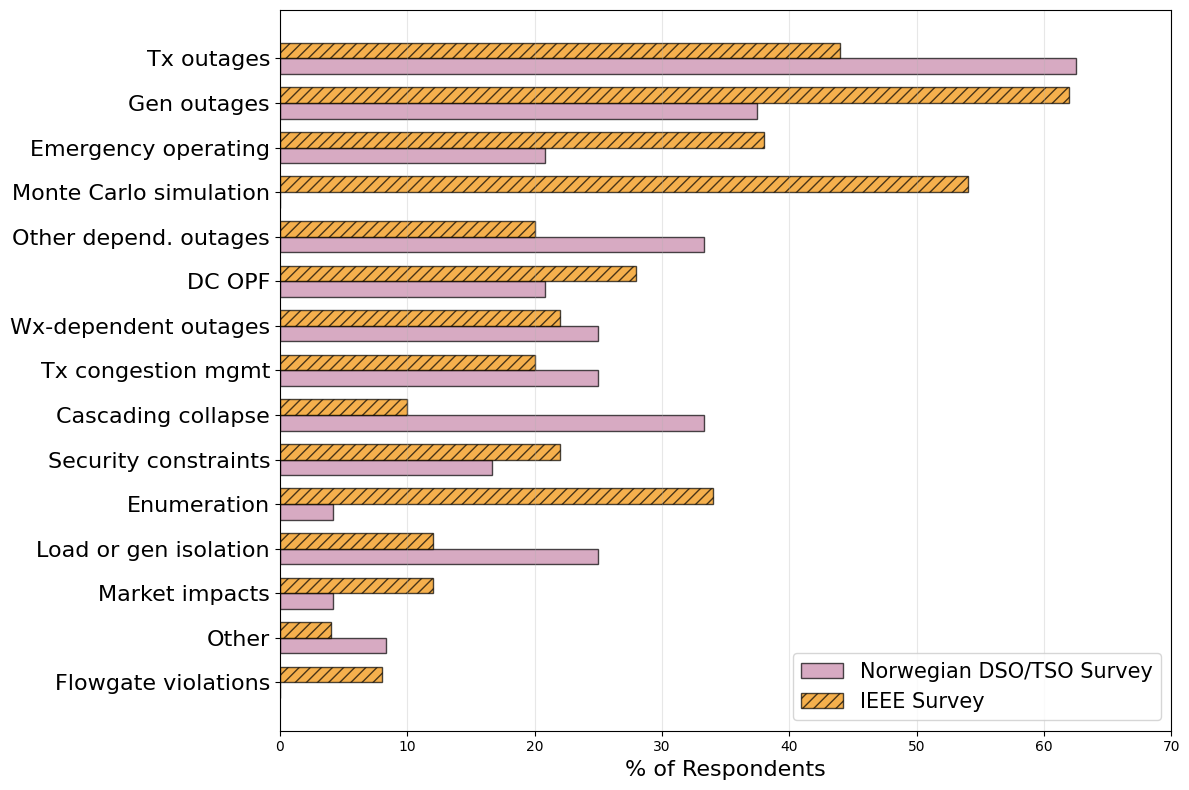

In [ ]:
# Plot the comparison
plot_feature_comparison(
    df_feature_comparison,
    top_k=30,
    dual_only=True,
    fontsize=16,
    figsize=(12,8),
    title=False,
    save_path='plots/feature_comparison_q_ieee.pdf'
)

#### indicator comparison

In [26]:
INDICATOR_CATEGORIES = {
    # IEEE explicitly listed these (typically used for generation adequacy)
    'LOLP': 'LOLP',
    'LOLE': 'LOLE',
    'LOLF/LOLD': 'LOLF/LOLD',
    'EENS': 'EENS',
    
    # IEEE "System-Wide" catch-all = distribution system reliability
    'SAIDI/SAIFI': 'System-Wide (other)',
    'CAIDI/CAIFI': 'System-Wide (other)',
    'FOR': 'System-Wide (other)',
    'COPT': 'System-Wide (other)',
    # IEEE "Load-Point" = component-level
    'MTTR': 'Load-Point Metrics',
    'MTTF/MTBF': 'Load-Point Metrics',
    'ENS/AENS': 'Load-Point Metrics',
    
    # Norwegian-specific
    'KILE': 'Country-Specific (Norway)',
    'ILE': 'Country-Specific (Norway)',
}
  
     # IEEE to category mapping
IEEE_MAPPING = {
    'LOLP': 'LOLP',
    'LOLE': 'LOLE',
    'LOLF/LOLD': 'LOLF/LOLD',  
    'EENS': 'EENS',
    'System-Wide metrics': 'System-Wide (other)',
    'System Wide metrics': 'System-Wide (other)',
    'Load-Point Metrics': 'Load-Point Metrics',
    'Load Point Metrics': 'Load-Point Metrics',
}



In [27]:
# ========================================
# INDICATOR COMPARISON
# ========================================
def get_indicator_names_from_map(feature_map):
    """
    Extract list of indicator names from FEATURE_IEEE_MAP
    """
    indicator_names = []
    for var_code, meta in feature_map.items():
        if meta.get('indicator', False):
            features = meta.get('features', [])
            if not isinstance(features, list):
                features = [features]
            indicator_names.extend(features)
    return indicator_names

def count_binary_indicator_usage(df, feature_map):
    """
    Count binary indicator usage from questionnaire data
    (Same as feature function but specifically for indicators)
    
    Parameters:
    -----------
    df : DataFrame
        Raw questionnaire data
    feature_map : dict
        Mapping with indicator entries only
        
    Returns:
    --------
    DataFrame with columns: ['Indicator', 'Count_Using', 'Total_Respondents', 'pct_binary']
    """
    total_respondents = len(df)
    indicator_counts = {}
    
    # Count usage for each indicator
    for var_code, meta in feature_map.items():
        # Skip if not an indicator
        if not meta.get('indicator', False):
            continue
            
        # Skip if column doesn't exist
        if var_code not in df.columns:
            continue
        
        # Get the indicator name(s)
        indicators = meta.get('features', [])
        if not isinstance(indicators, list):
            indicators = [indicators]
        
        # For indicators: count any response >= 2 (on 1-5 scale)
        count_using = (df[var_code] >= 2).sum()
        
        # Add count to each indicator name
        for indicator in indicators:
            if indicator not in indicator_counts:
                indicator_counts[indicator] = 0
            # Use max if multiple columns map to same indicator
            indicator_counts[indicator] = max(indicator_counts[indicator], count_using)
    
    # Build results DataFrame
    results = []
    for indicator, count in indicator_counts.items():
        pct = (count / total_respondents * 100) if total_respondents > 0 else 0
        results.append({
            'Indicator': indicator,
            'Count_Using': int(count),
            'Total_Respondents': total_respondents,
            'pct_binary': round(pct, 1)
        })
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('pct_binary', ascending=False).reset_index(drop=True)
    
    return results_df

In [28]:
def categorize_norwegian_indicators(df_q_indicators, category_mapping):
    """
    Categorize Norwegian indicators using provided mapping
    """
    results = []
    
    # Define output categories in desired order
    output_categories = [
        'LOLP', 'LOLE', 'LOLF/LOLD', 'EENS',
        'System-Wide (other)', 
        'Load-Point Metrics',
        'Country-Specific (Norway)'
    ]
    
    for category in output_categories:
        # Get Norwegian indicators in this category
        indicators_in_category = [ind for ind, cat in category_mapping.items() if cat == category]
        
        if len(indicators_in_category) > 0:
            # For specific indicators, get exact value
            if category in ['LOLP', 'LOLE', 'LOLF/LOLD', 'EENS']:
                pct = df_q_indicators[
                    df_q_indicators['Indicator'] == category
                ]['pct_binary'].values
                pct = float(pct[0]) if len(pct) > 0 else 0.0
                
            else:
                # For aggregated categories, take MAX
                pct_values = []
                for ind in indicators_in_category:
                    val = df_q_indicators[
                        df_q_indicators['Indicator'] == ind
                    ]['pct_binary'].values
                    if len(val) > 0:
                        pct_values.append(float(val[0]))
                pct = max(pct_values) if pct_values else 0.0
        else:
            pct = 0.0
        
        results.append({
            'Category': category,
            'pct_binary': round(pct, 1),
            'Norwegian_Indicators': ', '.join(indicators_in_category) if indicators_in_category else 'N/A'
        })
    
    return pd.DataFrame(results)


def map_ieee_to_categories(df_ieee_indicators, ieee_mapping):
    """
    Map IEEE indicator data to standardized categories
    """
    results = []
    
    output_categories = [
        'LOLP', 'LOLE', 'LOLF/LOLD', 'EENS',
        'System-Wide (other)', 
        'Load-Point Metrics',
        'Country-Specific (Norway)'
    ]
    
    for category in output_categories:
        if category == 'Country-Specific (Norway)':
            pct = 0.0
        else:
            matching = df_ieee_indicators[
                df_ieee_indicators['Indicator'].map(
                    lambda x: ieee_mapping.get(x) == category
                )
            ]
            pct = float(matching['pct_binary'].max()) if len(matching) > 0 else 0.0
        
        results.append({
            'Category': category,
            'pct_binary': round(pct, 1)
        })
    
    return pd.DataFrame(results)


In [29]:
# ========================================
# PLOT CATEGORIZED COMPARISON
# ========================================

def plot_indicator_category_comparison(df, save_path=None, fontsize=12, title=True):
    """
    Plot indicator comparison by category with proper ordering
    """
    # Sort by category order (keep IEEE-specific at top, then aggregated)
    category_order = [
        'LOLP', 'LOLE', 'LOLF/LOLD', 'EENS',
        'System-Wide (other)', 
        'Load-Point Metrics',
        'Country-Specific (Norway)'
    ]
    
    df['sort_order'] = df['Category'].map({cat: i for i, cat in enumerate(category_order)})
    df_sorted = df.sort_values('sort_order', ascending=True).copy()
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    y = np.arange(len(df_sorted))
    height = 0.35
    
    ax.barh(y - height/2, df_sorted['pct_binary_q'], height, 
            label='Norwegian DSO/TSO Survey', 
            alpha=0.8, 
            color='#C786A9',
            edgecolor='black',
            linewidth=0.8)
    
    ax.barh(y + height/2, df_sorted['pct_binary_ieee'], height, 
            label='IEEE Survey', 
            alpha=0.9, 
            color='#F18F01',
            edgecolor='black',
            linewidth=0.8,
            hatch='///')
    
    ax.set_yticks(y)
    ax.set_yticklabels(df_sorted['Category'].values, fontsize=fontsize)
    ax.set_xlabel('% of Respondents', fontsize=fontsize)
    ax.set_xticklabels(ax.get_xticks(), fontsize=fontsize)
    #ax.set_ylabel('Indicator Category', fontsize=fontsize)
    if title: ax.set_title('Reliability Indicator Usage: Norwegian Questionnaire vs. IEEE Survey', 
                 fontsize=fontsize+1, fontweight='bold')
    
    ax.legend(fontsize=fontsize-1, loc='lower right')
    ax.grid(axis='x', alpha=0.3, zorder=0)
    ax.set_xlim(0, 105)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
    
    plt.show()


In [30]:
# 1. Count binary indicator usage from questionnaire
df_q_indicators = count_binary_indicator_usage(df_q, FEATURE_IEEE_MAP)

# 2. Get indicator names from the map
indicator_names = get_indicator_names_from_map(FEATURE_IEEE_MAP)
print(f"Indicators to filter: {indicator_names}")

# 3. Filter IEEE data to indicators only
df_ieee_indicators= df_ieee[[col for col in df_ieee if col.startswith('indicator')]].dropna() 

# Clean IEEE feature names first
df_ieee_indicators['indicator_name'] = df_ieee_indicators['indicator_name'].str.strip().str.rstrip(';')

# Map IEEE names to standard names
df_ieee_indicators['Indicator'] = df_ieee_indicators['indicator_name'].map(
    lambda x: IEEE_FEATURE_MAPPING.get(x, x)
)
print(df_ieee_indicators['Indicator'])
# Filter to only indicators
df_ieee_indicators = df_ieee_indicators[df_ieee_indicators['Indicator'].isin(indicator_names)]



# Select and rename columns
df_ieee_indicators = df_ieee_indicators.rename(columns={
    'indicator_usage_count': 'Count_Using_IEEE',
    'indicator_usage_percentage_of_responders': 'pct_binary_ieee'
})[['Indicator', 'pct_binary_ieee', 'Count_Using_IEEE']]
df_ieee_indicators['pct_binary_ieee']=df_ieee_indicators['pct_binary_ieee']*100


print(f"\nQuestionnaire indicators: {len(df_q_indicators)}")
print(f"IEEE indicators: {len(df_ieee_indicators)}")

# 4. Merge questionnaire and IEEE indicator data
df_indicator_comparison = pd.merge(
    df_q_indicators[['Indicator', 'pct_binary', 'Count_Using', 'Total_Respondents']],
    df_ieee_indicators[['Indicator', 'pct_binary_ieee', 'Count_Using_IEEE']],
    on='Indicator',
    how='outer'
)

# Fill NaN with 0
df_indicator_comparison['pct_binary'] = df_indicator_comparison['pct_binary'].fillna(0)
df_indicator_comparison['pct_binary_ieee'] = df_indicator_comparison['pct_binary_ieee'].fillna(0)

# Calculate average and difference
df_indicator_comparison['pct_average'] = df_indicator_comparison[['pct_binary', 'pct_binary_ieee']].mean(axis=1)
df_indicator_comparison['pct_diff'] = df_indicator_comparison['pct_binary'] - df_indicator_comparison['pct_binary_ieee']

# Sort by average
df_indicator_comparison = df_indicator_comparison.sort_values('pct_average', ascending=False).reset_index(drop=True)

# 5. Save results
df_indicator_comparison.to_csv('data/indicator_comparison_q_ieee.csv', index=False)

print(f"\nIndicator comparison complete: {len(df_indicator_comparison)} indicators")
print(f"\nAll indicators:")
print(df_indicator_comparison[['Indicator', 'pct_binary', 'pct_binary_ieee', 'pct_average']])



Indicators to filter: ['COPT', 'CAIDI/CAIFI', 'ENS/AENS', 'EENS', 'FOR', 'ILE', 'KILE', 'LOLE', 'LOLF/LOLD', 'LOLP', 'MTTF/MTBF', 'MTTR', 'SAIDI/SAIFI']
0                      LOLP
1                      EENS
2                 LOLF/LOLD
3                      LOLE
4                 LOLF/LOLD
5    Other (please specify)
6       System-Wide (other)
7        Load-Point Metrics
Name: Indicator, dtype: object

Questionnaire indicators: 13
IEEE indicators: 5

Indicator comparison complete: 14 indicators

All indicators:
      Indicator  pct_binary  pct_binary_ieee  pct_average
0           ILE       100.0              0.0        50.00
1          KILE       100.0              0.0        50.00
2          LOLP         8.3             54.0        31.15
3          LOLE        12.5             36.0        24.25
4     LOLF/LOLD         8.3             40.0        24.15
5          EENS         4.2             44.0        24.10
6   SAIDI/SAIFI        45.8              0.0        22.90
7          MTTR 

In [31]:
#================================================================================
# IEEE results
#================================================================================

# Filter IEEE data to indicator columns
df_ieee_indicators = df_ieee[[col for col in df_ieee.columns if col.startswith('indicator')]].dropna()

# Rename columns for consistency
df_ieee_indicators = df_ieee_indicators.rename(columns={
    'indicator_name': 'Indicator',
    'indicator_usage_count': 'Count_Using',
    'indicator_usage_percentage_of_responders': 'pct_binary'
})

# Clean indicator names
df_ieee_indicators['Indicator'] = df_ieee_indicators['Indicator'].str.strip().str.rstrip(';')

# Map IEEE names to standard names using IEEE_FEATURE_MAPPING
df_ieee_indicators['Indicator'] = df_ieee_indicators['Indicator'].map(
    lambda x: IEEE_FEATURE_MAPPING.get(x, x)
)
df_ieee_indicators['pct_binary']=df_ieee_indicators['pct_binary']*100
#print("IEEE Indicators after mapping:")
#print(df_ieee_indicators[['Indicator', 'pct_binary']].head(10))

df_ieee_categorized = map_ieee_to_categories(df_ieee_indicators, IEEE_MAPPING)
#print("\nIEEE Indicators by Category:")
#print(df_ieee_categorized.head(10))

#===============================================================================
# NO questionnaire...
#===============================================================================
df_q_categorized = categorize_norwegian_indicators(df_q_indicators, INDICATOR_CATEGORIES)
#print("\nNorwegian Indicators by Category:")
#print(df_q_categorized)

#===============================================================================
# Merge and compare
#===============================================================================
df_indicator_category_comparison = pd.merge(
    df_q_categorized[['Category', 'pct_binary', 'Norwegian_Indicators']],
    df_ieee_categorized[['Category', 'pct_binary']],
    on='Category',
    how='outer',
    suffixes=('_q', '_ieee')
).fillna(0)

# Calculate difference
df_indicator_category_comparison['pct_diff'] = (
    df_indicator_category_comparison['pct_binary_q'] - 
    df_indicator_category_comparison['pct_binary_ieee']
)


C:\Users\STSI\AppData\Local\Temp\ipykernel_27344\2074578583.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=fontsize)


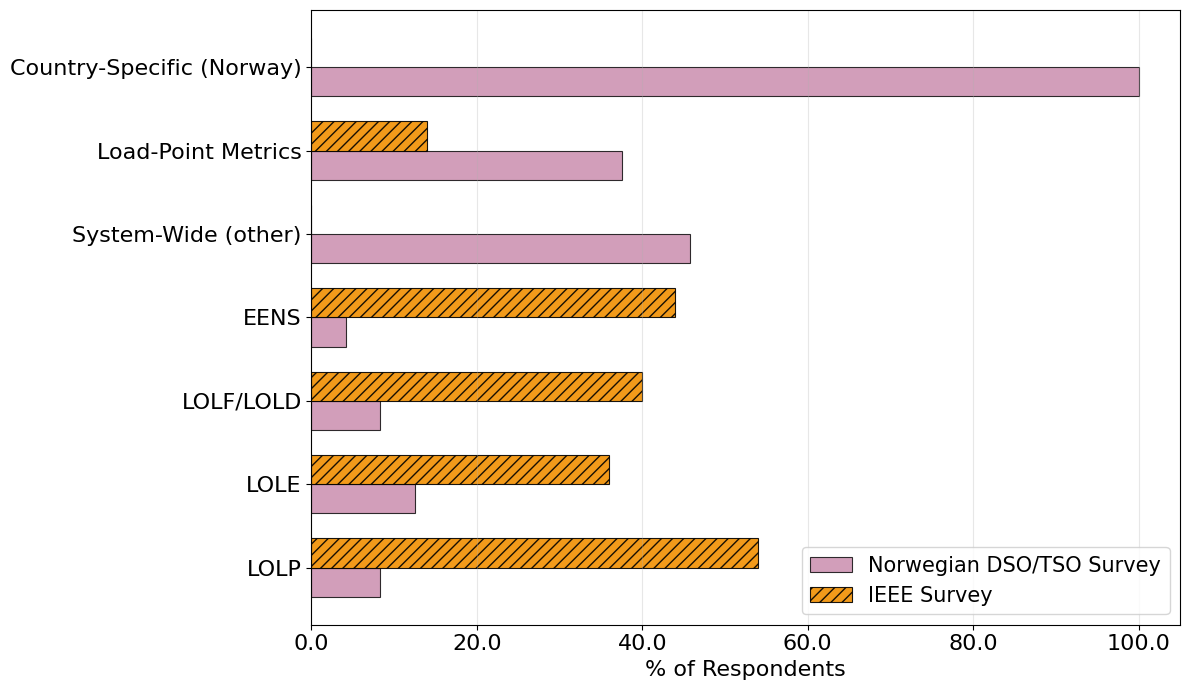

In [32]:
# ========================================
# PLOT INDICATOR COMPARISON
# ========================================
# Generate plot
plot_indicator_category_comparison(
    df_indicator_category_comparison,
    fontsize=16,
    title=False,
    save_path='plots/indicator_comparison_q_ieee.pdf'
)

### Uncertainty comparison

In [33]:
print(df_ieee_uncertainty.columns.tolist())
print(df_ieee_uncertainty['uncertainty_name'].tolist())

['uncertainty_name', 'uncertainty_stochastic_count', 'uncertainty_scenario_count', 'uncertainty_fixed_count']
['Gen outages', 'Load', 'VER generation', 'Tx outages', 'Demand response', 'Maintenance', 'Hydro', 'External resources', 'Costs, etc.', 'Other', 'Total']


In [34]:
# ========================================
# UNCERTAINTY COMPARISON
# ========================================
def count_uncertainty_usage_by_responses(df, feature_map):
    """
    Count uncertainty usage as percentage of TOTAL RESPONSES
    (not unique respondents)
    """
    uncertainty_columns = [col for col in feature_map.keys() 
                          if 'uncertainty' in col.lower()]
    
    total_responses = 0
    uncertainty_counts = {}
    
    for idx, row in df.iterrows():
        for var_code in uncertainty_columns:
            if var_code not in df.columns:
                continue
            
            val = row[var_code]
            if pd.notna(val) and (val == 1 or val == True):
                total_responses += 1  # Count each response
                
                meta = feature_map[var_code]
                features = meta.get('features', meta.get('methods', []))
                if not isinstance(features, list):
                    features = [features]
                
                for feature in features:
                    if feature not in uncertainty_counts:
                        uncertainty_counts[feature] = 0
                    uncertainty_counts[feature] += 1
    
    # Build results based on total responses
    results = []
    for approach, count in uncertainty_counts.items():
        pct = (count / total_responses * 100) if total_responses > 0 else 0
        results.append({
            'Uncertainty_Approach': approach,
            'Count_Using': int(count),
            'Total_Responses': total_responses,
            'pct_binary': round(pct, 1)
        })
    
    results_df = pd.DataFrame(results)
    return results_df


def process_ieee_uncertainty_by_responses(df_ieee_uncertainty):
    """
    Process IEEE uncertainty - percentage of TOTAL RESPONSES
    """
    total_row = df_ieee_uncertainty[df_ieee_uncertainty['uncertainty_name'] == 'Total'].iloc[0]
    
    total_stochastic = total_row['uncertainty_stochastic_count']
    total_scenario = total_row['uncertainty_scenario_count']
    total_fixed = total_row['uncertainty_fixed_count']
    
    # Total responses (sum of all approach counts)
    total_responses = total_stochastic + total_scenario + total_fixed
    
    results = []
    
    pct_stochastic = (total_stochastic / total_responses * 100) if total_responses > 0 else 0
    results.append({
        'Uncertainty_Approach': 'Stochastic',
        'Count_Using': int(total_stochastic),
        'Total_Responses': int(total_responses),
        'pct_binary': round(pct_stochastic, 1)
    })
    
    pct_scenario = (total_scenario / total_responses * 100) if total_responses > 0 else 0
    results.append({
        'Uncertainty_Approach': 'Varied scenarios',
        'Count_Using': int(total_scenario),
        'Total_Responses': int(total_responses),
        'pct_binary': round(pct_scenario, 1)
    })
    
    pct_fixed = (total_fixed / total_responses * 100) if total_responses > 0 else 0
    results.append({
        'Uncertainty_Approach': 'Fixed values',
        'Count_Using': int(total_fixed),
        'Total_Responses': int(total_responses),
        'pct_binary': round(pct_fixed, 1)
    })
    
    results_df = pd.DataFrame(results)
    return results_df


In [35]:
# ========================================
# PLOT UNCERTAINTY COMPARISON
# ========================================

def plot_uncertainty_comparison(df, save_path=None,fontsize=12, title=True):
    """
    Plot uncertainty approach comparison
    """
    df_sorted = df.sort_values('pct_average', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    y = np.arange(len(df_sorted))
    height = 0.35
    
    # Plot bars
    ax.barh(y - height/2, df_sorted['pct_binary_q'], height, 
            label='Norwegian DSO/TSO Survey', 
            alpha=0.8, 
            color='#C786A9',
            edgecolor='black',
            linewidth=0.8)
    
    ax.barh(y + height/2, df_sorted['pct_binary_ieee'], height, 
            label='IEEE Survey', 
            alpha=0.9, 
            color='#F18F01',
            edgecolor='black',
            linewidth=0.8,
            hatch='///')
    
    ax.set_yticks(y)
    ax.set_yticklabels(df_sorted['Uncertainty_Approach'].values, fontsize=fontsize)
    ax.set_xlabel('% of Responses', fontsize=fontsize)
    ax.set_xticklabels(ax.get_xticks(), fontsize=fontsize)
    #ax.set_ylabel('Uncertainty Approach', fontsize=fontsize)
    if title: ax.set_title('Uncertainty Handling Approaches: Norwegian Questionnaire vs IEEE Survey', 
                 fontsize=fontsize+1, fontweight='bold')
    
    ax.legend(fontsize=fontsize-1, loc='lower right')
    ax.grid(axis='x', alpha=0.3, zorder=0)
    ax.set_xlim(0, 50)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
    
    plt.show()


In [36]:
# Combine both FEATURE_IEEE_MAP and METHOD_MAP for uncertainty
UNCERTAINTY_MAP = {}
for key, val in FEATURE_IEEE_MAP.items():
    if 'uncertainty' in key.lower():
        UNCERTAINTY_MAP[key] = val


# 1. Count Norwegian questionnaire uncertainty usage
df_q_uncertainty = count_uncertainty_usage_by_responses(df_q, UNCERTAINTY_MAP)

# 2. Process IEEE uncertainty data
df_ieee_uncertainty_processed = process_ieee_uncertainty_by_responses(df_ieee_uncertainty)

# 3. Merge
df_uncertainty_comparison = pd.merge(
    df_q_uncertainty[['Uncertainty_Approach', 'pct_binary', 'Count_Using', 'Total_Responses']],
    df_ieee_uncertainty_processed[['Uncertainty_Approach', 'pct_binary']],
    on='Uncertainty_Approach',
    how='outer',
    suffixes=('_q', '_ieee')
)

# Fill NaN with 0
df_uncertainty_comparison['pct_binary_q'] = df_uncertainty_comparison['pct_binary_q'].fillna(0)
df_uncertainty_comparison['pct_binary_ieee'] = df_uncertainty_comparison['pct_binary_ieee'].fillna(0)

# Calculate average and difference
df_uncertainty_comparison['pct_average'] = df_uncertainty_comparison[['pct_binary_q', 'pct_binary_ieee']].mean(axis=1)
df_uncertainty_comparison['pct_diff'] = df_uncertainty_comparison['pct_binary_q'] - df_uncertainty_comparison['pct_binary_ieee']

# Sort by average
df_uncertainty_comparison = df_uncertainty_comparison.sort_values('pct_average', ascending=False).reset_index(drop=True)


C:\Users\STSI\AppData\Local\Temp\ipykernel_50700\117574109.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=fontsize)


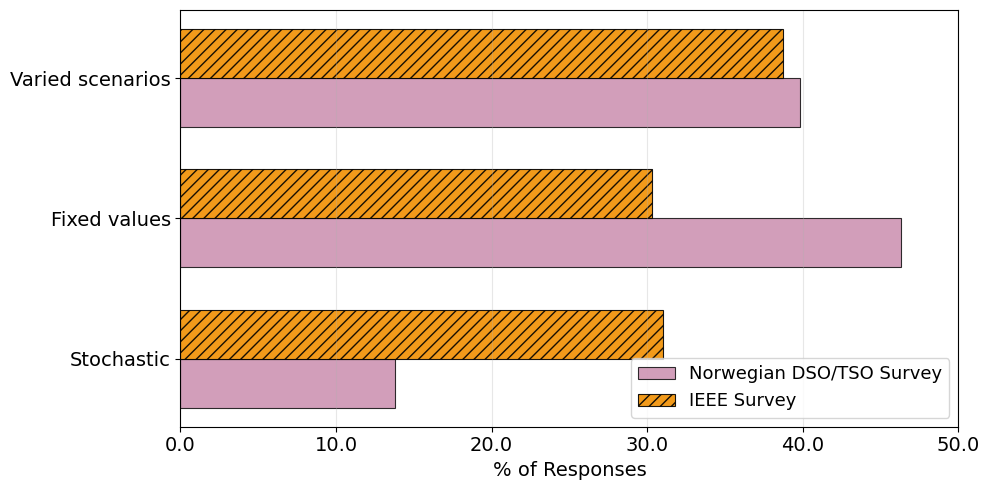

In [31]:

# Plot
plot_uncertainty_comparison(
    df_uncertainty_comparison,
    fontsize=14,
    title=False,
    save_path='plots/uncertainty_comparison_q_ieee.pdf'
)

In [41]:
# ========================================
# PROCESS AND MERGE
# ========================================

# Combine both FEATURE_IEEE_MAP and METHOD_MAP for uncertainty
UNCERTAINTY_MAP = {}
for key, val in FEATURE_IEEE_MAP.items():
    if 'uncertainty' in key.lower():
        UNCERTAINTY_MAP[key] = val
for key, val in METHOD_MAP.items():
    if 'uncertainty' in key.lower():
        UNCERTAINTY_MAP[key] = val

def map_to_0_3_interval(x):
    """Map a float score to discrete 0–3 using the specified intervals."""
    if pd.isna(x):
        return 0
    if x < 0.3:
        return 0
    elif x < 1.3:
        return 1
    elif x < 2.3:
        return 2
    else:
        return 3


### Simple method usage count comparison

In [38]:
df_q_method_count = count_binary_usage(df_q, METHOD_MAP,target='methods')
#df_q_methods = count_binary_feature_usage(df_q, FEATURE_IEEE_MAP)
df_q_method_count.rename(columns={'frac_binary': 'score_q',
                                  'pct_binary':'pct_binary_q',
                                  'pct_notusing':'pct_notusing_q',
                                  'methods':'Method',
                                  'Count_Using':'count_using_q',
                                  'Count_notusing':'count_notusing_q',
                                  'Total_Respondents':'n_responses_q'
                                  },inplace=True)

#### More extensive comparison (dead end)

In [34]:
# questionnaire data



def is_checked(val):
    """
    Normalize various encodings of a 'checked' / 'yes' answer.
    """
    if pd.isna(val):
        return False

    if isinstance(val, (bool, np.bool_)):
        return bool(val)

    if isinstance(val, (int, np.integer)):
        return val == 1

    if isinstance(val, (float, np.floating)):
        return val == 1.0

    if isinstance(val, str):
        s = val.strip().lower()
        return s in {"1", "yes", "y", "ja", "true"}

    return False


def indicator_conversion(val):
    """
    Convert indicator values (0-5 scale) to normalized scores.
    Returns > 0 if the indicator shows usage (2-5 on the scale).
    """
    try:
        val = int(val)
    except (ValueError, TypeError):
        return 0
    
    if val in [0, 1]:
        return 0
    elif val in [2, 3]:
        return 1
    elif val == 4:
        return 2
    elif val == 5:
        return 3
    else:
        return 0


def is_eligible(var_code, row, parent_map):
    """
    A variable is eligible if all parents in the chain are checked.
    Top-level variables (no parent) are always eligible.
    """
    cur = var_code

    while True:
        parent = parent_map.get(cur)

        if parent is None:
            return True

        parent_val = row.get(parent, np.nan)
        if not is_checked(parent_val):
            return False

        cur = parent


def count_method_users(df, method_map, parent_map, list_key="methods"):
    """
    Count how many respondents use each method.
    
    Returns a dataframe with:
    - Method: method name
    - n_users: number of respondents who use this method
    - n_eligible: number of respondents for whom this method was available/asked
    - pct_users: percentage of eligible respondents who use it
    """
    
    # Track which respondents use each method
    method_users = {}      # method -> set of respondent indices who use it
    method_eligible = {}   # method -> set of respondent indices who could use it
    
    for idx, row in df.iterrows():
        for var_code, meta in method_map.items():
            if var_code not in df.columns:
                continue

            # Check if this question is eligible for this respondent
            if not is_eligible(var_code, row, parent_map):
                continue

            val = row[var_code]
            
            # Determine if method is used
            if meta.get("indicator", False):
                is_used = indicator_conversion(val) > 0
            else:
                is_used = is_checked(val)

            # Get methods from this variable
            methods = meta.get(list_key, [])
            if not isinstance(methods, list):
                methods = [methods]

            for method in methods:
                # Initialize sets if needed
                if method not in method_eligible:
                    method_eligible[method] = set()
                    method_users[method] = set()
                
                # This respondent was eligible for this method
                method_eligible[method].add(idx)
                
                # Mark as user if they checked/used it
                if is_used:
                    method_users[method].add(idx)

    # Build results dataframe
    results = []
    for method in method_eligible.keys():
        n_eligible = len(method_eligible[method])
        n_users = len(method_users[method])
        pct = (n_users / n_eligible * 100) if n_eligible > 0 else 0.0
        
        results.append({
            'Method': method,
            'n_users': n_users,
            'n_eligible': n_eligible,
            'pct_users': pct
        })
    
    results_df = pd.DataFrame(results).sort_values('n_users', ascending=False).reset_index(drop=True)
    
    return results_df


In [35]:
# ========================================
# 1. QUESTIONNAIRE ANALYSIS (keep 1-3 range)
# ========================================
def map_to_0_3_interval(x):
    """Map a float score to discrete 0–3 using the specified intervals."""
    if pd.isna(x):
        return 0
    if x < 0.3:
        return 0
    elif x < 1.3:
        return 1
    elif x < 2.3:
        return 2
    else:
        return 3

def old_count_method_usage_with_scores(df, method_map, min_score=0):
    """
    Calculate method usage with scores in 1-3 range
    Includes ALL respondents in mean calculation (including zeros)
    """
    method_respondent_scores = {}
    total_respondents = len(df)  # Total number of respondents
    
    for idx, row in df.iterrows():
        respondent_method_scores = {}
        
        for var_code, meta in method_map.items():
            if var_code not in df.columns:
                continue
                
            val = row[var_code]
            if pd.notna(val):
                is_indicator = meta.get('indicator', False)
                
                if is_indicator:
                    score = indicator_conversion(val)
                else:
                    if val is True or val == 1:
                        score = meta.get('score', 0)
                    else:
                        score = 0
                
                if score > min_score:
                    methods = meta.get('methods', [])
                    if not isinstance(methods, list):
                        methods = [methods]
                    
                    for method in methods:
                        if method not in respondent_method_scores:
                            respondent_method_scores[method] = score
                        else:
                            respondent_method_scores[method] = max(
                                respondent_method_scores[method], 
                                score
                            )
        
        # Store scores for this respondent (even if 0 for all methods)
        for method, score in respondent_method_scores.items():
            if method not in method_respondent_scores:
                method_respondent_scores[method] = {}
            method_respondent_scores[method][idx] = score
    
    # Calculate statistics INCLUDING all respondents (zeros)
    results = []
    for method, respondent_scores in method_respondent_scores.items():
        scores_list = list(respondent_scores.values())
        
        # Count respondents at each score level (only non-zero)
        count_score_3 = sum(1 for s in scores_list if s == 3)
        count_score_2 = sum(1 for s in scores_list if s == 2)
        count_score_1 = sum(1 for s in scores_list if s == 1)
        count_non_zero = len(scores_list)  # Respondents who scored > 0
        
        # IMPORTANT: Include all respondents (including zeros) in mean calculation
        total_score = sum(scores_list)
        mean_score = total_score / total_respondents  # Divide by ALL respondents, not just non-zero
        
        results.append({
            'Method': method,
            'Total_Respondents': total_respondents,
            'Respondents_Non_Zero': count_non_zero,
            'score_q': round(mean_score, 2),  # Mean including zeros
            'q_n_3': count_score_3,
            'q_n_2': count_score_2,
            'q_n_1': count_score_1,
            'q_n_0': total_respondents - count_non_zero,  # Respondents who scored 0
        })
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('score_q', ascending=False).reset_index(drop=True)
    
    return results_df, method_respondent_scores



def count_item_usage_with_scores(df, mapping, list_key='methods', label_col='Method',
                                 min_score=0, binary=False,sum=False):
    """
    Generic questionnaire usage counting for items (methods/desires).

    Parameters
    ----------
    df : DataFrame
    mapping : dict
        Like METHOD_MAP, with mapping[var_code][list_key] = list of item names.
    list_key : str
        'methods' or 'desires'.
    label_col : str
        Output label column name.
    min_score : float
        Minimum raw score to include a contribution.
    binary : bool
        - False (default): average scores per respondent–item, map to 0–3 intervals.
        - True : treat any non-zero contribution as 1 for that respondent–item, else 0.

    Returns
    -------
    results_df : DataFrame
    item_respondent_scores : dict[item -> {respondent_idx: per-respondent score}]
    """

    item_respondent_scores = {}   # item -> {respondent_idx: score}
    total_respondents = len(df)

    # First pass: collect ALL scores per (respondent, item)
    for idx, row in df.iterrows():
        tmp_scores = {}  # item -> list of raw scores

        for var_code, meta in mapping.items():
            if var_code not in df.columns:
                continue

            val = row[var_code]
            if pd.isna(val):
                continue

            is_indicator = meta.get('indicator', False)

            if is_indicator:
                score = indicator_conversion(val)
            else:
                if val is True or val == 1:
                    score = meta.get('score', 0)
                else:
                    score = 0

            if score > min_score:
                items = meta.get(list_key, [])
                if not isinstance(items, list):
                    items = [items]

                for item in items:
                    tmp_scores.setdefault(item, []).append(score)

        # Convert to per‑item score for this respondent
        for item, score_list in tmp_scores.items():
            if binary:
                # Any non-zero contribution → 1
                item_score = 1
            else:
                if sum:
                    # sum of all contributions for this respondent–item
                    item_score = sum(score_list)
                else:  # default: mean
                    item_score = sum(score_list) / len(score_list)

            if item not in item_respondent_scores:
                item_respondent_scores[item] = {}
            item_respondent_scores[item][idx] = item_score

    # Second pass: aggregate per item
    results = []
    for item, respondent_scores in item_respondent_scores.items():
        per_resp_scores = list(respondent_scores.values())

        if binary:
            # Binary case: scores are 0/1 already
            count_score_1 = sum(1 for s in per_resp_scores if s == 1)
            count_score_0 = total_respondents - count_score_1
            count_score_2 = count_score_3 = 0
            count_non_zero = count_score_1

            total_score = sum(per_resp_scores)
            mean_score = total_score / total_respondents

        else:
            # Interval case: map respondent-level averages to 0–3
            discrete_scores = [map_to_0_3_interval(s) for s in per_resp_scores]

            count_score_3 = sum(1 for s in discrete_scores if s == 3)
            count_score_2 = sum(1 for s in discrete_scores if s == 2)
            count_score_1 = sum(1 for s in discrete_scores if s == 1)
            count_non_zero = sum(1 for s in discrete_scores if s > 0)
            count_score_0 = total_respondents - count_non_zero

            total_score = sum(per_resp_scores)
            mean_score = total_score / total_respondents

        results.append({
            label_col: item,
            'Total_Respondents': total_respondents,
            'Respondents_Non_Zero': count_non_zero,
            'score_q': round(mean_score, 2),
            'q_n_3': count_score_3,
            'q_n_2': count_score_2,
            'q_n_1': count_score_1,
            'q_n_0': count_score_0,
        })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('score_q', ascending=False).reset_index(drop=True)

    return results_df, item_respondent_scores

def count_method_usage_with_scores(df, method_map, min_score=0, binary=False):
    return count_item_usage_with_scores(
        df, method_map,
        list_key='methods',
        label_col='Method',
        min_score=min_score,
        binary=binary
    )

def count_desire_usage_with_scores(df, method_map, min_score=0, binary=False):
    return count_item_usage_with_scores(
        df, method_map,
        list_key='desires',
        label_col='Desire',
        min_score=min_score,
        binary=binary
    )





In [36]:
# Simpler version just to count the occurences of each method in the questionnaire
import numpy as np
import pandas as pd


# ----------------------------------------------------------------------
# Shared helpers
# ----------------------------------------------------------------------

def is_checked(val):
    """
    Normalize various encodings of a 'checked' / 'yes' answer.
    Adjust this to match your questionnaire encoding.
    """
    if pd.isna(val):
        return False

    # Nullable boolean support (pd.NA)
    # Note: bool(pd.NA) raises, so avoid raw bool().
    if isinstance(val, (bool, np.bool_)):
        return bool(val)

    if isinstance(val, (int, np.integer)):
        return val == 1

    if isinstance(val, (float, np.floating)):
        # 1.0, etc.
        return val == 1.0

    if isinstance(val, str):
        s = val.strip().lower()
        return s in {"1", "yes", "y", "ja", "true"}

    # Fallback: treat other truthy values as not-checked (conservative)
    return False


def is_eligible(var_code, row, parent_map):
    """
    A variable is eligible iff:
      - if it has a parent, that parent is 'checked' AND that parent is itself eligible
      - if it has no parent (top-level): always eligible
    """
    cur = var_code

    while True:
        parent = parent_map.get(cur)

        if parent is None:
            # Reached a top-level question → always eligible
            return True

        parent_val = row.get(parent, np.nan)
        if not is_checked(parent_val):
            return False

        # Climb up the chain
        cur = parent



# ----------------------------------------------------------------------
# Updated occurrence counter (just counts chosen, no opportunity logic)
# ----------------------------------------------------------------------

def count_method_occurrences(df, mapping, list_key="methods", label_col="Method"):
    counts = {}  # method -> count

    for _, row in df.iterrows():
        for var_code, meta in mapping.items():
            if var_code not in df.columns:
                continue

            val = row[var_code]
            methods = meta.get(list_key, [])
            if not isinstance(methods, list):
                methods = [methods]

            if meta.get("indicator", False):
                conv = indicator_conversion(val)
                if conv <= 0:
                    continue
                # treat any positive converted value as one "use"
                for item in methods:
                    counts[item] = counts.get(item, 0) + 1
            else:
                if not is_checked(val):
                    continue
                for item in methods:
                    counts[item] = counts.get(item, 0) + 1

    results_df = (
        pd.DataFrame(
            [(item, n) for item, n in counts.items()],
            columns=[label_col, "count_checked"],
        )
        .sort_values("count_checked", ascending=False)
        .reset_index(drop=True)
    )
    return results_df




# ----------------------------------------------------------------------
# Updated opportunities/choices counter with recursive parent check
# ----------------------------------------------------------------------


def count_method_opportunities(df, method_map, parent_map, list_key="methods"):
    data = {}  # method -> {respondent_idx: [chosen, opportunities]}

    for idx, row in df.iterrows():
        for var_code, meta in method_map.items():
            if var_code not in df.columns:
                continue

            if not is_eligible(var_code, row, parent_map):
                continue

            val = row[var_code]
            methods = meta.get(list_key, [])
            if not isinstance(methods, list):
                methods = [methods]

            if meta.get("indicator", False):
                conv = indicator_conversion(val)
                chosen_here = conv > 0          # collapse 1/2/3 → True
            else:
                chosen_here = is_checked(val)

            for m in methods:
                if m not in data:
                    data[m] = {}
                if idx not in data[m]:
                    data[m][idx] = [0, 0]  # [chosen, opportunities]

                data[m][idx][1] += 1               # opportunity
                if chosen_here:
                    data[m][idx][0] += 1           # one counted use

    records = []
    summary_rows = []

    for method, resp_dict in data.items():
        total_chosen = 0
        total_opp = 0

        for resp_idx, (chosen, opp) in resp_dict.items():
            total_chosen += chosen
            total_opp += opp
            records.append(
                {
                    "respondent": resp_idx,
                    "Method": method,
                    "chosen": chosen,
                    "opportunities": opp,
                    "fraction": chosen / opp if opp > 0 else 0.0,
                }
            )

        summary_rows.append(
            {
                "Method": method,
                "total_chosen": total_chosen,
                "total_opportunities": total_opp,
                "overall_fraction": total_chosen / total_opp if total_opp > 0 else 0.0,
            }
        )

    per_respondent_df = pd.DataFrame(records)
    per_method_df = (
        pd.DataFrame(summary_rows)
        .sort_values("overall_fraction", ascending=False)
        .reset_index(drop=True)
    )

    return per_method_df, per_respondent_df




def classify_usage(frac,frequent_limit=0.67,sporadic_limit=0.33, never_limit=0.1):
    if frac >= frequent_limit:
        return 3
    elif frac >= sporadic_limit:
        return 2
    elif frac >= never_limit:
        return 1
    else:
        return 0

def summarize_usage_by_method(per_respondent_df,
                              min_2=2,
                              min_3=3,
                              frequent_limit=0.67,
                              sporadic_limit=0.33,
                              never_limit=0.1):
    """
    For each method, count how many respondents fall in usage classes:
      3 = frequently used
      2 = sporadically used
      1 = almost never used
      0 = intermediate

    For classes 2 and 3 a respondent is only counted if opportunities >= min_opp_23.
    """

    df = per_respondent_df.copy()

    # classify each respondent–method row
    df["usage_class_raw"] = df["fraction"].apply(
        lambda f: classify_usage(f,
                                 frequent_limit=frequent_limit,
                                 sporadic_limit=sporadic_limit,
                                 never_limit=never_limit)
    )

    # apply minimum-opportunities rule:
    # if opportunities < min_opp_23, downgrade any 2/3 to class 1 (or 0, as you prefer)

    df["usage_class"] = df["usage_class_raw"]  # start from raw class

    # too few opps for 3 → downgrade to 2
    df.loc[(df["opportunities"] < min_3) & (df["usage_class"] == 3), "usage_class"] = 2

    # too few opps for 2 or 3 → downgrade to 1
    df.loc[(df["opportunities"] < min_2) & df["usage_class"].isin([2, 3]), "usage_class"] = 1
    


    # aggregate counts per method
    summary = (
        df.groupby("Method")["usage_class"]
          .value_counts()
          .unstack(fill_value=0)
          .rename(columns={
              3: "q_n_3",
              2: "q_n_2",
              1: "q_n_1",
              0: "q_n_0",
          })
          .reset_index()
    )


    # optionally add total respondents per method
    summary["n_respondents"] = summary[
        ["q_n_3", "q_n_2", "q_n_1", "q_n_0"]
    ].sum(axis=1)
        #add percentages of users
            # Percentages per item
    for s, col_name in zip([3, 2, 1, 0], ["pct_3", "pct_2", "pct_1", "pct_0"]):
        count_col = f"q_n_{s}"
        summary[col_name] = (
            summary[count_col] /
            summary["n_respondents"].where(summary["n_respondents"] > 0, 1)
        ) * 100.0
    summary['score_q'] = (
        3 * summary['pct_3'] +
        2 * summary['pct_2'] +
        1 * summary['pct_1'] +
        0 * summary['pct_0']
        ) / 100.0    
    return summary, df


#### interview data prep

In [39]:
# ========================================
# 2. INTERVIEW ANALYSIS (keep 1-3 range)
# ========================================
def old_calc_method_usage(df):
    """
    Calculate interview method score distribution (0–3) per method.

    Input:
      - df: rows = respondents, columns = method score columns (0–3)

    Output:
      - DataFrame with one row per method and columns:
        Method, n_3, n_2, n_1, n_0, pct_3, pct_2, pct_1, pct_0, n_responses
    """
    method_cols = [col for col in df.columns if col.startswith("Method")]

    # Total valid responses per method (non-NaN)
    n_resp = df[method_cols].notna().sum()

    # Count scores 3,2,1,0 per method
    counts_3 = (df[method_cols] == 3).sum()
    counts_2 = (df[method_cols] == 2).sum()
    counts_1 = (df[method_cols] == 1).sum()
    counts_0 = (df[method_cols] == 0).sum()

    results_df = pd.DataFrame({
        'Method_raw': method_cols,
        'Method': [col.replace("Methods-", "").replace("Method-", "").strip()
                   for col in method_cols],
        'n_responses': n_resp.values,
        'i_n_3': counts_3.values,
        'i_n_2': counts_2.values,
        'i_n_1': counts_1.values,
        'i_n_0': counts_0.values,
    })

    # Percentages per method (row-wise, based on n_responses)
    for s, col_name in zip(
        [3, 2, 1, 0],
        ['pct_3', 'pct_2', 'pct_1', 'pct_0']
    ):
        results_df[col_name] = (
            results_df[f'i_n_{s}'] / results_df['n_responses'].where(results_df['n_responses'] > 0, 1)
        ) * 100.0
    
    results_df['score_i'] = (3*results_df['pct_3'] + 2*results_df['pct_2'] + 1*results_df['pct_1'] + 0*results_df['pct_0']) / 100.0
    
    return results_df

def calc_item_usage(df, prefix="Method", label_col="Method", binary=False):
    """
    Calculate interview item (method/desire/...) score distribution.

    Parameters
    ----------
    df : DataFrame
        Rows = respondents, columns = item score columns (floats).
    prefix : str
        Column name prefix to select, e.g. "Method" or "Desire".
    label_col : str
        Output label column name ("Method", "Desire", ...).
    binary : bool
        - False (default): map float scores to 0–3 via map_to_0_3_interval.
        - True : any non-zero (after mapping) counted as 1, else 0.
    """

    item_cols = [col for col in df.columns if col.startswith(prefix)]
    if not item_cols:
        print(f"No columns starting with '{prefix}' found.")
        return pd.DataFrame()

    # Raw float scores
    df_scores = df[item_cols].astype(float)

    # Discrete 0–3 mapping
    discrete = df_scores.applymap(map_to_0_3_interval)

    n_resp = df_scores.notna().sum()

    if binary:
        # Collapse to 0/1 after interval mapping: any level > 0 → 1
        bin_vals = (discrete > 1).astype(int) # count only values larger than 1 as "using"
        i_n_1 = bin_vals.sum()
        i_n_0 = n_resp - i_n_1
        i_n_2 = pd.Series(0, index=item_cols)
        i_n_3 = pd.Series(0, index=item_cols)

        results_df = pd.DataFrame({
            f"{label_col}_raw": item_cols,
            label_col: [col.replace(f"{prefix}s-", "").replace(f"{prefix}-", "").strip()
                        for col in item_cols],
            'n_responses': n_resp.values,
            'i_n_3': i_n_3.values,
            'i_n_2': i_n_2.values,
            'i_n_1': i_n_1.values,
            'i_n_0': i_n_0.values,
        })

        # Percentages
        results_df['pct_3'] = 0.0
        results_df['pct_2'] = 0.0
        results_df['pct_1'] = (results_df['i_n_1'] /
                               results_df['n_responses'].where(results_df['n_responses'] > 0, 1)) * 100.0
        results_df['pct_0'] = (results_df['i_n_0'] /
                               results_df['n_responses'].where(results_df['n_responses'] > 0, 1)) * 100.0

        # Binary mean in [0,1]
        results_df['score_i'] = results_df['pct_1'] / 100.0

    else:
        # Full 0–3 distribution
        counts_3 = (discrete == 3).sum()
        counts_2 = (discrete == 2).sum()
        counts_1 = (discrete == 1).sum()
        counts_0 = (discrete == 0).sum()

        results_df = pd.DataFrame({
            f"{label_col}_raw": item_cols,
            label_col: [col.replace(f"{prefix}s-", "").replace(f"{prefix}-", "").strip()
                        for col in item_cols],
            'n_responses': n_resp.values,
            'i_n_3': counts_3.values,
            'i_n_2': counts_2.values,
            'i_n_1': counts_1.values,
            'i_n_0': counts_0.values,
        })

        # Percentages per item
        for s, col_name in zip([3, 2, 1, 0], ['pct_3', 'pct_2', 'pct_1', 'pct_0']):
            results_df[col_name] = (
                results_df[f'i_n_{s}'] /
                results_df['n_responses'].where(results_df['n_responses'] > 0, 1)
            ) * 100.0

        # Mean discrete score in 0–3 range
        results_df['score_i'] = (
            3 * results_df['pct_3'] +
            2 * results_df['pct_2'] +
            1 * results_df['pct_1'] +
            0 * results_df['pct_0']
        ) / 100.0

    return results_df

def calc_method_usage(df, binary=False):
    return calc_item_usage(df, prefix="Method", label_col="Method", binary=binary)
def calc_method_usage_binary(df, binary=True):
    return calc_item_usage(df, prefix="Method", label_col="Method", binary=binary)

def calc_desire_usage(df, binary=False):
    return calc_item_usage(df, prefix="Desire", label_col="Desire", binary=binary)


In [42]:
df_i_method_count=calc_method_usage_binary(df_i)
df_i_method_count.rename(columns={
    'n_responses':'n_responses_i',
    'i_n_1':'count_using_i',
    'i_n_0':'count_notusing_i',
    'pct_1':'pct_binary_i',
    'pct_0':'pct_notusing_i'
    },inplace=True)

C:\Users\STSI\AppData\Local\Temp\ipykernel_27344\1293518681.py:76: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  discrete = df_scores.applymap(map_to_0_3_interval)


In [43]:
print(df_i_method_count.columns)
print(df_q_method_count.columns)

Index(['Method_raw', 'Method', 'n_responses_i', 'i_n_3', 'i_n_2',
       'count_using_i', 'count_notusing_i', 'pct_3', 'pct_2', 'pct_binary_i',
       'pct_notusing_i', 'score_i'],
      dtype='object')
Index(['Method', 'count_using_q', 'count_notusing_q', 'n_responses_q',
       'pct_binary_q', 'pct_notusing_q', 'score_q'],
      dtype='object')


### Merging

In [44]:
# ========================================
# 3. MERGE RESULTS (both in 1-3 range)
# ========================================

def merge_method_results(df_q, df_i, on='Method'):
    """
    Merge questionnaire (df_q) and interview (df_i) results.
    """

    # Outer join on method name
    merged_df = pd.merge(df_q, df_i, on=on, how='outer')

    # Ensure score columns exist and fill NaN with 0 for averaging
    merged_df['score_q'] = merged_df.get('score_q', 0).fillna(0)
    merged_df['score_i'] = merged_df.get('score_i', 0).fillna(0)

  

    #summing the n_responses
    merged_df['n_t'] = merged_df['n_responses_i'].fillna(0) + merged_df['n_responses_q'].fillna(0)
    #summing the counts using
    merged_df['count_using_t'] = merged_df['count_using_i'].fillna(0) + merged_df['count_using_q'].fillna(0)
    merged_df['count_notusing_t']=merged_df['n_t']-merged_df['count_using_t']
    #calculating total percentage
    merged_df['pct_binary_t']=(merged_df['count_using_t']/merged_df['n_t'])*100
    merged_df['pct_binary_t']=merged_df['pct_binary_t'].round(2)

    merged_df['pct_notusing_t']=(merged_df['count_notusing_t']/merged_df['n_t'])*100
    merged_df['pct_notusing_t']=merged_df['pct_notusing_t'].round(2)
    
    # Average of non-zero scores (as before)

    merged_df['average_score']=merged_df['count_using_t']/merged_df['n_t']
    # Round scores
    merged_df['score_q'] = merged_df['score_q'].round(2)
    merged_df['score_i'] = merged_df['score_i'].round(2)
    merged_df['average_score'] = merged_df['average_score'].round(2)

    # Keep and rename columns
    final_df = merged_df[[
        'Method',
        'n_responses_i',
        'n_responses_q',
        'n_t',
        'count_using_i',
        'count_using_q',
        'count_using_t',
        'count_notusing_i',
        'count_notusing_q',
        'count_notusing_t',
        'pct_binary_i',
        'pct_binary_q',
        'pct_binary_t',
        'pct_notusing_i',
        'pct_notusing_q',
        'pct_notusing_t',
        'score_i',
        'score_q',
        'average_score']].fillna(0)
    return final_df


In [45]:
df_merged_count = merge_method_results(df_i_method_count,df_q_method_count)
df_merged_count.to_csv('data/method_count_comparison_results.csv', index=False)

#### Plotting with the simpler count usage

In [50]:
#diverging bar plot
def plot_method_usage_diverging(
        df,
        top_k=None,
        method_col='Method',
        figsize=(12, 8),
        fontsize=12,
        title=True,
        save_path=None,
        mode='total',  # 'total' (default) or 'all'
        sort_by='pct_binary_t'  # column to sort by
    ):
    """
    Diverging barh plot showing % using (right) vs % not using (left)
    for Interview, Questionnaire, and/or Total per method.

    mode:
      - 'total': plot only Total bar per method
      - 'all'  : plot Interview, Questionnaire, and Total separately
    """

    # Filter out methods with zero users
    df_filtered = df[df['count_using_t'] > 0].copy()
    if df_filtered.empty:
        print("No methods with any users.")
        return

    # Calculate percentages for each source
    df_filtered['pct_notusing_i'] = 100 - df_filtered['pct_binary_i']
    df_filtered['pct_notusing_q'] = 100 - df_filtered['pct_binary_q']
    df_filtered['pct_notusing_t'] = 100 - df_filtered['pct_binary_t']

    # Sort by specified column
    df_sorted = df_filtered.sort_values(by=sort_by, ascending=True)
    
    # Select top_k if requested
    if top_k is not None:
        df_sorted = df_sorted.nlargest(top_k, sort_by)
        df_sorted = df_sorted.sort_values(by=sort_by, ascending=True)

    # Positions
    y_base = np.arange(len(df_sorted))

    if mode == 'all':
        bar_height = 0.25
        offsets = {'i': -bar_height, 'q': 0.0, 't': +bar_height}
    else:  # 'total'
        bar_height = 0.60
        offsets = {'t': 0.0}

    fig, ax = plt.subplots(figsize=figsize)

    # Colors: using (blue), not using (orange)
    color_using = '#4575b4'         # Blue (neutral positive)
    color_notusing = '#d9d9d9'      # Light gray (neutral, not alarming)
    # Change colors to neutral palette




    # Colors for different sources (in 'all' mode)
    colors_map = {
        'i': {'using': '#B25F00', 'notusing': '#FBE4B8'},
        'q': {'using': '#8D436A', 'notusing': '#F0D9E7'},
        't': {'using': color_using, 'notusing': color_notusing}
    }

    def plot_diverging_bars(prefix, label, offset):
        """
        Plot diverging bars: not using (left/negative) and using (right/positive)
        """
        if mode == 'all':
            colors = colors_map[prefix]
        else:
            colors = colors_map['t']

        pct_notusing = df_sorted[f'pct_notusing_{prefix}'].values
        pct_using = df_sorted[f'pct_binary_{prefix}'].values

        # Not using (left side, negative)
        bars_notusing = ax.barh(
            y_base + offset,
            -pct_notusing,
            left=0.0,
            height=bar_height,
            color=colors['notusing'],
            edgecolor='black',
            linewidth=0.5
        )

        # Using (right side, positive)
        bars_using = ax.barh(
            y_base + offset,
            pct_using,
            left=0.0,
            height=bar_height,
            color=colors['using'],
            edgecolor='black',
            linewidth=0.5
        )

        return bars_notusing, bars_using

    # Plot bars
    bars_dict = {}
    if mode == 'all':
        bars_dict['i'] = plot_diverging_bars('i', 'Interview', offsets['i'])
        bars_dict['q'] = plot_diverging_bars('q', 'Questionnaire', offsets['q'])
        bars_dict['t'] = plot_diverging_bars('t', 'Total', offsets['t'])
    else:  # 'total'
        bars_dict['t'] = plot_diverging_bars('t', 'Total', offsets['t'])

    # Y labels with sample sizes
    y_labels = []
    for idx, row in df_sorted.iterrows():
        method_name = str(row[method_col]).capitalize()
        
        if mode == 'all':
            n_q = int(row['n_responses_q'])
            n_i = int(row['n_responses_i'])
            n_t = int(row['n_t'])
            y_labels.append(f'{method_name} (n={n_t}: Q={n_q}, I={n_i})')
        else:
            n_t = int(row['n_t'])
            y_labels.append(f'{method_name} (n={n_t})')
    
    ax.set_yticks(y_base)
    ax.set_yticklabels(y_labels, fontsize=fontsize)

    # X axis (symmetric around 0)
    ax.set_xlabel('% of respondents', fontsize=fontsize)
    max_val = max(
        df_sorted['pct_notusing_t'].max(),
        df_sorted['pct_binary_t'].max()
    )
    bound = max(max_val, 50)
    ax.set_xlim(-bound, bound)
    ax.set_xticks(np.arange(-bound, bound + 1, 20))
    ax.axvline(0, color='gray', lw=1.5)

    # Add percentage labels (only for 'total' mode to avoid clutter)
    min_pct = 8
    if mode == 'total':
        bars_notusing, bars_using = bars_dict['t']
        
        # Not using labels (left side)
        for bar, pct in zip(bars_notusing, df_sorted['pct_notusing_t'].values):
            if pct < min_pct:
                continue
            x = bar.get_x() + bar.get_width() / 2.0
            y = bar.get_y() + bar.get_height() / 2.0
            ax.text(
                x, y, f'{pct:.0f}%',
                ha='center', va='center',
                fontsize=fontsize-2, color='black'
            )
        
        # Using labels (right side)
        for bar, pct in zip(bars_using, df_sorted['pct_binary_t'].values):
            if pct < min_pct:
                continue
            x = bar.get_x() + bar.get_width() / 2.0
            y = bar.get_y() + bar.get_height() / 2.0
            ax.text(
                x, y, f'{pct:.0f}%',
                ha='center', va='center',
                fontsize=fontsize-2, color='white'
            )

    # Title
    if title:
        if mode == 'all':
            t = 'Method usage: Using vs Not Using\n(Interview, Questionnaire, and Total)'
        else:
            t = 'Method usage: Using vs Not Using'
        if top_k is not None:
            t += f'\n(Top {top_k} methods by usage)'
        ax.set_title(t, fontsize=fontsize+1, fontweight='bold')

    # Legend
    # In the legend, be explicit about the meaningfulness:

    if mode == 'all':
        legend_handles = [
            Patch(facecolor=colors_map['i']['using'], edgecolor='black', 
                  linewidth=0.5, label='Interview - Using'),
            Patch(facecolor=colors_map['q']['using'], edgecolor='black', 
                  linewidth=0.5, label='Questionnaire - Using'),
            Patch(facecolor=colors_map['t']['using'], edgecolor='black', 
                  linewidth=0.5, label='Total - Using'),
            Patch(facecolor='none', edgecolor='none', label=''),  # spacer
            Patch(facecolor=colors_map['i']['notusing'], edgecolor='black', 
                  linewidth=0.5, label='Interview - Not Using'),
            Patch(facecolor=colors_map['q']['notusing'], edgecolor='black', 
                  linewidth=0.5, label='Questionnaire - Not Using'),
            Patch(facecolor=colors_map['t']['notusing'], edgecolor='black', 
                  linewidth=0.5, label='Total - Not Using'),
        ]
        ncol = 3
    else:
        legend_handles = [
        Patch(facecolor=color_using, edgecolor='black', linewidth=0.5,
            label='Using method'),
        Patch(facecolor=color_notusing, edgecolor='black', linewidth=0.5,
            label='Not using method'),
            ]
        ncol = 2

    box = ax.get_position()
    ax.set_position([box.x0, box.y0 + box.height * 0.12,
                     box.width, box.height * 0.88])

    ax.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.05),
        ncol=ncol,
        fontsize=fontsize-1,
        frameon=True
    )

    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        if not str(save_path).endswith('.pdf'):
            save_path = str(save_path) + '.pdf'
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)

    plt.show()
    return df_sorted


#simple horisontal bars
def plot_method_usage_hbar(
        df,
        top_k=None,
        method_col='Method',
        figsize=(12, 8),
        fontsize=12,
        title=True,
        save_path=None,
        high_threshold=66.7,  #percentage (0-100 scale)
        low_threshold=33.3,   #percentage (0-100 scale)
        min_sample_size=None, 
        show_sample_size=True,
        mode='total',
        sort_by='pct_binary_t',
        show_confidence=False,
        show_values=True,
        auto_adjust_figsize=True
    ):
    """
    Simple horizontal bar chart showing % of respondents using each method.
    Clean, readable, and focused on adoption rates only.
    
    Parameters:
    -----------
    high_threshold : float
        Percentage threshold for high adoption (default: 66.7%)
    low_threshold : float
        Percentage threshold for low adoption (default: 33.3%)
    show_confidence : bool
        If True, adds error bars showing 95% confidence intervals
    auto_adjust_figsize : bool
        If True, automatically adjusts figure height based on number of methods
    """
    
    # Filter out methods with zero users
    df_filtered = df[df['count_using_t'] > 0].copy()
    if df_filtered.empty:
        print("No methods with any users.")
        return
        # NEW: Filter out methods below minimum respondent threshold
    if min_sample_size is not None:
        df_filtered = df_filtered[df_filtered['n_t'] >= min_sample_size].copy()
    # Sort and filter
    df_sorted = df_filtered.sort_values(by=sort_by, ascending=True)
    
    if top_k is not None:
        df_sorted = df_sorted.nlargest(top_k, sort_by)
        df_sorted = df_sorted.sort_values(by=sort_by, ascending=True)
    
    # AUTOMATICALLY ADJUST FIGURE HEIGHT based on number of methods
    n_methods = len(df_sorted)
    if auto_adjust_figsize:
        # Rule of thumb: 0.35 inches per method, minimum 8 inches
        optimal_height = max(8, n_methods * 0.35)
        figsize = (figsize[0], optimal_height)
    
    # Calculate confidence intervals (Wilson score interval for proportions)
    if show_confidence:
        from scipy import stats
        df_sorted['ci_lower'] = df_sorted.apply(
            lambda row: 100 * stats.binom.interval(
                0.95, row['n_t'], row['pct_binary_t']/100
            )[0] / row['n_t'], axis=1
        )
        df_sorted['ci_upper'] = df_sorted.apply(
            lambda row: 100 * stats.binom.interval(
                0.95, row['n_t'], row['pct_binary_t']/100
            )[1] / row['n_t'], axis=1
        )
        df_sorted['ci_err_lower'] = df_sorted['pct_binary_t'] - df_sorted['ci_lower']
        df_sorted['ci_err_upper'] = df_sorted['ci_upper'] - df_sorted['pct_binary_t']
    
    y_base = np.arange(len(df_sorted))
    
    if mode == 'all':
        bar_height = 0.25
        offsets = {'i': -bar_height, 'q': 0.0, 't': +bar_height}
    else:
        # ADAPTIVE bar height - thinner bars for many methods
        if n_methods > 25:
            bar_height = 0.60
        elif n_methods > 20:
            bar_height = 0.65
        else:
            bar_height = 0.70
        offsets = {'t': 0.0}
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # IMPROVED COLOR SCHEME - better contrast between tiers
    color_high = '#1f78b4'       # Strong blue (high adoption)
    color_medium = '#a6cee3'     # Distinct light blue (medium adoption)
    color_low = '#fdbf6f'        # Warm orange (low adoption)
    
    # Colors for different sources in 'all' mode
    colors_i = '#C17221'  # Warm brown for interview
    colors_q = '#9B5A7D'  # Purple for questionnaire
    colors_t = color_high # Blue for total
    
    def get_bar_color(pct_value, mode_type):
        """
        Return color based on adoption percentage.
        Uses gradient for visual encoding in 'total' mode.
        """
        if mode == 'all':
            color_map = {'i': colors_i, 'q': colors_q, 't': colors_t}
            return color_map[mode_type]
        else:
            # Gradient based on adoption level using thresholds
            if pct_value >= high_threshold:
                return color_high
            elif pct_value >= low_threshold:
                return color_medium
            else:
                return color_low
    
    def plot_bars(prefix, label, offset):
        """Plot horizontal bars showing % using the method"""
        pct_values = df_sorted[f'pct_binary_{prefix}'].values
        
        if mode == 'total':
            # Use gradient colors
            bar_colors = [get_bar_color(pct, prefix) for pct in pct_values]
        else:
            # Use consistent color per data source
            bar_colors = get_bar_color(0, prefix)
        
        bars = ax.barh(
            y_base + offset,
            pct_values,
            height=bar_height,
            color=bar_colors,
            edgecolor='black',
            linewidth=0.5,
            label=label if mode == 'all' else None
        )
        
        # Add error bars if requested
        if show_confidence and prefix == 't' and mode == 'total':
            ax.errorbar(
                pct_values,
                y_base + offset,
                xerr=[df_sorted['ci_err_lower'].values, 
                      df_sorted['ci_err_upper'].values],
                fmt='none',
                ecolor='gray',
                elinewidth=1.5,
                capsize=3,
                alpha=0.6
            )
        
        return bars
    
    # Plot bars
    bars_dict = {}
    if mode == 'all':
        bars_dict['i'] = plot_bars('i', 'Interview', offsets['i'])
        bars_dict['q'] = plot_bars('q', 'Questionnaire', offsets['q'])
        bars_dict['t'] = plot_bars('t', 'Total', offsets['t'])
    else:
        bars_dict['t'] = plot_bars('t', 'Total', offsets['t'])
    
    # Y labels with sample sizes
    y_labels = []
    for idx, row in df_sorted.iterrows():
        method_name = str(row[method_col]).capitalize()
        if show_sample_size:
            if mode == 'all':
                n_q = int(row['n_responses_q'])
                n_i = int(row['n_responses_i'])
                n_t = int(row['n_t'])
                y_labels.append(f'{method_name} (n={n_t}: Q={n_q}, I={n_i})')
            else:
                n_t = int(row['n_t'])
                y_labels.append(f'{method_name} (n={n_t})')
        else:
            y_labels.append(f'{method_name}')
    ax.set_yticks(y_base)
    ax.set_yticklabels(y_labels, fontsize=fontsize)
    
    # X axis - simple 0 to 100%
    ax.set_xlabel('Percentage of respondents using method', fontsize=fontsize, weight='bold')
    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 101, 20))
    
    # IMPROVED percentage labels with adaptive display thresholds
    # For many methods, be more selective about which labels to show
    if n_methods > 25:
        min_pct_display = 8  # Higher threshold for many methods
        min_pct_inside = 15
    else:
        min_pct_display = 5
        min_pct_inside = 12
    
    if mode == 'total':
        bars = bars_dict['t']
        bar_colors = [get_bar_color(pct, 't') for pct in df_sorted['pct_binary_t'].values]
        
        if show_values:
            for bar, pct, color in zip(bars, df_sorted['pct_binary_t'].values, bar_colors):
                if pct < min_pct_display:
                    continue
                
                # Use high_threshold
                is_dark_bg = (pct >= high_threshold)
                
                if pct >= min_pct_inside:
                    # Inside bar
                    x = bar.get_width() / 2.0
                    ha = 'center'
                    text_color = 'white' if is_dark_bg else 'black'
                    weight = 'bold' if is_dark_bg else 'normal'
                else:
                    # Outside bar (right edge)
                    x = bar.get_width() + 1.5
                    ha = 'left'
                    text_color = 'black'
                    weight = 'normal'
                
                y = bar.get_y() + bar.get_height() / 2.0
                
                # ADAPTIVE font size for percentage labels
                label_fontsize = fontsize - 2 if n_methods <= 25 else fontsize - 3
                
                ax.text(
                    x, y, f'{pct:.0f}%',
                    ha=ha, va='center',
                    fontsize=label_fontsize,
                    color=text_color,
                    weight=weight
                )
        
    # Title
    if title:
        if mode == 'all':
            t = 'Method adoption rates by data source'
        else:
            t = 'Method adoption rates'
        if top_k is not None:
            t += f' (top {top_k})'
        ax.set_title(t, fontsize=fontsize+1, fontweight='bold', pad=15)
    
    # IMPROVED legend positioning - below plot for 'total' mode
    if mode == 'all':
        legend_handles = [
            Patch(facecolor=colors_i, edgecolor='black', linewidth=0.5,
                  label='Interview'),
            Patch(facecolor=colors_q, edgecolor='black', linewidth=0.5,
                  label='Questionnaire'),
            Patch(facecolor=colors_t, edgecolor='black', linewidth=0.5,
                  label='Total'),
        ]
        ax.legend(
            handles=legend_handles,
            loc='lower right',
            fontsize=fontsize-1,
            frameon=True,
            edgecolor='gray'
        )
    elif mode == 'total':
        # UPDATED: Format thresholds properly in legend
        # Handle both integer and decimal display
        high_label = f'{high_threshold:.0f}' if high_threshold == int(high_threshold) else f'{high_threshold:.1f}'
        low_label = f'{low_threshold:.0f}' if low_threshold == int(low_threshold) else f'{low_threshold:.1f}'
        
        legend_handles = [
            Patch(facecolor=color_high, edgecolor='black', linewidth=0.5,
                  label=f'High adoption (≥{high_label}%)'),
            Patch(facecolor=color_medium, edgecolor='black', linewidth=0.5,
                  label=f'Medium adoption ({low_label}–{high_label}%)'),
            Patch(facecolor=color_low, edgecolor='black', linewidth=0.5,
                  label=f'Low adoption (<{low_label}%)'),
        ]
        
        # ADAPTIVE legend positioning based on number of methods
        if n_methods > 25:
            # For tall figures, position legend at bottom-right instead
            ax.legend(
                handles=legend_handles,
                loc='lower right',
                fontsize=fontsize-1,
                frameon=True,
                edgecolor='gray',
                framealpha=0.95
            )
        else:
            # Position legend below plot
            box = ax.get_position()
            ax.set_position([box.x0, box.y0 + box.height * 0.08,
                             box.width, box.height * 0.92])
            
            ax.legend(
                handles=legend_handles,
                loc='upper center',
                bbox_to_anchor=(0.15, -0.08),
                ncol=3,
                fontsize=fontsize-1,
                frameon=True,
                edgecolor='gray',
                framealpha=0.95
            )
    
    # IMPROVED grid and reference lines
    ax.grid(axis='x', alpha=0.35, linestyle='--', linewidth=0.6, color='gray')
    ax.set_axisbelow(True)  # Grid behind bars
    
    # UPDATED: Add reference lines at threshold positions
    ax.axvline(high_threshold, color='gray', linestyle=':', linewidth=1.2, alpha=0.6, label='_nolegend_')
    ax.axvline(low_threshold, color='gray', linestyle=':', linewidth=1.0, alpha=0.5, label='_nolegend_')
    
    # UPDATED: Add subtle separators based on custom thresholds
    if mode == 'total':
        import pandas as pd
        df_sorted['adoption_tier'] = pd.cut(
            df_sorted['pct_binary_t'],
            bins=[0, low_threshold, high_threshold, 100],
            labels=['low', 'medium', 'high']
        )
        
        for i in range(1, len(df_sorted)):
            if df_sorted.iloc[i]['adoption_tier'] != df_sorted.iloc[i-1]['adoption_tier']:
                ax.axhline(i - 0.5, color='gray', linestyle='--', 
                           linewidth=0.8, alpha=0.3, zorder=0)
    
    plt.tight_layout()
    
    if save_path is not None:
        if not str(save_path).endswith('.pdf'):
            save_path = str(save_path) + '.pdf'
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
    
    plt.show()
    return df_sorted




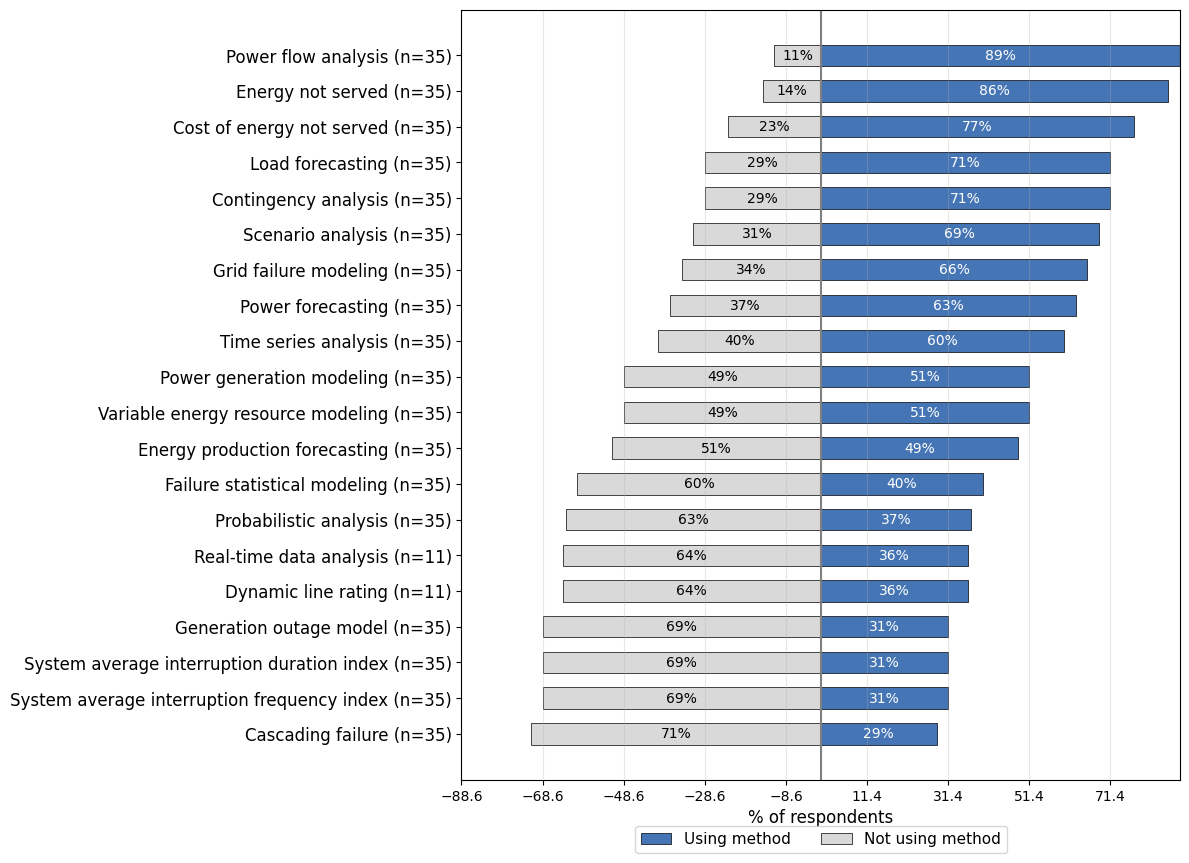

In [43]:
# Plot only total
df_diverg=plot_method_usage_diverging(df_merged_count, top_k=20, mode='total',title=False)

# Plot all three (interview, questionnaire, total)
#plot_method_usage_diverging(df_merged_count, top_k=20, mode='all')


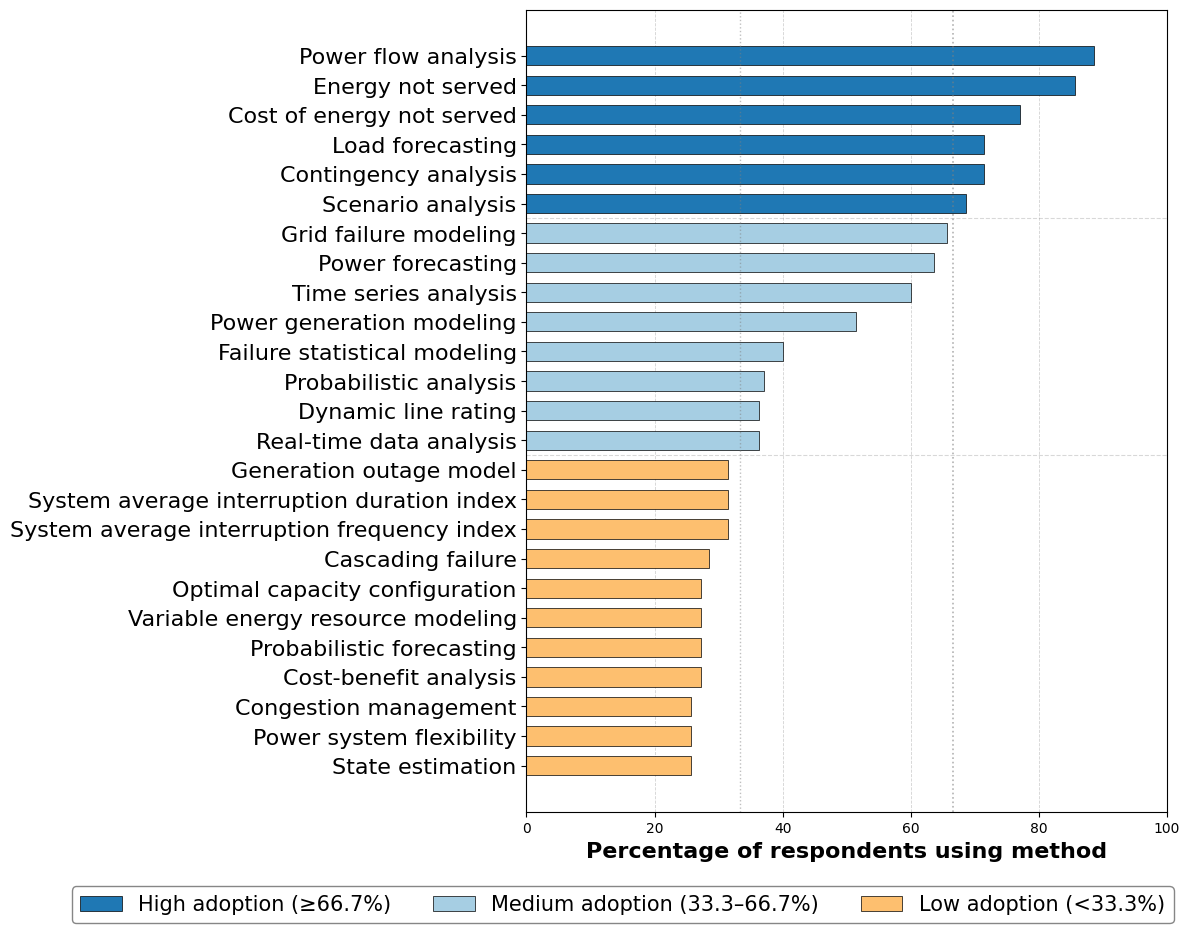

In [77]:
high_threshold=2/3*100
low_threshold=1/3*100
df_sorted = plot_method_usage_hbar(
    df_merged_count,
    top_k=25,
    mode='total',
    fontsize=16,
    title=False,
    figsize=(12, 10),
    show_sample_size=False,
    #min_sample_size=12,
    sort_by='pct_binary_t',
    high_threshold=66.67,
    low_threshold=33.33,
    show_confidence=False,  # Set True if you want error bars
    show_values=False,
    save_path='plots/method_adoption_rates.pdf'
)


#### Comparison with IEEE

In [54]:
def convert_to_binary_percentage(df_with_scores, score_column='score_q', 
                                  respondent_scores_dict=None,
                                  total_respondents=None,
                                  min_score=0,
                                  output_col_name='pct_binary'):
    """
    Convert scored data to binary percentage based on threshold
    
    Parameters:
    -----------
    df_with_scores : DataFrame
        DataFrame with method scores
    score_column : str
        Column name containing scores (for fallback)
    respondent_scores_dict : dict, optional
        Dictionary mapping method -> {respondent_id: score}
        If provided, will recalculate from raw data
    total_respondents : int, optional
        Total number of respondents (required if using respondent_scores_dict)
    min_score : float
        Minimum score threshold (exclusive). Scores > min_score count as 1.
        Default is 0 (any non-zero score counts)
    output_col_name : str
        Name for output percentage column
        
    Returns:
    --------
    DataFrame with added binary percentage column
    """
    df_result = df_with_scores.copy()
    
    if respondent_scores_dict is not None and total_respondents is not None:
        # Recalculate from raw respondent data with threshold
        binary_counts = []
        
        for idx, row in df_result.iterrows():
            method = row.get('Method', None)
            
            if method and method in respondent_scores_dict:
                # Count respondents with score > min_score
                scores = respondent_scores_dict[method]
                count_above_threshold = sum(1 for score in scores.values() if score > min_score)
                pct = (count_above_threshold / total_respondents) * 100
            else:
                pct = 0
            
            binary_counts.append(round(pct, 1))
        
        df_result[output_col_name] = binary_counts
    
    else:
        # Fallback: use existing score column with threshold
        # This is less accurate but works if raw data unavailable
        df_result[output_col_name] = (df_result[score_column] > min_score).astype(float) * 100
        print(f"Warning: Using simplified conversion from {score_column}. "
              f"For accurate counts, provide respondent_scores_dict.")
    
    return df_result


def convert_interview_to_binary_percentage(df_interview_scores, score_column='score_i',
                                           min_score=0, output_col_name='pct_binary'):
    """
    Convert interview scores to binary percentage with threshold
    
    For interview data, we typically don't have individual respondent data,
    so we estimate based on the average score:
    - If avg score > min_score, assume it was used by some percentage
    - Can apply different estimation strategies
    """
    df_result = df_interview_scores.copy()
    
    # Strategy: Assume percentage scales with score magnitude
    # score of 3 = ~100%, score of 2 = ~67%, score of 1 = ~33%
    # Adjust this heuristic based on your data
    def score_to_percentage(score, threshold):
        if score <= threshold:
            return 0.0
        # Linear mapping: (score - threshold) / (3 - threshold) * 100
        # where 3 is max score
        max_score = 3.0
        if max_score <= threshold:
            return 100.0 if score > threshold else 0.0
        return ((score - threshold) / (max_score - threshold)) * 100
    
    df_result[output_col_name] = df_result[score_column].apply(
        lambda x: round(score_to_percentage(x, min_score), 1)
    )
    
    return df_result

In [55]:
# ========================================
# PROCESS IEEE FEATURE DATA
# ========================================

def process_ieee_features(df_ieee_feature, feature_map, ieee_mapping):
    """
    Process IEEE feature data to calculate binary percentages
    Handles indicators (1-5 scale) by converting 2+ to binary 1
    """
    results = []
    total_respondents = len(df_ieee_feature)
    
    # Get all feature columns
    feature_cols = [col for col in df_ieee_feature.columns if col.startswith('feature')]
    
    for col in feature_cols:
        # Get values
        values = df_ieee_feature[col].dropna()
        
        # Determine if indicator (1-5 scale) or binary
        # Indicators have values > 1
        is_indicator = (values > 1).any()
        
        if is_indicator:
            # For indicators: count responses >= 2 as "using"
            count_using = (values >= 2).sum()
        else:
            # For binary: count 1s
            count_using = (values == 1).sum()
        
        # Calculate percentage
        pct = (count_using / total_respondents * 100) if total_respondents > 0 else 0
        
        # Try to get feature name from the data
        # This assumes the feature name might be embedded in column or needs mapping
        feature_name = col.replace('feature-', '').replace('feature', '').strip()
        
        results.append({
            'Feature_IEEE': feature_name,
            'Count_Using': count_using,
            'Total_Respondents': total_respondents,
            'pct_ieee': round(pct, 1)
        })
    
    df_results = pd.DataFrame(results)
    return df_results

def process_ieee_features_from_long_format(df_ieee_feature, ieee_mapping):
    """
    Alternative: Process IEEE data if it's in long format (one feature per row/cell)
    """
    # Count occurrences of each feature
    all_features = []
    
    for col in df_ieee_feature.columns:
        features = df_ieee_feature[col].dropna().tolist()
        all_features.extend(features)
    
    # Count unique occurrences
    from collections import Counter
    feature_counts = Counter(all_features)
    
    total_respondents = len(df_ieee_feature)
    
    results = []
    for feature, count in feature_counts.items():
        # Clean feature name
        feature_clean = feature.strip().rstrip(';')
        
        # Map to standard name
        standard_name = ieee_mapping.get(feature_clean, feature_clean)
        
        pct = (count / total_respondents * 100)
        
        results.append({
            'Feature_IEEE': feature_clean,
            'Feature_Standard': standard_name,
            'Count_Using': count,
            'Total_Respondents': total_respondents,
            'pct_ieee': round(pct, 1)
        })
    
    df_results = pd.DataFrame(results)
    return df_results

In [59]:
# ========================================
# MAP GRANULAR TO AGGREGATED METHODS
# ========================================

def create_method_aggregation_map(method_map):
    """
    Create mapping from granular feature names to aggregated method categories
    Returns: dict mapping feature_code -> list of method names
    """
    aggregation = {}
    
    for feature_code, meta in method_map.items():
        methods = meta.get('methods', [])
        if not isinstance(methods, list):
            methods = [methods]
        
        aggregation[feature_code] = methods
    
    return aggregation

def aggregate_features_to_methods(df_features, feature_ieee_map, method_aggregation):
    """
    Aggregate granular features to method categories
    
    df_features: DataFrame with columns ['Feature', 'pct_binary', ...]
    feature_ieee_map: maps feature codes to IEEE feature names
    method_aggregation: maps feature codes to method name lists
    """
    method_data = {}
    
    for idx, row in df_features.iterrows():
        feature_code = None
        
        # Find which feature code this row corresponds to
        for code, mapping in feature_ieee_map.items():
            if isinstance(mapping, dict):
                ieee_name = mapping.get('feature')
            else:
                ieee_name = mapping
            
            if ieee_name == row['Feature']:
                feature_code = code
                break
        
        if feature_code and feature_code in method_aggregation:
            methods = method_aggregation[feature_code]
            pct = row.get('pct_binary', row.get('pct_ieee', 0))
            
            for method in methods:
                if method not in method_data:
                    method_data[method] = []
                method_data[method].append(pct)
    
    # Aggregate by taking maximum percentage (since one respondent can contribute to multiple features)
    results = []
    for method, percentages in method_data.items():
        results.append({
            'Method': method,
            'pct_aggregated': round(max(percentages), 1) if percentages else 0
        })
    
    return pd.DataFrame(results)

In [48]:
# ========================================
# MERGE AND PLOT
# ========================================

def merge_three_sources(df_q_binary, df_i_binary, df_ieee, 
                        key_q='Method', key_i='Method', key_ieee='Feature_Standard'):
    """
    Merge questionnaire, interview, and IEEE data
    """
    # Merge Q and I
    df_merged = pd.merge(
        df_q_binary[[key_q, 'pct_binary']], 
        df_i_binary[[key_i, 'pct_binary']], 
        left_on=key_q, 
        right_on=key_i, 
        how='outer',
        suffixes=('_q', '_i')
    )
    
    # Clean up method column
    df_merged['Method'] = df_merged[key_q].fillna(df_merged[key_i])
    df_merged = df_merged.drop(columns=[col for col in [key_q, key_i] if col != 'Method'])
    
    # Merge with IEEE
    df_merged = pd.merge(
        df_merged,
        df_ieee[[key_ieee, 'pct_ieee']],
        left_on='Method',
        right_on=key_ieee,
        how='outer'
    )
    
    # Fill NaN with 0
    for col in ['pct_binary_q', 'pct_binary_i', 'pct_ieee']:
        if col in df_merged.columns:
            df_merged[col] = df_merged[col].fillna(0)
    
    return df_merged

def plot_three_source_comparison(df, top_k=20, save_path=None):
    """
    Plot comparison of three data sources with percentage on x-axis
    """
    # Calculate average percentage across sources
    pct_cols = [col for col in df.columns if col.startswith('pct_')]
    df['pct_average'] = df[pct_cols].mean(axis=1)
    
    # Filter and sort
    df_filtered = df[df['pct_average'] > 0].copy()
    
    if top_k is not None and len(df_filtered) > top_k:
        df_filtered = df_filtered.nlargest(top_k, 'pct_average')
        print(f'Plotting top {top_k} of {len(df[df["pct_average"] > 0])} methods with non-zero usage')
    
    df_sorted = df_filtered.sort_values('pct_average', ascending=True)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    y = np.arange(len(df_sorted))
    height = 0.25
    
    # Plot bars
    ax.barh(y - height, df_sorted.get('pct_binary_i', 0), height, 
            label='Interview (NO)', alpha=0.6, color='#6BA3C7')
    ax.barh(y, df_sorted.get('pct_binary_q', 0), height, 
            label='Questionnaire (NO)', alpha=0.6, color='#C786A9')
    ax.barh(y + height, df_sorted.get('pct_ieee', 0), height, 
            label='IEEE Survey', alpha=0.6, color='#F18F01')
    
    ax.set_yticks(y)
    ax.set_yticklabels(df_sorted['Method'].values)
    ax.set_xlabel('% of Respondents', fontsize=12)
    ax.set_ylabel('Method', fontsize=12)
    
    title = 'Comparison of Method Usage Across Three Sources'
    if top_k:
        title += f'\n(Top {top_k} methods)'
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, 105)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
    
    plt.show()

In [60]:
df_q_methods, method_scores_dict = count_method_usage_with_scores(
    df_q, 
    FEATURE_IEEE_MAP, 
    binary=True,
    #min_score=1  # Only count scores of 2 or 3
)

NameError: name 'count_method_usage_with_scores' is not defined

In [61]:
# ========================================
# IMPLEMENTATION
# ========================================


# 2. Process IEEE data - it's already processed!
df_ieee_processed = df_ieee_feature.copy()

# Rename columns to match your schema
df_ieee_processed = df_ieee_processed.rename(columns={
    'feature_name': 'Feature_IEEE',
    'feature_use_percentage': 'pct_ieee'
})

# Map IEEE feature names to your standard names
df_ieee_processed['Feature_Standard'] = df_ieee_processed['Feature_IEEE'].map(
    lambda x: IEEE_FEATURE_MAPPING.get(x, x)
)

# Clean up any NaN values
df_ieee_processed['pct_ieee'] = df_ieee_processed['pct_ieee'].fillna(0)
df_ieee_processed['pct_ieee'] = df_ieee_processed['pct_ieee']*100

print(f"Loaded {len(df_ieee_processed)} IEEE features")
print(df_ieee_processed.head())# 3. Create both granular and aggregated views

# GRANULAR VIEW: Direct feature-to-feature comparison
df_comparison_granular = merge_three_sources(
    df_q_binary[['Method', 'pct_binary']],
    df_i_binary[['Method', 'pct_binary']],
    df_ieee_processed,
    key_q='Method',
    key_i='Method',
    key_ieee='Feature_Standard'
)

# 4. Plot both views
plot_three_source_comparison(
    df_comparison_granular,
    top_k=20,
    save_path='plots/method_comparison_granular_pct.pdf'
)


# 5. Save results
df_comparison_granular.to_csv('data/method_comparison_granular_pct.csv', index=False)


print("\nGranular comparison summary:")
print(df_comparison_granular.describe())


Loaded 20 IEEE features
             Feature_IEEE  feature_use_count  pct_ieee        Feature_Standard
0             Gen outages               31.0      62.0             Gen outages
1              Tx outages               22.0      44.0              Tx outages
2  Monte Carlo simulation               27.0      54.0  Monte Carlo simulation
3     Hourly VER modeling               16.0      32.0     Hourly VER modeling
4    Wx-dependent outages               11.0      22.0    Wx-dependent outages


NameError: name 'merge_three_sources' is not defined

#### Method with rating

In [ ]:
print(df_i_method_scores.columns)

In [51]:
per_method, per_resp = count_method_opportunities(df_q, METHOD_MAP,PARENT_MAP)


#print(per_resp.head(30)[["Method", "respondent", "chosen", "opportunities", "fraction"]])

df_q_methods_classified, per_resp_classified = summarize_usage_by_method(
    per_resp,
    min_2=1,          # e.g. at least 3 opportunities to be counted as class 2/3
    min_3=2,
    frequent_limit=0.67,
    sporadic_limit=0.33,
    never_limit=0.1,
)

In [52]:
# ========================================
# 4. RUN ANALYSIS
# ========================================

# Run questionnaire analysis
df_q_methods, method_scores_dict = count_method_usage_with_scores(df_q, METHOD_MAP)



# Run interview analysis
df_i_method_scores = calc_method_usage(df_i)
df_i_method_scores_count = calc_method_usage(df_i,binary=True)
df_i_desires_scores=calc_desire_usage(df_i)
df_i_desires_count=calc_desire_usage(df_i,binary=True)

# Merge results
df_merged = merge_method_results(df_q_methods_classified, df_i_method_scores)

#Save to CSV
df_merged.to_csv('data/method_comparison_results.csv', index=False)

print(f"Score ranges: Q={df_merged['score_q'].min():.2f}-{df_merged['score_q'].max():.2f}, "
      f"I={df_merged['score_i'].min():.2f}-{df_merged['score_i'].max():.2f}, "
      f"Total={df_merged['Average_score'].min():.2f}-{df_merged['Average_score'].max():.2f}")



TypeError: 'bool' object is not callable

In [53]:
# ========================================
# USAGE: Convert Q and I data with threshold
# ========================================

# For Questionnaire data - use raw respondent scores for accurate binary conversion
df_q_binary = convert_to_binary_percentage(
    df_q_methods,
    score_column='score_q',
    respondent_scores_dict=method_scores_dict,  # From count_method_usage_with_scores
    total_respondents=len(df_q),
    min_score=0,  # Count any usage (score > 0)
    output_col_name='pct_binary'
)

# For Interview data - estimate from average scores
df_i_binary = convert_interview_to_binary_percentage(
    df_i_method_scores,
    score_column='score_i',
    min_score=0,  # Count any usage
    output_col_name='pct_binary'
)

# If you want stricter threshold (e.g., only count "significant" usage):
# df_q_binary_strict = convert_to_binary_percentage(
#     df_q_methods,
#     respondent_scores_dict=method_scores_dict,
#     total_respondents=len(df_q),
#     min_score=1,  # Only count score > 1 (scores of 2 or 3)
#     output_col_name='pct_binary'
# )

print(f"Questionnaire binary conversion: {df_q_binary['pct_binary'].describe()}")
print(f"Interview binary conversion: {df_i_binary['pct_binary'].describe()}")

NameError: name 'df_q_methods' is not defined

In [54]:
dupe_counts = df_merged['Method'].value_counts()
print(dupe_counts[dupe_counts > 1])

NameError: name 'df_merged' is not defined

In [55]:
print(df_ieee_methods['method_name'].tolist())

['Gen outages', 'Tx outages', 'Monte Carlo simulation', 'Hourly VER modeling', 'Wx-dependent outages', 'Short-duration storage', 'Emergency operating', 'Security constraints', 'Long-duration storage', 'Other depend. outages', 'Enumeration', 'Tx congestion mgmt', 'Load or gen isolation', 'AC OPF', 'Substation-orig outages', 'Cascading collapse', 'Market impacts', 'DC OPF', 'Loss-of-Load Probability (LOLP);', 'Expected Unserved Energy (EUE);', 'Loss-of-Load Hours (LOLH);', 'Loss-of-Load Expectation (LOLE);', 'Loss-of-Load Events (LOLEV);']


In [56]:
# ========================================
# 5. PLOT COMPARISON
# ========================================

def plot_method_comparison(df,top_k=None, interview_col='score_i', 
                          questionnaire_col='score_q',
                          total_col='Average_score', 
                          method_col='Method',
                          title=True,
                          figsize=(12,8),
                          fontsize=12,
                          save_path=None):
    """
    Plot method comparison with scores in 1-3 range
    """
    
    # Filter out methods with zero total scores
    df_filtered = df[df[total_col] > 0].copy()
    if top_k is not None:
        total_methods=len(df_filtered)
        df_filtered = df_filtered.nlargest(top_k,total_col)
        print(f'Plotting {len(df_filtered)} of {total_methods} with non-zero score')
    # Sort by total score (ascending so highest is at top)
    df_sorted = df_filtered.sort_values(by=total_col, ascending=True)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    y = range(len(df_sorted))
    height = 0.25
    
    y_labels = df_sorted[method_col].values
    
    # Plot three bars for each method
    ax.barh([i - height for i in y], df_sorted[interview_col], height, 
            label='Interview', alpha=0.4, color='#6BA3C7', edgecolor='none')
    ax.barh(y, df_sorted[questionnaire_col], height, 
            label='Questionnaire', alpha=0.4, color='#C786A9', edgecolor='none')
    ax.barh([i + height for i in y], df_sorted[total_col], height, 
            label='Average', alpha=1.0, color='#F18F01', edgecolor='#C97000', linewidth=1.5)
    if title:
        title='Comparison of Method Usage Scores from Questionnaire and Interviews'
        if top_k is not None: title=title+f'\n (Showing top {top_k} methods)'
    ax.set_ylabel('', fontsize=fontsize)
    ax.set_xlabel('Average Score', fontsize=fontsize)
    if title: ax.set_title(title,fontsize=fontsize, fontweight='bold')
    ax.set_yticks(y)
    #capitalize first letter of y_labels
    y_labels = [label.capitalize() for label in y_labels]
    ax.set_yticklabels(y_labels, fontsize=fontsize)
    ax.set_xticklabels(ax.get_xticks(), fontsize=fontsize)
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(axis='x', alpha=0.3)
    
    # Set x-axis limits to show 1-3 range clearly
    ax.set_xlim(0, 3.2)
    
    plt.tight_layout()
    
    if save_path is not None:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
    
    plt.show()

In [57]:
def plot_method_score_comparison_stacked(
        df,
        top_k=None,
        method_col='Method',
        total_col='Average_score',
        figsize=(12, 8),
        fontsize=12,
        title=True,
        weights=None,
        save_path=None,
        mode='total'  # 'total' (default) or 'all'
    ):
    """
    Stacked barh comparison of score distributions (0–3) for
    Interview, Questionnaire, and/or Total per method.

    mode:
      - 'total': plot only Total bar per method (with % labels)
      - 'all'  : plot Interview, Questionnaire, and Total
    """

    # Filter out methods with zero total score
    df_filtered = df[df[total_col] > 0].copy()
    if df_filtered.empty:
        print("No methods with non-zero total score.")
        return



    # Sort so highest total score is at top
    # For a horizontal bar plot, ascending=True means highest at top of the axis.
        # Start from filtered (unsorted)
    df_sorted = df_filtered.copy()

    score_levels = [3, 2, 1, 0]

    # Questionnaire
    df_sorted['q_total'] = df_sorted[[f'q_n_{s}' for s in score_levels]].sum(axis=1)
    for s in score_levels:
        df_sorted[f'q_pct_{s}'] = (
            df_sorted[f'q_n_{s}'] /
            df_sorted['q_total'].where(df_sorted['q_total'] > 0, 1)
        ) * 100.0

    # Interview
    df_sorted['i_total'] = df_sorted[[f'i_n_{s}' for s in score_levels]].sum(axis=1)
    for s in score_levels:
        df_sorted[f'i_pct_{s}'] = (
            df_sorted[f'i_n_{s}'] /
            df_sorted['i_total'].where(df_sorted['i_total'] > 0, 1)
        ) * 100.0

    # Combined (Total)
    for s in score_levels:
        df_sorted[f't_n_{s}'] = df_sorted[f'q_n_{s}'] + df_sorted[f'i_n_{s}']
    df_sorted['t_total'] = df_sorted[[f't_n_{s}' for s in score_levels]].sum(axis=1)
    for s in score_levels:
        df_sorted[f't_pct_{s}'] = (
            df_sorted[f't_n_{s}'] /
            df_sorted['t_total'].where(df_sorted['t_total'] > 0, 1)
        ) * 100.0

    # sorting and top_k filtering
    if weights is None:
        df_sorted['sort_col']=df[total_col]
    else:
        df_sorted['sort_col'] = sum(w * df_sorted[col] for col, w in weights.items())

    df_sorted = df_sorted.sort_values(by='sort_col', ascending=True)
    # Select top_k by total average if requested
    if top_k is not None:
        df_sorted = df_sorted.nlargest(top_k, 'sort_col')
    
    #sort by t_pct_3 so methods with most "core" usage are at top
    df_sorted = df_sorted.sort_values(by='sort_col', ascending=True)

    
    # Positions based on this sorted order
    y_base = np.arange(len(df_sorted))

    if mode == 'all':
        bar_height = 0.25
        offsets = {'i': -bar_height, 'q': 0.0, 't': +bar_height}
    else:  # 'total'
        bar_height = 0.60
        offsets = {'t': 0.0}  # single bar centered

    fig, ax = plt.subplots(figsize=figsize)

    # Palettes
    colors_i = {3: '#2B5C7F', 2: '#4F88AB', 1: '#8FB7D0', 0: '#D3E6F2'}
    colors_q = {3: '#8D436A', 2: '#A6668C', 1: '#D0A0BC', 0: '#F0D9E7'}
    colors_t = {3: '#B25F00', 2: '#F18F01', 1: '#F6B955', 0: '#FBE4B8'}

    def plot_stacked(prefix, label, offset):
        if prefix == 'i':
            cmap = colors_i
        elif prefix == 'q':
            cmap = colors_q
        else:
            cmap = colors_t

        left = np.zeros(len(df_sorted))
        bars_by_score = {}
        for s in score_levels:
            vals = df_sorted[f'{prefix}_pct_{s}'].values
            bars = ax.barh(
                y_base + offset,
                vals,
                left=left,
                height=bar_height,
                color=cmap[s],
                edgecolor='black'
            )
            left = left + vals
            bars_by_score[s] = bars

        # Invisible bar for series legend (used only in mode='all')
        ax.barh([], [], color=cmap[3], label=label)
        return bars_by_score

    # Plot bars
    bars_total = None
    if mode == 'all':
        plot_stacked('i', 'Interview', offsets['i'])
        plot_stacked('q', 'Questionnaire', offsets['q'])
        bars_total = plot_stacked('t', 'Total', offsets['t'])
    else:  # 'total'
        bars_total = plot_stacked('t', 'Total', offsets['t'])

    # Y labels
    y_labels = [str(m).capitalize() for m in df_sorted[method_col].values]
    ax.set_yticks(y_base)
    ax.set_yticklabels(y_labels, fontsize=fontsize)

    # X axis
    ax.set_xlabel('% of responses', fontsize=fontsize)
    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 101, 20))
    plt.setp(ax.get_xticklabels(), fontsize=fontsize)

    # Percentage labels when only Total is shown
    if mode == 'total':
        for s in score_levels:
            bars = bars_total[s]
            for bar, pct in zip(bars, df_sorted[f't_pct_{s}'].values):
                if pct <= 0:
                    continue
                x = bar.get_x() + bar.get_width() / 2.0
                y = bar.get_y() + bar.get_height() / 2.0
                ax.text(
                    x, y,
                    f'{pct:.0f}%',
                    ha='center', va='center',
                    fontsize=fontsize-2,
                    color='black'
                )

    # Title
    if title:
        if mode == 'all':
            t = 'Score distribution per method\n(Interview, Questionnaire, and Total)'
        else:
            t = 'Score distribution per method (Total responses)'
        if top_k is not None:
            t += f'\n(Showing top {top_k} methods by Average_score)'
        ax.set_title(t, fontsize=fontsize, fontweight='bold')

    # Legends
    if mode == 'all':
        # Series legend + hint
        series_patches = [
            Patch(facecolor=colors_i[3], label='Interview'),
            Patch(facecolor=colors_q[3], label='Questionnaire'),
            Patch(facecolor=colors_t[3], label='Total'),
        ]
        score_hint_patches = [
            Patch(facecolor='none', edgecolor='black',
                  label='Darker tone indicates higher score')
        ]
        legend_handles = series_patches + score_hint_patches
        ncol = 3
    else:  # 'total'
        # One entry per score color with semantic labels
        legend_handles = [
            Patch(facecolor=colors_t[3], label='3 = Used as core in the analysis'),
            Patch(facecolor=colors_t[2], label='2 = Used sporadically as standardized method'),
            Patch(facecolor=colors_t[1], label='1 = Known but not used or used only indirectly'),
            Patch(facecolor=colors_t[0], label='0 = Not known/mentioned'),
        ]
        ncol = 2

    # Legend below
    box = ax.get_position()
    ax.set_position([box.x0, box.y0 + box.height * 0.18,
                     box.width, box.height * 0.82])

    ax.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.35, -0.08),
        ncol=ncol,
        fontsize=fontsize-2,
        frameon=True
    )

    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        if not str(save_path).endswith('.pdf'):
            save_path = str(save_path) + '.pdf'
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)

    plt.show()

    return df_sorted

def plot_method_score_comparison_diverging(
        df,
        top_k=None,
        method_col='Method',
        total_col='Average_score',
        figsize=(12, 8),
        fontsize=12,
        title=True,
        weights=None,
        save_path=None,
        mode='total'  # 'total' (default) or 'all'
    ):
    """
    Stacked barh comparison of score distributions (0–3) for
    Interview, Questionnaire, and/or Total per method.

    mode:
      - 'total': plot only Total bar per method (with % labels)
      - 'all'  : plot Interview, Questionnaire, and Total
    """

    # Filter out methods with zero total score
    df_filtered = df[df[total_col] > 0].copy()
    if df_filtered.empty:
        print("No methods with non-zero total score.")
        return



    # Sort so highest total score is at top
    # For a horizontal bar plot, ascending=True means highest at top of the axis.
        # Start from filtered (unsorted)
    df_sorted = df_filtered.copy()

    score_levels = [3, 2, 1, 0]

    # Questionnaire
    df_sorted['q_total'] = df_sorted[[f'q_n_{s}' for s in score_levels]].sum(axis=1)
    for s in score_levels:
        df_sorted[f'q_pct_{s}'] = (
            df_sorted[f'q_n_{s}'] /
            df_sorted['q_total'].where(df_sorted['q_total'] > 0, 1)
        ) * 100.0

    # Interview
    df_sorted['i_total'] = df_sorted[[f'i_n_{s}' for s in score_levels]].sum(axis=1)
    for s in score_levels:
        df_sorted[f'i_pct_{s}'] = (
            df_sorted[f'i_n_{s}'] /
            df_sorted['i_total'].where(df_sorted['i_total'] > 0, 1)
        ) * 100.0

    # Combined (Total)
    for s in score_levels:
        df_sorted[f't_n_{s}'] = df_sorted[f'q_n_{s}'] + df_sorted[f'i_n_{s}']
    df_sorted['t_total'] = df_sorted[[f't_n_{s}' for s in score_levels]].sum(axis=1)
    for s in score_levels:
        df_sorted[f't_pct_{s}'] = (
            df_sorted[f't_n_{s}'] /
            df_sorted['t_total'].where(df_sorted['t_total'] > 0, 1)
        ) * 100.0

    # sorting and top_k filtering
    if weights is None:
        df_sorted['sort_col']=df[total_col]
    else:
        df_sorted['sort_col'] = sum(w * df_sorted[col] for col, w in weights.items())

    df_sorted = df_sorted.sort_values(by='sort_col', ascending=True)
    # Select top_k by total average if requested
    if top_k is not None:
        df_sorted = df_sorted.nlargest(top_k, 'sort_col')
    
    #sort by t_pct_3 so methods with most "core" usage are at top
    df_sorted = df_sorted.sort_values(by='sort_col', ascending=True)

    
        # Positions based on this sorted order
    y_base = np.arange(len(df_sorted))

    if mode == 'all':
        bar_height = 0.25
        offsets = {'i': -bar_height, 'q': 0.0, 't': +bar_height}
    else:  # 'total'
        bar_height = 0.60
        offsets = {'t': 0.0}

    fig, ax = plt.subplots(figsize=figsize)

    colors_t = {
        3: '#2c7bb6',  # Strong blue (high adoption)
        2: '#abd9e9',  # Light blue (moderate adoption)
        1: '#fee090',  # Light yellow-orange (low adoption)
        0: '#B25F00'   # Red (no adoption/not known)
    }
    
    # Keep interview/questionnaire colors for 'all' mode
    colors_i = {3: '#B25F00', 2: '#F18F01', 1: '#F6B955', 0: '#FBE4B8'}
    colors_q = {3: '#8D436A', 2: '#A6668C', 1: '#D0A0BC', 0: '#F0D9E7'}
    

    #colors_i = {3: '#B25F00', 2: '#F18F01', 1: '#F6B955', 0: '#FBE4B8'}
    #colors_t = {3: "#419C05", 2: '#4F88AB', 1: '#8FB7D0', 0: '#F6B955'}
    #colors_q = {3: '#8D436A', 2: '#A6668C', 1: '#D0A0BC', 0: '#F0D9E7'}

    score_levels = [3, 2, 1, 0]

    def plot_stacked(prefix, label, offset, diverging=False):
        if prefix == 'i':
            cmap = colors_i
        elif prefix == 'q':
            cmap = colors_q
        else:
            cmap = colors_t

        bars_by_score = {}

        if not diverging:
            # original: all stacked to the right (0–100)
            left = np.zeros(len(df_sorted))
            for s in score_levels:
                vals = df_sorted[f'{prefix}_pct_{s}'].values
                bars = ax.barh(
                    y_base + offset,
                    vals,
                    left=left,
                    height=bar_height,
                    color=cmap[s],
                    edgecolor='black'
                )
                left = left + vals
                bars_by_score[s] = bars
        else:
            # diverging:
            # 0 goes to the left (negative), 1–3 to the right (positive)
            zeros = df_sorted[f'{prefix}_pct_0'].values
            bars0 = ax.barh(
                y_base + offset,
                -zeros,               # negative width
                left=0.0,
                height=bar_height,
                color=cmap[0],
                edgecolor='black'
            )
            bars_by_score[0] = bars0

            left = np.zeros(len(df_sorted))
            for s in [1, 2, 3]:
                vals = df_sorted[f'{prefix}_pct_{s}'].values
                bars = ax.barh(
                    y_base + offset,
                    vals,
                    left=left,
                    height=bar_height,
                    color=cmap[s],
                    edgecolor='black'
                )
                left = left + vals
                bars_by_score[s] = bars

        # invisible bar for series legend (only used in mode='all')
        if not diverging:
            ax.barh([], [], color=cmap[3], label=label)

        return bars_by_score

    # Plot bars
    bars_total = None
    if mode == 'all':
        plot_stacked('i', 'Interview', offsets['i'], diverging=True)
        plot_stacked('q', 'Questionnaire', offsets['q'], diverging=True)
        bars_total = plot_stacked('t', 'Total', offsets['t'], diverging=True)
    else:  # 'total' with diverging layout
        bars_total = plot_stacked('t', 'Total', offsets['t'], diverging=True)

    # Y labels
    # Y labels WITH SAMPLE SIZES
    y_labels = []
    for idx, row in df_sorted.iterrows():
        method_name = str(row[method_col]).capitalize()
        
        if mode == 'all':
            n_q = int(row['q_total'])
            n_i = int(row['i_total'])
            n_t = int(row['t_total'])
            # Show all three sample sizes for 'all' mode
            y_labels.append(f'{method_name} (n={n_t}: Q={n_q}, I={n_i})')
        else:
            # Show only total sample size for 'total' mode
            n_t = int(row['t_total'])
            y_labels.append(f'{method_name} (n={n_t})')
    
    ax.set_yticks(y_base)
    ax.set_yticklabels(y_labels, fontsize=fontsize)
    # X axis (symmetric around 0, because left = “0 share”)
    ax.set_xlabel('% of responses', fontsize=fontsize)
    max_right = df_sorted[['t_pct_1', 't_pct_2', 't_pct_3']].sum(axis=1).max()
    max_left = df_sorted['t_pct_0'].max()
    bound = max(max_right, max_left)
    bound = max(bound, 50)  # at least ±50 for readability
    ax.set_xlim(-bound, bound)
    ax.set_xticks(np.arange(-bound, bound + 1, 20))
    ax.axvline(0, color='gray', lw=1)

    # Percentage labels for diverging Total
    min_pct=6
    if mode == 'total':
        # score 0 labels (left side)
        for bar, pct in zip(bars_total[0], df_sorted['t_pct_0'].values):
            if pct <= 0 or pct< min_pct:
                continue
            x = bar.get_x() + bar.get_width() / 2.0
            y = bar.get_y() + bar.get_height() / 2.0
            ax.text(
                x, y, f'{pct:.0f}%',
                ha='center', va='center',
                fontsize=fontsize-2, color='white'
            )
        # scores 1,2,3 labels (right side)
        for s in [1, 2]:
            bars = bars_total[s]
            for bar, pct in zip(bars, df_sorted[f't_pct_{s}'].values):
                if pct <= 0 or pct< min_pct:
                    continue
                x = bar.get_x() + bar.get_width() / 2.0
                y = bar.get_y() + bar.get_height() / 2.0
                ax.text(
                    x, y, f'{pct:.0f}%',
                    ha='center', va='center',
                    fontsize=fontsize-2
                )
        for s in [3]:
            bars = bars_total[s]
            for bar, pct in zip(bars, df_sorted[f't_pct_{s}'].values):
                if pct <= 0 or pct< min_pct:
                    continue
                x = bar.get_x() + bar.get_width() / 2.0
                y = bar.get_y() + bar.get_height() / 2.0
                ax.text(
                    x, y, f'{pct:.0f}%',
                    ha='center', va='center',
                    fontsize=fontsize-2,color='white'
                )

    # Title
    if title:
        if mode == 'all':
            t = 'Score distribution per method\n(Interview, Questionnaire, and Total)'
        else:
            t = 'Score distribution per method (Total responses, diverging)'
        if top_k is not None:
            t += f'\n(Showing top {top_k} methods by {total_col})'
        ax.set_title(t, fontsize=fontsize, fontweight='bold')

    # IMPROVED LEGEND - more concise and better ordered
    if mode == 'all':
        series_patches = [
            Patch(facecolor=colors_i[3], label='Interview'),
            Patch(facecolor=colors_q[3], label='Questionnaire'),
            Patch(facecolor=colors_t[3], label='Total'),
        ]
        score_hint_patches = [
            Patch(facecolor='none', edgecolor='black',
                  label='Darker tone indicates higher score')
        ]
        legend_handles = series_patches + score_hint_patches
        ncol = 3
    else:
        # Reorder legend to match visual importance (3→2→1→0)
        legend_handles = [
            Patch(facecolor=colors_t[3], edgecolor='black', linewidth=0.5,
                  label='3 = Used frequently'),
            Patch(facecolor=colors_t[2], edgecolor='black', linewidth=0.5,
                  label='2 = Used sporadically as standardized method'),
            Patch(facecolor=colors_t[1], edgecolor='black', linewidth=0.5,
                  label='1 = Used rarely or indirectly'),
            Patch(facecolor=colors_t[0], edgecolor='black', linewidth=0.5,
                  label='0 = Not known/relevant/mentioned'),
        ]
        ncol = 2

    box = ax.get_position()
    ax.set_position([box.x0, box.y0 + box.height * 0.18,
                     box.width, box.height * 0.82])

    ax.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.35, -0.08),
        ncol=ncol,
        fontsize=fontsize-2,
        frameon=True
    )
    xmin=df_sorted['t_pct_0'].max()
    ax.set_xlim(-xmin-5,100)
    ax.grid(axis='x', alpha=0.3)
    #ax.grid(axis='y', alpha=0.1, color='#1ccccc' )
    plt.tight_layout()

    if save_path is not None:
        if not str(save_path).endswith('.pdf'):
            save_path = str(save_path) + '.pdf'
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)

    plt.show()
    return df_sorted


In [58]:
# Plot the comparison
# Usage
plot_method_comparison(
    df_merged, 
    top_k=30,
    figsize=(12,10),
    method_col='Method',
    interview_col='score_i',
    questionnaire_col='score_q',
    total_col='Average_score',
    title=False,
    fontsize=14,
    save_path='plots/method_comparison_1-3_horizontal.pdf'
)


NameError: name 'df_merged' is not defined

In [59]:
df_sorted=plot_method_score_comparison_stacked(
    df_merged,
    total_col='Average_score',
    top_k=30,
    mode='total',
    fontsize=14,
    title=False,
    figsize=(12,10),
    #weights = {'t_pct_3': 3, 't_pct_2': 2, 't_pct_1':1},
    save_path='plots/stacked_bar_method_usage_scores.pdf'
)


NameError: name 'df_merged' is not defined

In [ ]:
df_sorted=plot_method_score_comparison_diverging(
    df_merged,
    total_col='Average_score',
    top_k=20,
    mode= 'total',#'all',#
    fontsize=14,
    title=False,
    figsize=(12,8),
    weights = {'t_pct_3': 1, 't_pct_2': 1, 't_pct_1':1},
    save_path='plots/diverging_bar_method_usage_scores.pdf'
)

### Barrier comparison plot

In [69]:
# Barrier mappings for questionnaire
BARRIERS_MAPPINGS = {
    'software_barrieres.1': 'Results Difficult to Interpret',
    'software_barrieres.2': 'Data Quality Issues',
    'software_barrieres.3': 'Internal Guidelines Not Adapted',
    'software_barrieres.4': 'Time-consuming/Complicated',
    'software_barrieres.5': 'Insufficient Tool Support',
    'software_barrieres.6': 'Insufficient Knowledge',
    'software_barrieres.7': 'Other Barriers',
    'indicators_barriers.1': 'Results Difficult to Interpret',
    'indicators_barriers.2': 'Data Quality Issues',
    'indicators_barriers.3': 'Internal Guidelines Not Adapted',
    'indicators_barriers.4': 'Time-consuming/Complicated',
    'indicators_barriers.5': 'Insufficient Tool Support',
    'indicators_barriers.6': 'Insufficient Knowledge',
    'indicators_barriers.7': 'Other Barriers'
}

In [83]:
# process barries data
def aggregate_questionnaire_barriers(df_q, barriers_mappings):
    """Aggregate questionnaire barriers (both software and indicators) by barrier type"""
    # Find all barrier columns
    barrier_cols = [col for col in df_q.columns 
                   if ('software_barrieres' in col.lower() or 'indicators_barriers' in col.lower())
                   and not col.lower().endswith('desc')]
    
    # Group by barrier name
    barrier_data = {}
    
    for col in barrier_cols:
        barrier_name = barriers_mappings.get(col, col)
        
        # Count ratings (0-5 scale)
        counts = df_q[col].value_counts(bins=[0, 0.5, 1.5, 2.5, 3.5, 4.5, 5.0], sort=False)
        
        if barrier_name not in barrier_data:
            barrier_data[barrier_name] = np.zeros(6)
        
        barrier_data[barrier_name] += counts.values
    
    # Convert to percentages
    barrier_percentages = {}
    for barrier_name, counts in barrier_data.items():
        total = counts.sum()
        if total > 0:
            barrier_percentages[barrier_name] = (counts / total * 100)
        else:
            barrier_percentages[barrier_name] = np.zeros(6)
    
    return barrier_percentages


def process_interview_barriers(df_i):
    """Process interview barriers (general barriers only)"""
    barrier_cols = [col for col in df_i.columns 
                   if col.startswith("Barriers-") 
                   and not col.lower().endswith('desc')]
    
    barrier_labels = [col.replace("Barriers-", "") for col in barrier_cols]
    
    barrier_data = {}
    for col, label in zip(barrier_cols, barrier_labels):
        counts = df_i[col].value_counts(bins=[0, 0.5, 1.5, 2.5, 3.5, 4.5, 5.0], sort=False)
        total = counts.sum()
        if total > 0:
            barrier_data[label] = (counts / total * 100).values
        else:
            barrier_data[label] = np.zeros(6)
    
    return barrier_data


def merge_barrier_data(q_barriers, i_barriers):
    """Merge questionnaire and interview barrier data, averaging where both exist"""
    all_barriers = set(q_barriers.keys()) | set(i_barriers.keys())
    
    merged_data = []
    for barrier in all_barriers:
        q_data = q_barriers.get(barrier, np.zeros(6))
        i_data = i_barriers.get(barrier, np.zeros(6))
        
        # Calculate average where both exist, otherwise use available data
        if barrier in q_barriers and barrier in i_barriers:
            avg_data = (q_data + i_data) / 2
            source = 'Both'
        elif barrier in q_barriers:
            avg_data = q_data
            source = 'Questionnaire'
        else:
            avg_data = i_data
            source = 'Interview'
        
        merged_data.append({
            'barrier': barrier,
            'data': avg_data,
            'q_data': q_data,
            'i_data': i_data,
            'source': source
        })
    
    return merged_data


In [80]:
def plot_combined_barriers(merged_data, mode='all', save_path=None, title=True, fontsize=12, figsize=(12, 8)):
    """Create combined barrier plot.

    mode:
      - 'all'      : combined (top) + questionnaire + interview subplots
      - 'combined' : only combined (single full-width plot)
    """
    from matplotlib.gridspec import GridSpec

    # Extract data
    barriers = [item['barrier'] for item in merged_data]

    # Calculate severity arrays for each source
    q_arrays   = {'not_relevant': [], 'not_barrier': [], 'small': [], 'moderate': [], 'critical': []}
    i_arrays   = {'not_relevant': [], 'not_barrier': [], 'small': [], 'moderate': [], 'critical': []}
    avg_arrays = {'not_relevant': [], 'not_barrier': [], 'small': [], 'moderate': [], 'critical': []}

    for item in merged_data:
        # Questionnaire
        q_data = item['q_data']
        q_arrays['not_relevant'].append(q_data[0])
        q_arrays['not_barrier'].append(q_data[1])
        q_arrays['small'].append(q_data[2])
        q_arrays['moderate'].append(q_data[3])
        q_arrays['critical'].append(q_data[4] + q_data[5])

        # Interview
        i_data = item['i_data']
        i_arrays['not_relevant'].append(i_data[0])
        i_arrays['not_barrier'].append(i_data[1])
        i_arrays['small'].append(i_data[2])
        i_arrays['moderate'].append(i_data[3])
        i_arrays['critical'].append(i_data[4] + i_data[5])

        # Combined / average
        avg_data = item['data']
        avg_arrays['not_relevant'].append(avg_data[0])
        avg_arrays['not_barrier'].append(avg_data[1])
        avg_arrays['small'].append(avg_data[2])
        avg_arrays['moderate'].append(avg_data[3])
        avg_arrays['critical'].append(avg_data[4] + avg_data[5])

    # Convert to numpy arrays
    for key in q_arrays:
        q_arrays[key]   = np.array(q_arrays[key])
        i_arrays[key]   = np.array(i_arrays[key])
        avg_arrays[key] = np.array(avg_arrays[key])

    # Severity scores for sorting (use combined)
    severity_scores = (
        4 *avg_arrays['critical']+
        3 * avg_arrays['moderate'] +
        2 * avg_arrays['small']
    )

    # Find "Other" barriers and sort
    other_idx = None
    for i, barrier in enumerate(barriers):
        if 'other' in barrier.lower():
            other_idx = i
            break

    indices = [i for i in range(len(barriers)) if i != other_idx]
    sorted_indices = sorted(indices, key=lambda i: severity_scores[i], reverse=False)
    if other_idx is not None:
        sorted_indices.insert(0, other_idx)

    ordered_barriers = [barriers[i] for i in sorted_indices]
    y_pos = np.arange(len(ordered_barriers))

    # Figure layout depends on mode
    if mode == 'combined':
        fig, ax_combined = plt.subplots(figsize=figsize)
        ax_q = ax_i = None
    else:  # mode == 'all'
        fig = plt.figure(figsize=(16, 14))
        gs = GridSpec(2, 2, figure=fig, height_ratios=[2, 1], hspace=0.35, wspace=0.4)
        ax_combined = fig.add_subplot(gs[0, :])
        ax_q        = fig.add_subplot(gs[1, 0])
        ax_i        = fig.add_subplot(gs[1, 1])

    # Combined (always plotted)
    plot_barrier_diverging(
        ax_combined, y_pos, avg_arrays, sorted_indices, ordered_barriers,
        title='Combined Barrier Severity Distribution' if title else None,
        show_ylabel=True, highlight=True, fontsize=fontsize
    )

    # Questionnaire and Interview only in 'all' mode
    if mode == 'all':
        plot_barrier_diverging(
            ax_q, y_pos, q_arrays, sorted_indices, ordered_barriers,
            title='Questionnaire Barriers' if title else None,
            show_ylabel=True, highlight=False, fontsize=fontsize-2
        )

        plot_barrier_diverging(
            ax_i, y_pos, i_arrays, sorted_indices, ordered_barriers,
            title='Interview Barriers' if title else None,
            show_ylabel=False, highlight=False, fontsize=fontsize-2
        )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)

    plt.show()
    return fig


def plot_barrier_diverging(ax, y_pos, arrays, sorted_indices, labels, 
                          show_ylabel=True, highlight=False,title=None,fontsize=12):
    """Helper function to plot diverging barrier chart with percentage labels for all categories"""
    # Reorder arrays
    not_relevant = np.array([arrays['not_relevant'][i] for i in sorted_indices])
    not_barrier = np.array([arrays['not_barrier'][i] for i in sorted_indices])
    small = np.array([arrays['small'][i] for i in sorted_indices])
    moderate = np.array([arrays['moderate'][i] for i in sorted_indices])
    critical = np.array([arrays['critical'][i] for i in sorted_indices])
    
    # Set alpha based on highlight
    alpha = 1.0 if highlight else 0.4
    edge_width = 1.2 if highlight else 0
    edge_color = '#666' if highlight else 'none'


    # Plot bars
    ax.barh(y_pos, not_relevant, left=0, 
            color='#8FB7D0', alpha=alpha, edgecolor=edge_color, linewidth=edge_width, #'#2B5C7F' ,
            label='Not relevant/No opinion (0)')
    ax.barh(y_pos, not_barrier,left =not_relevant, color='#2c7bb6', alpha=alpha, #'#FBE4B8'
            edgecolor=edge_color, linewidth=edge_width,
            label='Not a barrier (1)')
    ax.barh(y_pos, -small, left=0, color='#abd9e9', alpha=alpha,
            edgecolor=edge_color, linewidth=edge_width,
            label='Small (2)')
    ax.barh(y_pos, -moderate, left=-small, color='#fee090', alpha=alpha,
            edgecolor=edge_color, linewidth=edge_width,
            label='Moderate (3)')
    ax.barh(y_pos, -critical, left=-small - moderate, color='#B25F00', alpha=alpha,
            edgecolor=edge_color, linewidth=edge_width,
            label='Critical (4-5)')
    
    
    # Add percentage labels for ALL categories (minimum threshold 3% to avoid clutter)
    min_threshold = 10  # Only show percentages > 10%

    for i in range(len(y_pos)):
        # Left side (negative): critical, moderate, small
        if critical[i] > min_threshold:
            ax.text(
                -(small[i] + moderate[i] + critical[i] / 2.0), y_pos[i],
                f'{critical[i]:.0f}%', ha='center', va='center',
                color='white', fontsize=fontsize - 2,
            )
        if moderate[i] > min_threshold:
            ax.text(
                -(small[i] + moderate[i] / 2.0), y_pos[i],
                f'{moderate[i]:.0f}%', ha='center', va='center',
                color='black', fontsize=fontsize - 2,
            )
        if small[i] > min_threshold:
            ax.text(
                -small[i] / 2.0, y_pos[i],
                f'{small[i]:.0f}%', ha='center', va='center',
                color='black', fontsize=fontsize - 2,
            )

        # Right side (positive): not relevant, not a barrier
        if not_relevant[i] > min_threshold:
            ax.text(
                not_relevant[i] / 2.0, y_pos[i],
                f'{not_relevant[i]:.0f}%', ha='center', va='center',
                color='black', fontsize=fontsize - 2,
            )
        if not_barrier[i] > min_threshold:
            ax.text(
                not_relevant[i] + not_barrier[i] / 2.0, y_pos[i],
                f'{not_barrier[i]:.0f}%', ha='center', va='center',
                color='black', fontsize=fontsize - 2,
            )
    
    # Format
    ax.set_yticks(y_pos)
    if show_ylabel:
        ax.set_yticklabels(labels, fontsize=fontsize)
    else:
        ax.set_yticklabels([]) 
    ax.set_yticklabels(labels, fontsize=fontsize-2)
    
    ax.set_xlabel('% of Respondents', fontsize=fontsize)
    if title is not None: ax.set_title(title, fontsize=fontsize+1, fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)
    
    # Add legend only to combined plot
        # Add legend only to combined plot
    if highlight:
        # Shrink axis to make space for legend below
        box = ax.get_position()
        ax.set_position([box.x0,
                         box.y0 + box.height * 0.15,   # move up a bit
                         box.width,
                         box.height * 0.85])

        ax.legend(
            loc='upper center',
            bbox_to_anchor=(0.3, -0.08),  # centered below axis
            ncol=3,                       # or more columns if you prefer
            fontsize=fontsize,
            framealpha=0.9
        )



In [84]:
# ========================================
# MAIN EXECUTION
# ========================================

# Process barriers from both sources
q_barriers = aggregate_questionnaire_barriers(df_q, BARRIERS_MAPPINGS)
i_barriers = process_interview_barriers(df_i)

# Merge the data
merged_barriers = merge_barrier_data(q_barriers, i_barriers)


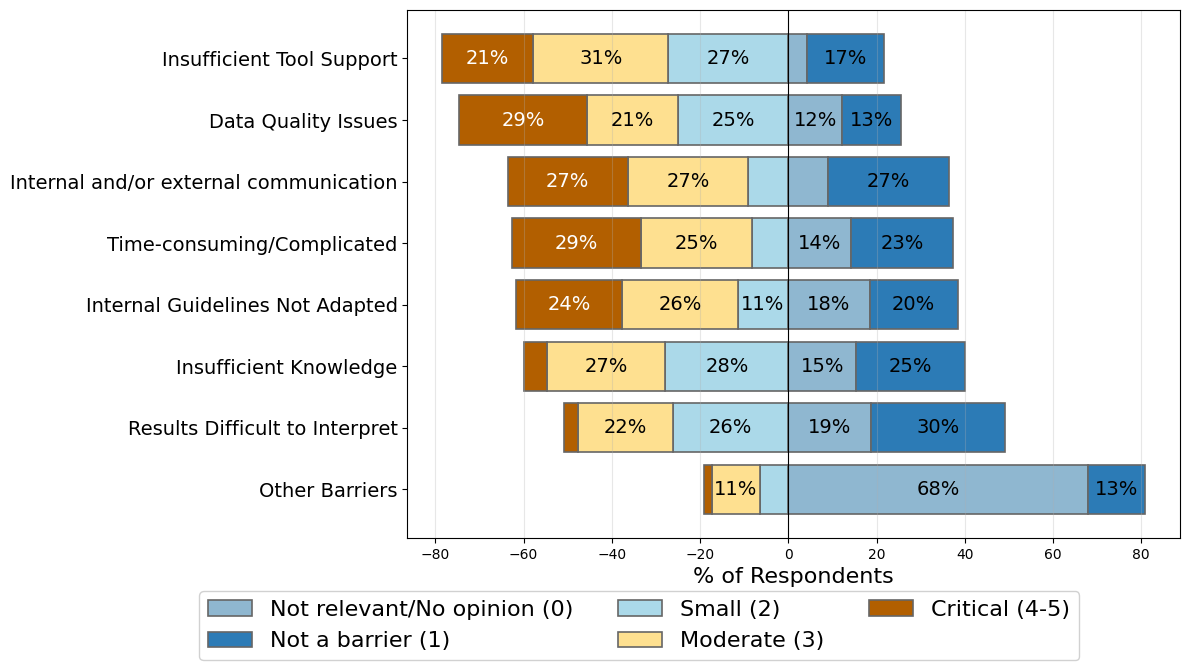


=== Barrier Comparison Summary ===
Time-consuming/Complicated               | Source: Both            | Critical: 29.3%
Data Quality Issues                      | Source: Both            | Critical: 28.9%
Internal and/or external communication   | Source: Interview       | Critical: 27.3%
Internal Guidelines Not Adapted          | Source: Both            | Critical: 24.1%
Insufficient Tool Support                | Source: Both            | Critical: 20.5%
Insufficient Knowledge                   | Source: Both            | Critical: 5.2%
Results Difficult to Interpret           | Source: Both            | Critical: 3.1%
Other Barriers                           | Source: Both            | Critical: 1.9%


In [85]:
# Create combined plot
plot_combined_barriers(merged_barriers, 
                       fontsize=16, figsize=(12,6),
                       mode='combined', title=False,
                       save_path='plots/barriers_comparison.pdf',
                       ) # mode='all' or 'combined'

# Print summary
print("\n=== Barrier Comparison Summary ===")
for item in sorted(merged_barriers, key=lambda x: x['data'][4] + x['data'][5], reverse=True):
    print(f"{item['barrier']:40s} | Source: {item['source']:15s} | "
          f"Critical: {item['data'][4] + item['data'][5]:.1f}%")

In [65]:
import textwrap
def wrap_label(text, width=25):
    if text is None:
        return ""
    return "\n".join(textwrap.wrap(str(text), width=width))
def plot_desire_counts_binary(df_desires, top_k=None,min_count=None,
                              desire_col='Desire',
                              count_col='i_n_1',
                              figsize=(10, 8),
                              fontsize=12,
                              title=True,
                              wrap_width=25,
                              save_path=None):
    """
    Plot binary desire counts (0/1) from calc_desire_usage(..., binary=True).

    Shows number of respondents that selected each desire (i_n_1).
    """

    # Sort by count, optionally keep top_k
    df_plot = df_desires.copy()
    if min_count is not None: df_plot=df_plot[df_plot[count_col]>=min_count]
    df_plot = df_plot.sort_values(count_col, ascending=True)

    if top_k is not None and top_k < len(df_plot):
        total_items = len(df_plot)
        df_plot = df_plot.tail(top_k)
        print(f"Plotting top {len(df_plot)} of {total_items} desires by count")

    desires = [
        wrap_label(str(d).capitalize(), width=wrap_width)
        for d in df_plot[desire_col].values
    ]
    counts = df_plot[count_col].values
    y = np.arange(len(df_plot))

    fig, ax = plt.subplots(figsize=figsize)

    ax.barh(y, counts,
            height=0.6,
            color='#C786A9',       # reuse questionnaire base color
            edgecolor='#7F4F6B')

    ax.set_yticks(y)
    ax.set_yticklabels(desires, fontsize=fontsize)
    
    ax.set_xticklabels(ax.get_xticklabels(),fontsize=fontsize-2)

    ax.set_xlabel('Number of respondents', fontsize=fontsize)
    if title:
        t = 'Desired methods / capabilities (binary)'
        if top_k is not None:
            t += f'\n(Showing top {top_k})'
        ax.set_title(t, fontsize=fontsize, fontweight='bold')

    # Annotate counts at end of bars
    for yi, c in zip(y, counts):
        ax.text(c + 0.1, yi, str(int(c)),
                va='center', ha='left',
                fontsize=fontsize, color='black')

    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, max(counts)*1.15 if len(counts) else 1)

    plt.tight_layout()

    if save_path is not None:
        if not str(save_path).endswith('.pdf'):
            save_path = str(save_path) + '.pdf'
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)

    plt.show()
    return df_plot





In [66]:
plot_desire_counts_binary(df_i_desires_count, top_k=10, fontsize=16,figsize=(10,6), min_count=2,wrap_width=40,title=False, save_path='plots/desires.pdf',)

NameError: name 'df_i_desires_count' is not defined

### Correlation plots



In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
# ========================================
# CORE UTILITY FUNCTIONS
# ========================================

# reuse the indicator_conversion(val) defined earlier in the notebook

def filter_low_variance_columns(df, min_std=0.05):
    """Remove columns with very low variance"""
    cols_to_keep = [col for col in df.columns if df[col].std() > min_std]
    print(f"Filtered {len(df.columns) - len(cols_to_keep)} low-variance columns")
    return df[cols_to_keep]

def filter_variables(df, min_variance=0.05, min_count=5, min_value=1):
    """
    Filter variables by variance AND minimum count
    
    Parameters:
    -----------
    min_variance : float
        Minimum standard deviation (default 0.05)
    min_count : int
        Minimum number of respondents with value >= min_value (default 5)
    min_value : int/float
        Threshold for "experiencing" the barrier/using method (default 1)
    """
    filtered_cols = []
    
    for col in df.columns:
        # Check variance
        variance_ok = df[col].std() > min_variance
        
        # Check count of respondents with meaningful values
        # For barriers: count those with score >= 1 (experiencing the barrier)
        # For methods: count those with score >= 1 (using the method)
        count = (df[col] >= min_value).sum()
        count_ok = count >= min_count
        
        if variance_ok and count_ok:
            filtered_cols.append(col)
        else:
            if not variance_ok:
                print(f"   Filtered {col}: low variance (std={df[col].std():.3f})")
            if not count_ok:
                print(f"   Filtered {col}: low count (n={count})")
    
    return df[filtered_cols]

# ========================================
# DATA PREPARATION - SOFTWARE
# ========================================
def prepare_software_data_grouped(df, short_name_mapping, norwegian_to_english=None):
    """
    Extract software usage data with proper name standardization
    
    Steps:
    1. Extract software columns
    2. Clean prefix
    3. Standardize Norwegian → English (if mapping provided)
    4. Map to short names
    5. Merge duplicate short names with OR logic
    """
    software_cols = [col for col in df.columns if col.startswith("Software-")]
    
    software_data = {}
    for col in software_cols:
        # Step 1: Clean the prefix
        software_name = col.replace("Software-", "").replace("Software- ", "").strip()
        
        # Step 2: Standardize Norwegian to English (MISSING IN YOUR CODE!)
        if norwegian_to_english:
            software_name = norwegian_to_english.get(software_name, software_name)
        
        # Step 3: Get short name for plotting
        short_name = short_name_mapping.get(software_name, software_name)
        
        # Step 4: Extract usage (binary)
        if df[col].dtype in ['float64', 'int64']:
            usage = (df[col] > 0).astype(int)
        else:
            usage = df[col].notna().astype(int)
        
        # Step 5: Merge duplicates with OR (if user uses any variant, count as used)
        if short_name in software_data:
            software_data[short_name] = (software_data[short_name] | usage).astype(int)
        else:
            software_data[short_name] = usage
    
    return pd.DataFrame(software_data)

# ========================================
# DATA PREPARATION - METHODS
# ========================================
def prepare_questionnaire_method_data(df_q, method_map, binary=False):
    """
    Extract method usage scores from questionnaire.
    
    Parameters
    ----------
    df_q : DataFrame
        Questionnaire responses
    method_map : dict
        Mapping of variables to methods
    binary : bool
        If True, convert scores to 0/1 (score >= 2 → 1, else → 0)
        If False, keep original 0-3 scores
    """
    # Create DataFrame with respondent index, empty to start
    method_scores_by_respondent = {}
    
    for idx, row in df_q.iterrows():
        respondent_method_scores = {}
        
        for var_code, meta in method_map.items():
            if var_code not in df_q.columns:
                continue
                
            val = row[var_code]
            if pd.notna(val):
                is_indicator = meta.get('indicator', False)
                
                if is_indicator:
                    score = indicator_conversion(val)
                else:
                    if val is True or val == 1:
                        score = meta.get('score', 0)
                    else:
                        score = 0
                
                if score > 0:
                    methods = meta.get('methods', [])
                    if not isinstance(methods, list):
                        methods = [methods]
                    
                    for method in methods:
                        if method not in respondent_method_scores:
                            respondent_method_scores[method] = score
                        else:
                            respondent_method_scores[method] = max(
                                respondent_method_scores[method], score)
        
        # Store this respondent's scores
        method_scores_by_respondent[idx] = respondent_method_scores
    
    # Get all unique methods
    all_methods = set()
    for scores in method_scores_by_respondent.values():
        all_methods.update(scores.keys())
    
    # Create DataFrame with all methods as columns, fill with 0
    method_df = pd.DataFrame(0, index=df_q.index, columns=sorted(all_methods))
    
    # Fill in the scores
    for idx, scores in method_scores_by_respondent.items():
        for method, score in scores.items():
            method_df.loc[idx, method] = score
    
    # Convert to binary if requested
    if binary:
        method_df = (method_df >= 2).astype(int)
    
    return method_df


def prepare_interview_method_data(df_i, binary=False):
    """
    Extract method scores from interview.
    
    Parameters
    ----------
    df_i : DataFrame
        Interview responses with Method-* columns
    binary : bool
        If True, convert scores to 0/1 (score >= 2 → 1, else → 0)
        If False, keep original 0-3 scores
    """
    method_cols = [col for col in df_i.columns if col.startswith("Method")]
    
    if not method_cols:
        return pd.DataFrame(index=df_i.index)
    
    method_df = df_i[method_cols].copy()
    # Clean column names (remove prefix)
    method_df.columns = [col.replace("Methods-", "").replace("Method-", "").strip() 
                        for col in method_df.columns]
    
    # Fill NaN with 0 for consistency
    method_df = method_df.fillna(0)
    
    # Convert to binary if requested
    if binary:
        method_df = (method_df >= 2).astype(int)
    
    return method_df


# ========================================
# DATA PREPARATION - BARRIERS
# ========================================

def prepare_interview_barriers(df_i):
    """Extract interview barriers as raw values (0-3 scale) for correlation"""
    barrier_cols = [col for col in df_i.columns 
                   if col.startswith("Barriers-") 
                   and not col.lower().endswith('desc')]
    
    if not barrier_cols:
        return pd.DataFrame()
    
    barrier_df = df_i[barrier_cols].copy()
    # Remove "Barriers-" prefix from column names
    barrier_df.columns = [col.replace("Barriers-", "") for col in barrier_cols]
    
    return barrier_df

def prepare_barrier_data_with_source_tracking(df_q, df_i, barriers_mappings):
    """
    Prepare barrier data with proper NaN handling for interview-only barriers
    """
    # Questionnaire barriers
    q_barrier_cols = [col for col in df_q.columns 
                     if ('software_barrieres' in col.lower() or 
                         'indicators_barriers' in col.lower())
                     and not col.lower().endswith('desc')]
    
    q_barrier_data = {}
    for col in q_barrier_cols:
        barrier_name = barriers_mappings.get(col, col)
        if barrier_name in q_barrier_data:
            q_barrier_data[barrier_name] = (q_barrier_data[barrier_name] + df_q[col]) / 2
        else:
            q_barrier_data[barrier_name] = df_q[col].copy()
    
    q_barrier_df = pd.DataFrame(q_barrier_data, index=df_q.index)
    
    # Interview barriers
    i_barrier_df = prepare_interview_barriers(df_i)
    
    # Track source of each barrier
    barrier_sources = {}
    for b in q_barrier_df.columns:
        barrier_sources[b] = 'both' if b in i_barrier_df.columns else 'questionnaire'
    for b in i_barrier_df.columns:
        if b not in barrier_sources:
            barrier_sources[b] = 'interview'
    
    # Align columns
    all_barriers = sorted(set(q_barrier_df.columns) | set(i_barrier_df.columns))
    
    # Add missing columns with appropriate fill values
    for b in all_barriers:
        if b not in q_barrier_df.columns:
            # Questionnaire missing this barrier
            if barrier_sources.get(b) == 'interview':
                q_barrier_df[b] = np.nan  # NaN for interview-only barriers
            else:
                q_barrier_df[b] = 0  # 0 for other missing barriers
        
        if b not in i_barrier_df.columns:
            # Interview missing this barrier
            if barrier_sources.get(b) == 'questionnaire':
                i_barrier_df[b] = np.nan  # NaN for questionnaire-only barriers
            else:
                i_barrier_df[b] = 0  # 0 for other missing barriers
    
    # Reorder columns
    q_barrier_df = q_barrier_df[all_barriers]
    i_barrier_df = i_barrier_df[all_barriers]
    
    # Combine
    combined = pd.concat([q_barrier_df, i_barrier_df], axis=0)
    
    return combined, barrier_sources
# ========================================
# CORRELATION CALCULATION
# ========================================
def calculate_correlation_with_source_filter(df1, df2, barrier_sources, method='spearman'):
    """
    Calculate correlation - FIXED to handle combined data correctly
    """
    common_idx = df1.index.intersection(df2.index)
    df1_aligned = df1.loc[common_idx]
    df2_aligned = df2.loc[common_idx]
    
    print(f"   DEBUG: common_idx has {len(common_idx)} respondents")
    print(f"   DEBUG: df1 shape: {df1_aligned.shape}, df2 shape: {df2_aligned.shape}")
    
    n_samples = len(common_idx)
    
    corr_matrix = pd.DataFrame(np.nan, index=df1_aligned.columns, 
                               columns=df2_aligned.columns, dtype=float)
    pval_matrix = pd.DataFrame(np.nan, index=df1_aligned.columns, 
                               columns=df2_aligned.columns, dtype=float)
    
    for col1 in df1_aligned.columns:
        for col2 in df2_aligned.columns:
            try:
                x = df1_aligned[col1]
                y = df2_aligned[col2]
                
                # Remove NaN values (only use rows where both have data)
                valid_mask = (~x.isna()) & (~y.isna())
                x_valid = x[valid_mask]
                y_valid = y[valid_mask]
                
                # DEBUG: Print for first correlation
                if col1 == df1_aligned.columns[0] and col2 == df2_aligned.columns[0]:
                    print(f"   DEBUG: First correlation - valid pairs: {len(x_valid)}/{len(common_idx)}")
                    print(f"   DEBUG: x has {x.isna().sum()} NaNs, y has {y.isna().sum()} NaNs")
                
                # Need at least 3 data points
                if len(x_valid) < 3 or x_valid.std() == 0 or y_valid.std() == 0:
                    corr_matrix.loc[col1, col2] = 0.0
                    pval_matrix.loc[col1, col2] = 1.0
                    continue
                
                # Calculate correlation
                if method == 'spearman':
                    corr, pval = spearmanr(x_valid, y_valid)
                else:
                    corr, pval = pearsonr(x_valid, y_valid)
                
                corr_matrix.loc[col1, col2] = float(corr) if not np.isnan(corr) else 0.0
                pval_matrix.loc[col1, col2] = float(pval) if not np.isnan(pval) else 1.0
                
            except Exception as e:
                print(f"   ERROR: {col1} vs {col2}: {e}")
                corr_matrix.loc[col1, col2] = 0.0
                pval_matrix.loc[col1, col2] = 1.0
    
    return corr_matrix, pval_matrix, n_samples


def calculate_correlation_with_options(df1, df2, barrier_sources, method='spearman',
                                       data_source='both', q_indices=None, i_indices=None):
    """
    Calculate correlation with data source selection
    
    Parameters:
    -----------
    data_source : str
        'both' (default): Use all data
        'q': Use only questionnaire data
        'i': Use only interview data
    q_indices : Index
        Indices of questionnaire respondents
    i_indices : Index
        Indices of interview respondents
    """
    # Filter by data source
    if data_source == 'q' and q_indices is not None:
        df1 = df1.loc[q_indices]
        df2 = df2.loc[q_indices]
        print(f"   Using questionnaire data only: {len(q_indices)} respondents")
    elif data_source == 'i' and i_indices is not None:
        df1 = df1.loc[i_indices]
        df2 = df2.loc[i_indices]
        print(f"   Using interview data only: {len(i_indices)} respondents")
    elif data_source == 'both':
        print(f"   Using combined data: {len(df1)} respondents")
    else:
        print(f"   Warning: Invalid data_source '{data_source}', using 'both'")
    
    # Standard correlation calculation
    common_idx = df1.index.intersection(df2.index)
    df1_aligned = df1.loc[common_idx]
    df2_aligned = df2.loc[common_idx]
    
    n_samples = len(common_idx)
    
    corr_matrix = pd.DataFrame(np.nan, index=df1_aligned.columns, 
                               columns=df2_aligned.columns, dtype=float)
    pval_matrix = pd.DataFrame(np.nan, index=df1_aligned.columns, 
                               columns=df2_aligned.columns, dtype=float)
    
    for col1 in df1_aligned.columns:
        for col2 in df2_aligned.columns:
            try:
                x = df1_aligned[col1]
                y = df2_aligned[col2]
                
                valid_mask = (~x.isna()) & (~y.isna())
                x_valid = x[valid_mask]
                y_valid = y[valid_mask]
                
                if len(x_valid) < 3 or x_valid.std() == 0 or y_valid.std() == 0:
                    corr_matrix.loc[col1, col2] = 0.0
                    pval_matrix.loc[col1, col2] = 1.0
                    continue
                
                if method == 'spearman':
                    corr, pval = spearmanr(x_valid, y_valid)
                else:
                    corr, pval = pearsonr(x_valid, y_valid)
                
                corr_matrix.loc[col1, col2] = float(corr) if not np.isnan(corr) else 0.0
                pval_matrix.loc[col1, col2] = float(pval) if not np.isnan(pval) else 1.0
                
            except Exception as e:
                corr_matrix.loc[col1, col2] = 0.0
                pval_matrix.loc[col1, col2] = 1.0
    
    return corr_matrix, pval_matrix, n_samples


In [63]:
# ========================================
# 3. ENHANCED VISUALIZATION
# ========================================
def plot_correlation_heatmap_with_significance(
        corr_matrix, pval_matrix, title=None,
        save_path=None, figsize=(14, 10),
        top_k=20, show_values=True,
        min_p=0.05, min_r=0.0, fontsize=12):

    # Filter significant/strong rows/cols
    significant_mask = (pval_matrix < min_p) & (corr_matrix.abs() >= min_r)

    rows_with_sig = significant_mask.any(axis=1)
    cols_with_sig = significant_mask.any(axis=0)

    corr_matrix_filtered = corr_matrix.loc[rows_with_sig, cols_with_sig]
    pval_matrix_filtered = pval_matrix.loc[rows_with_sig, cols_with_sig]

    print(f"   Filtered: {corr_matrix.shape} → {corr_matrix_filtered.shape} "
          f"({len(corr_matrix) - rows_with_sig.sum()} methods, "
          f"{len(corr_matrix.columns) - cols_with_sig.sum()} barriers removed)")

    if corr_matrix_filtered.empty:
        print(f"   No correlations with p<{min_p} and |r|≥{min_r} found!")
        return None

    # Apply top_k filtering if specified
    if top_k is not None and top_k < len(corr_matrix_filtered):
        max_abs_corr = corr_matrix_filtered.abs().max(axis=1)
        top_methods = max_abs_corr.nlargest(top_k).index
        corr_matrix_plot = corr_matrix_filtered.loc[top_methods, :]
        pval_matrix_plot = pval_matrix_filtered.loc[top_methods, :]
        print(f"   Showing top {top_k} methods out of {len(corr_matrix_filtered)}")
    else:
        corr_matrix_plot = corr_matrix_filtered
        pval_matrix_plot = pval_matrix_filtered

    fig, ax = plt.subplots(figsize=figsize)

    # Create annotations
    annot_matrix = np.full(corr_matrix_plot.shape, '', dtype=object)

    for i in range(corr_matrix_plot.shape[0]):
        for j in range(corr_matrix_plot.shape[1]):
            corr_val = corr_matrix_plot.iloc[i, j]
            pval = pval_matrix_plot.iloc[i, j]

            if pd.isna(corr_val):
                annot_matrix[i, j] = ''
            else:
                val_str = f"{corr_val:.2f}"
                if pval < min_p and abs(corr_val) >= min_r:
                    if pval < 0.001:
                        val_str += "***"
                    elif pval < 0.01:
                        val_str += "**"
                    else:
                        val_str += "*"
                annot_matrix[i, j] = val_str

    mask = corr_matrix_plot.isna()

    # Heatmap
    sns.heatmap(
        corr_matrix_plot,
        mask=mask,
        cmap='RdBu_r',
        center=0,
        vmin=-1, vmax=1,
        annot=annot_matrix if show_values else False,
        fmt='',
        square=True,
        linewidths=0.5,
        cbar=False,
        #cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.7},
        #annot_kws={'fontsize': fontsize-2},
        ax=ax
    )
    
    xticklabels = ax.get_xticklabels()
    ax.set_xticklabels([lbl.get_text().capitalize() for lbl in xticklabels],
    fontsize=fontsize)
    yticklabels = ax.get_yticklabels()
    ax.set_yticklabels([lbl.get_text().capitalize() for lbl in yticklabels],
    fontsize=fontsize)

    # Styling of annotation text
    for text in ax.texts:
        text_content = text.get_text()
        if not text_content:
            continue

        try:
            corr_val_str = text_content.split('*')[0]
            corr_val = float(corr_val_str)
        except Exception:
            corr_val = 0.0

        is_significant = '*' in text_content
        is_strong = abs(corr_val) >= 0.7   # "strong" threshold, independent of min_r

        if is_significant and is_strong:
            # Strong + significant: white, bold
            text.set_color('white')
            text.set_fontweight('bold')
            text.set_fontsize(fontsize)
        elif is_significant and abs(corr_val) >= min_r:
            # Significant but not strong: black, normal
            text.set_color('black')
            text.set_fontweight('normal')
            text.set_fontsize(fontsize)
        else:
            # Weak or non-significant
            text.set_color('#AAAAAA')
            text.set_fontweight('normal')
            text.set_fontsize(fontsize-2)

    # Axes title only (no explanation here)
    if title is None:
        title = ""
    ax.set_title(title, fontsize=fontsize, pad=10)

    plt.xticks(rotation=45, ha='right', fontsize=fontsize)
    plt.yticks(rotation=0, fontsize=fontsize)

    # Explanatory legend-like text box BELOW plot
    if min_r > 0:
        expl = (
            #fr"Significance annotation coding: *:p<{min_p}, **:p<0.01, ***:p<0.001"
            fr"*:p<{min_p}, **:p<0.01, ***:p<0.001" # no explanatory text
            #fr"{min_r} ≤|r| <0.7 : Moderate and ""|r| ≥ 0.7 and : Strong"
        )
    else:
        expl = (
            #fr"Significance annotation coding: *:p<{min_p}, **:p<0.01, ***:p<0.001"
            fr"*:p<{min_p}, **:p<0.01, ***:p<0.001" # no explanatory text
            #"|r| ≥ 0.7 and significant shown in bold white."
        )

    # Shrink axis to make room for box
    box = ax.get_position()
    ax.set_position([box.x0*0.1, box.y0 + box.height*0.1,
                     box.width, box.height*0.9])

    fig.text(
        0.5, 1.1, expl,
        ha='center', va='bottom',
        fontsize=fontsize,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9)
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)

    plt.show()
    plt.close(fig)
    return None



def plot_top_correlations_detailed(corr_matrix, pval_matrix, top_n=20, save_path=None):
    """Plot top correlations as bar chart with p-values"""
    # Flatten and filter
    corr_flat = []
    for i in corr_matrix.index:
        for j in corr_matrix.columns:
            if not np.isnan(corr_matrix.loc[i, j]):
                corr_flat.append({
                    'Pair': f"{i} ↔ {j}",
                    'Variable1': i,
                    'Variable2': j,
                    'Correlation': corr_matrix.loc[i, j],
                    'P-value': pval_matrix.loc[i, j],
                    'Significant': 'Yes' if pval_matrix.loc[i, j] < 0.05 else 'No'
                })
    
    corr_df = pd.DataFrame(corr_flat)
    
    if len(corr_df) == 0:
        print("No correlations to plot")
        return None
    
    # Sort by absolute correlation and get top N
    corr_df['Abs_Correlation'] = abs(corr_df['Correlation'])
    corr_df = corr_df.sort_values('Abs_Correlation', ascending=False)
    top_corr = corr_df.head(top_n)
    
    # Sort by correlation value for plotting
    top_corr = top_corr.sort_values('Correlation')
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, max(8, len(top_corr) * 0.35)))
    
    # FIX: Plot each bar individually with its own color and alpha
    for i, (idx, row) in enumerate(top_corr.iterrows()):
        color = 'red' if row['Correlation'] < 0 else 'green'
        alpha = 0.8 if row['Significant'] == 'Yes' else 0.3
        
        ax.barh(i, row['Correlation'], color=color, alpha=alpha)
        
        # Add p-value label
        x_pos = row['Correlation'] + (0.02 if row['Correlation'] > 0 else -0.02)
        ha = 'left' if row['Correlation'] > 0 else 'right'
        
        # Format p-value
        if row['P-value'] < 0.001:
            pval_str = "p<0.001"
        else:
            pval_str = f"p={row['P-value']:.3f}"
        
        ax.text(x_pos, i, pval_str, 
               va='center', ha=ha, fontsize=8,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    # Format axes
    ax.set_yticks(range(len(top_corr)))
    ax.set_yticklabels(top_corr['Pair'], fontsize=9)
    ax.set_xlabel('Correlation Coefficient', fontsize=12, fontweight='bold')
    ax.set_title(f'Top {top_n} Correlations\n(Darker bars = p<0.05, Red=Negative, Green=Positive)', 
                fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=1)
    ax.grid(axis='x', alpha=0.3)
    
    # Set x-axis limits with some padding
    if len(top_corr) > 0:
        max_abs = max(abs(top_corr['Correlation'].min()), abs(top_corr['Correlation'].max()))
        ax.set_xlim(-max_abs * 1.15, max_abs * 1.15)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
    
    plt.show()
    # Print table
    print("\n=== Top Correlations Summary ===")
    print(top_corr[['Pair', 'Correlation', 'P-value', 'Significant']].to_string(index=False))
    
    return None

def plot_correlation_scatter_grid_improved(df1, df2, corr_matrix, pval_matrix, 
                                          top_n=9, min_pval=0.2, save_path=None
                                          ):
    """
    Improved scatter plot with source coloring - WORKS WITH PREFIXED INDICES
    """
    # Get significant correlations
    corr_flat = []
    for i in corr_matrix.index:
        for j in corr_matrix.columns:
            if not np.isnan(corr_matrix.loc[i, j]):
                corr_flat.append({
                    'var1': i, 'var2': j,
                    'corr': abs(corr_matrix.loc[i, j]),
                    'corr_signed': corr_matrix.loc[i, j],
                    'pval': pval_matrix.loc[i, j]
                })
    
    corr_df = pd.DataFrame(corr_flat)
    corr_df_sig = corr_df[corr_df['pval'] < min_pval]
    
    if len(corr_df_sig) == 0:
        print(f"No correlations with p<{min_pval}")
        return None
    
    top_corr = corr_df_sig.nlargest(min(top_n, len(corr_df_sig)), 'corr')
    
    # Create grid
    n_plots = len(top_corr)
    n_rows = int(np.ceil(np.sqrt(n_plots)))
    n_cols = int(np.ceil(n_plots / n_rows))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
    if n_plots == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
    
    # Align data
    common_idx = df1.index.intersection(df2.index)
    df1_aligned = df1.loc[common_idx]
    df2_aligned = df2.loc[common_idx]
    
    for plot_idx, (_, row) in enumerate(top_corr.iterrows()):
        if plot_idx >= len(axes):
            break
        
        ax = axes[plot_idx]
        var1, var2 = row['var1'], row['var2']
        
        # Get data, remove NaNs
        x = df1_aligned[var1]
        y = df2_aligned[var2]
        valid_mask = (~x.isna()) & (~y.isna())
        
        x_valid = x[valid_mask].values
        y_valid = y[valid_mask].values
        valid_indices = x[valid_mask].index
        
        # Determine colors based on PREFIX - UPDATED LOGIC
        colors = []
        n_q = 0
        n_i = 0
        
        for idx in valid_indices:
            idx_str = str(idx)
            if idx_str.startswith('Q_'):
                colors.append('steelblue')
                n_q += 1
            elif idx_str.startswith('I_'):
                colors.append('darkorange')
                n_i += 1
            else:
                colors.append('gray')  # Unknown source
        
        # Add jitter
        np.random.seed(42)
        x_jitter = x_valid + np.random.uniform(-0.05, 0.05, len(x_valid))
        y_jitter = y_valid + np.random.uniform(-0.05, 0.05, len(y_valid))
        
        # Plot with colors
        ax.scatter(x_jitter, y_jitter, c=colors, alpha=0.7, s=70, 
                  edgecolors='black', linewidths=0.7)
        
        # Trend line
        if len(np.unique(x_valid)) > 1 and len(np.unique(y_valid)) > 1:
            try:
                z = np.polyfit(x_valid, y_valid, 1)
                p = np.poly1d(z)
                x_line = np.linspace(x_valid.min(), x_valid.max(), 100)
                ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2.5)
            except:
                pass
        
        # Format
        ax.set_xlabel(var1, fontsize=11, fontweight='bold')
        ax.set_ylabel(var2, fontsize=11, fontweight='bold')
        ax.set_title(f"r={row['corr_signed']:.3f} (p={row['pval']:.4f})", 
                    fontsize=12, fontweight='bold')
        ax.grid(alpha=0.3, linestyle='--')
        
        # Sample size and source breakdown
        ax.text(0.02, 0.98, f"n={len(x_valid)} (Q:{n_q}, I:{n_i})", 
               transform=ax.transAxes, fontsize=10, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
        
        # Integer ticks for discrete data
        if x_valid.max() <= 3:
            ax.set_xticks([0, 1, 2, 3])
        if y_valid.max() <= 5:
            ax.set_yticks(range(int(y_valid.max()) + 1))
    
    # Hide unused subplots
    for idx in range(len(top_corr), len(axes)):
        axes[idx].axis('off')
    
    # Add legend
    if n_plots > 0:
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', 
                   markersize=10, markeredgecolor='black', markeredgewidth=0.7, label='Questionnaire'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', 
                   markersize=10, markeredgecolor='black', markeredgewidth=0.7, label='Interview')
        ]
        fig.legend(handles=legend_elements, loc='upper right', fontsize=12, frameon=True)
    
    plt.suptitle(f'Top Correlations (p<{min_pval})', 
                fontsize=16, fontweight='bold', y=0.998)
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
    
    plt.show()
    return None


def plot_single_correlation_scatter(df1, df2, corr_matrix, pval_matrix, 
                                    method_name='power flow analysis', barrier_name='Internal and/or external communication',
                                    save_path=None):
    """
    Plot scatter for a specific method-barrier pair
    
    Parameters:
    -----------
    df1 : DataFrame
        Methods dataframe
    df2 : DataFrame
        Barriers dataframe
    method_name : str
        Name of method (must exist in df1.columns)
    barrier_name : str
        Name of barrier (must exist in df2.columns)
    """
    # Validate inputs
    if method_name not in df1.columns:
        print(f"Error: Method '{method_name}' not found in data")
        print(f"Available methods: {list(df1.columns[:10])}...")
        return None
    
    if barrier_name not in df2.columns:
        print(f"Error: Barrier '{barrier_name}' not found in data")
        print(f"Available barriers: {list(df2.columns)}")
        return None
    
    # Get correlation and p-value
    corr_val = corr_matrix.loc[barrier_name,method_name]
    pval = pval_matrix.loc[barrier_name,method_name]
    
    # Align data
    common_idx = df1.index.intersection(df2.index)
    x = df1.loc[common_idx, method_name]
    y = df2.loc[common_idx, barrier_name]
    
    # Remove NaN
    valid_mask = (~x.isna()) & (~y.isna())
    x_valid = x[valid_mask].values
    y_valid = y[valid_mask].values
    valid_indices = x[valid_mask].index
    
    # Colors by source
    colors = []
    n_q = 0
    n_i = 0
    for idx in valid_indices:
        idx_str = str(idx)
        if idx_str.startswith('Q_'):
            colors.append('steelblue')
            n_q += 1
        elif idx_str.startswith('I_'):
            colors.append('darkorange')
            n_i += 1
        else:
            colors.append('gray')
    
    # Create plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Add jitter
    np.random.seed(42)
    x_jitter = x_valid + np.random.uniform(-0.05, 0.05, len(x_valid))
    y_jitter = y_valid + np.random.uniform(-0.01, 0.01, len(y_valid))
    
    # Scatter
    ax.scatter(x_jitter, y_jitter, c=colors, alpha=0.7, s=80, 
              edgecolors='black', linewidths=0.8)
    
    # Trend line
    if len(np.unique(x_valid)) > 1 and len(np.unique(y_valid)) > 1:
        z = np.polyfit(x_valid, y_valid, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x_valid.min(), x_valid.max(), 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=3)
    
    # Format
    ax.set_xlabel(method_name, fontsize=12, fontweight='bold')
    ax.set_ylabel(barrier_name, fontsize=12, fontweight='bold')
    ax.set_title(f"{method_name} vs {barrier_name}\nr={corr_val:.3f}, p={pval:.4f}", 
                fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3, linestyle='--')
    
    # Stats box
    ax.text(0.02, 0.98, f"n={len(x_valid)} (Q:{n_q}, I:{n_i})", 
           transform=ax.transAxes, fontsize=11, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Integer ticks
    if x_valid.max() <= 3:
        ax.set_xticks([0, 1, 2, 3])
    if y_valid.max() <= 5:
        ax.set_yticks(range(int(y_valid.max()) + 1))
    
    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', 
               markersize=10, markeredgecolor='black', label='Questionnaire'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', 
               markersize=10, markeredgecolor='black', label='Interview')
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=11)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
    
    plt.show()
    return None


In [70]:
print("\n=== Preparing Data ===")

# 1. METHODS (scores 0-3, 0 means not used)
print("\n1. Methods...")
#method_df_q = prepare_questionnaire_method_data(df_q, METHOD_MAP)
#method_df_i = prepare_interview_method_data(df_i)
# For binary usage (0/1: using vs not using)
method_df_q = prepare_questionnaire_method_data(df_q, METHOD_MAP, binary=True)
method_df_i = prepare_interview_method_data(df_i, binary=True)

# CRITICAL: Add prefix to indices to make them unique
method_df_q.index = ['Q_' + str(idx) for idx in method_df_q.index]
method_df_i.index = ['I_' + str(idx) for idx in method_df_i.index]

# Ensure column names are strings
method_df_q.columns = [str(col) for col in method_df_q.columns]
method_df_i.columns = [str(col) for col in method_df_i.columns]

# STORE INDICES AFTER PREFIX
q_indices = method_df_q.index.copy()
i_indices = method_df_i.index.copy()

print(f"\nDEBUG: q_indices: {len(q_indices)} values - {list(q_indices[:3])}")
print(f"DEBUG: i_indices: {len(i_indices)} values - {list(i_indices[:3])}")

# Align columns
all_methods = sorted(set(method_df_q.columns) | set(method_df_i.columns))

for m in all_methods:
    if m not in method_df_q.columns:
        method_df_q[m] = 0
    if m not in method_df_i.columns:
        method_df_i[m] = 0

method_df_q = method_df_q[all_methods]
method_df_i = method_df_i[all_methods]

method_df_combined = pd.concat([method_df_q, method_df_i], axis=0)

print(f"   Q: {method_df_q.shape}, I: {method_df_i.shape}, Combined: {method_df_combined.shape}")
print(f"   Combined index sample: {list(method_df_combined.index[:3])} ... {list(method_df_combined.index[-3:])}")

# 2. SOFTWARE (binary 0/1)
print("\n2. Software...")
software_df_q = prepare_software_data_grouped(
    df_q, 
    SHORT_NAME_MAPPING,
    norwegian_to_english=NORWEGIAN_TO_ENGLISH  # <-- ADD THIS!
)

software_df_i = prepare_software_data_grouped(
    df_i, 
    SHORT_NAME_MAPPING,
    norwegian_to_english=NORWEGIAN_TO_ENGLISH  # <-- ADD THIS!
)

# ADD PREFIX TO SOFTWARE INDICES
software_df_q.index = ['Q_' + str(idx) for idx in software_df_q.index]
software_df_i.index = ['I_' + str(idx) for idx in software_df_i.index]

# Ensure column names are strings
software_df_q.columns = [str(col) for col in software_df_q.columns]
software_df_i.columns = [str(col) for col in software_df_i.columns]

# Debug: Print unique software names
print(f"   Unique Q software: {list(software_df_q.columns[:10])}")
print(f"   Unique I software: {list(software_df_i.columns[:10])}")

# Align columns
all_software = sorted(set(software_df_q.columns) | set(software_df_i.columns))

for sw in all_software:
    if sw not in software_df_q.columns:
        software_df_q[sw] = 0
    if sw not in software_df_i.columns:
        software_df_i[sw] = 0

software_df_q = software_df_q[all_software]
software_df_i = software_df_i[all_software]

software_df_combined = pd.concat([software_df_q, software_df_i], axis=0)

print(f"   Q: {software_df_q.shape}, I: {software_df_i.shape}, Combined: {software_df_combined.shape}")
print(f"   Final software names: {list(software_df_combined.columns)}")
# 3. BARRIERS (with NaN for interview-only barriers)
print("\n3. Barriers...")
# NEED TO MODIFY prepare_barrier_data_with_source_tracking to add prefixes
# OR do it here:

# First get the barrier data
q_barrier_cols = [col for col in df_q.columns 
                 if ('software_barrieres' in col.lower() or 
                     'indicators_barriers' in col.lower())
                 and not col.lower().endswith('desc')]

q_barrier_data = {}
for col in q_barrier_cols:
    barrier_name = BARRIERS_MAPPINGS.get(col, col)
    if barrier_name in q_barrier_data:
        q_barrier_data[barrier_name] = (q_barrier_data[barrier_name] + df_q[col]) / 2
    else:
        q_barrier_data[barrier_name] = df_q[col].copy()

q_barrier_df = pd.DataFrame(q_barrier_data, index=df_q.index)
# ADD PREFIX
q_barrier_df.index = ['Q_' + str(idx) for idx in q_barrier_df.index]

# Interview barriers
i_barrier_df = prepare_interview_barriers(df_i)
# ADD PREFIX
i_barrier_df.index = ['I_' + str(idx) for idx in i_barrier_df.index]

# Track sources
barrier_sources = {}
for b in q_barrier_df.columns:
    barrier_sources[b] = 'both' if b in i_barrier_df.columns else 'questionnaire'
for b in i_barrier_df.columns:
    if b not in barrier_sources:
        barrier_sources[b] = 'interview'

# Align
all_barriers = sorted(set(q_barrier_df.columns) | set(i_barrier_df.columns))

for b in all_barriers:
    if b not in q_barrier_df.columns:
        q_barrier_df[b] = np.nan
    if b not in i_barrier_df.columns:
        i_barrier_df[b] = np.nan

q_barrier_df = q_barrier_df[all_barriers]
i_barrier_df = i_barrier_df[all_barriers]

all_barrier_df = pd.concat([q_barrier_df, i_barrier_df], axis=0)

print(f"   Combined: {all_barrier_df.shape}")
print(f"   Barrier index sample: {list(all_barrier_df.index[:3])} ... {list(all_barrier_df.index[-3:])}")

interview_only = [b for b, src in barrier_sources.items() if src == 'interview']
print(f"   Interview-only barriers: {interview_only}")

print("\n4. Filtering with variance AND minimum count...")

method_df_filt = filter_variables(
    method_df_combined, 
    min_variance=0.05, 
    min_count=3,  # At least 5 respondents use this method
    min_value=1   # Score >= 1 means "used"
)

barrier_df_filt = filter_variables(
    all_barrier_df, 
    min_variance=0.05, 
    min_count=5,  # At least 3 respondents experience this barrier
    min_value=2   # Score >= 2 means "minor barrier"
)

software_df_filt = filter_variables(
    software_df_combined, 
    min_variance=0.05, 
    min_count=5,  # Lower threshold for software (binary)
    min_value=1   # 1 = used
)

print(f"   Methods: {method_df_combined.shape[1]} → {method_df_filt.shape[1]} variables")
print(f"   Barriers: {all_barrier_df.shape[1]} → {barrier_df_filt.shape[1]} variables")
print(f"   Software: {software_df_combined.shape[1]} → {software_df_filt.shape[1]} variables")

# Verify indices are unique
print(f"\n   Verification:")
print(f"   Q indices start with 'Q_': {all(str(idx).startswith('Q_') for idx in q_indices)}")
print(f"   I indices start with 'I_': {all(str(idx).startswith('I_') for idx in i_indices)}")
print(f"   No overlap: {len(set(q_indices) & set(i_indices)) == 0}")



=== Preparing Data ===

1. Methods...

DEBUG: q_indices: 24 values - ['Q_0', 'Q_1', 'Q_2']
DEBUG: i_indices: 11 values - ['I_0', 'I_1', 'I_2']
   Q: (24, 87), I: (11, 87), Combined: (35, 87)
   Combined index sample: ['Q_0', 'Q_1', 'Q_2'] ... ['I_8', 'I_9', 'I_10']

2. Software...
   Unique Q software: ['ATP-EMTP', 'Scada', 'CYMEDIST', 'Digpro', 'DINID', 'DYMOLA', 'Dynawo', 'ERACS', 'ETAP', 'PSS/E']
   Unique I software: ['MatDyn', 'MathPower', 'Matlab', 'NEPLAN', 'Netbas', 'OpenDSS', 'OpenModellica', 'Power World', 'PowerFactory', 'Powergem Tara']
   Q: (24, 44), I: (11, 44), Combined: (35, 44)
   Final software names: ['ATP-EMTP', 'Aristo', 'CYMEDIST', 'DINID', 'DMS', 'DYMOLA', 'Digpro', 'Dynawo', 'ERACS', 'ETAP', 'Excel', 'Fosweb', 'Gridcal Sk', 'Gridlab-D', 'IPSA', 'In-house/Self-developed', 'Joulia', 'Julia Power Tools', 'MatDyn', 'MathPower', 'Matlab', 'NEPLAN', 'Netbas', 'None', 'OPALRT', 'OpenDSS', 'OpenModellica', 'Other Software', 'PSAT', 'PSS/E', 'Power BI', 'Power World', 

In [71]:
# ========================================
# CORRELATION ANALYSIS - do the calculations
# ========================================

DATA_SOURCE = 'both'  # 'both', 'q', or 'i'

# 1. METHODS vs BARRIERS
print(f"\n=== 1. Methods vs Barriers (source={DATA_SOURCE}) ===")

# Calculate correlations (this filters internally)
corr_mb, pval_mb, n_mb = calculate_correlation_with_options(
    method_df_filt,barrier_df_filt, barrier_sources, 
    method='spearman', data_source=DATA_SOURCE, 
    q_indices=q_indices, i_indices=i_indices)
print(f"Sample size: {n_mb}, Significant (p<0.05): {(pval_mb < 0.05).sum().sum()}/{pval_mb.size}")

# 2. METHODS vs SOFTWARE
print(f"\n=== 2. Methods vs Software (source={DATA_SOURCE}) ===")

corr_ms, pval_ms, n_ms = calculate_correlation_with_options(
    method_df_filt, software_df_filt, {}, 
    method='spearman', data_source=DATA_SOURCE,
    q_indices=q_indices, i_indices=i_indices)
print(f"Sample size: {n_ms}, Significant (p<0.05): {(pval_ms < 0.05).sum().sum()}/{pval_ms.size}")

# 3. SOFTWARE vs BARRIERS
print(f"\n=== 3. Software vs Barriers (source={DATA_SOURCE}) ===")
corr_sb, pval_sb, n_sb = calculate_correlation_with_options(
    software_df_filt, barrier_df_filt, barrier_sources, 
    method='spearman', data_source=DATA_SOURCE,
    q_indices=q_indices, i_indices=i_indices)

print(f"Sample size: {n_sb}, Significant (p<0.05): {(pval_sb < 0.05).sum().sum()}/{pval_sb.size}")




=== 1. Methods vs Barriers (source=both) ===
   Using combined data: 35 respondents
Sample size: 35, Significant (p<0.05): 21/231

=== 2. Methods vs Software (source=both) ===
   Using combined data: 35 respondents
Sample size: 35, Significant (p<0.05): 43/264

=== 3. Software vs Barriers (source=both) ===
   Using combined data: 35 respondents
Sample size: 35, Significant (p<0.05): 3/56


### Method vs barriers plots

In [71]:

# FILTER DATA FOR SCATTER PLOT based on DATA_SOURCE
if DATA_SOURCE == 'q':
    method_plot_df = method_df_filt.loc[q_indices]
    barrier_plot_df = barrier_df_filt.loc[q_indices]
elif DATA_SOURCE == 'i':
    method_plot_df = method_df_filt.loc[i_indices]
    barrier_plot_df = barrier_df_filt.loc[i_indices]
else:  # 'both'
    method_plot_df = method_df_filt
    barrier_plot_df = barrier_df_filt

   Filtered: (33, 7) → (9, 5) (24 methods, 2 barriers removed)
   Showing top 5 methods out of 9


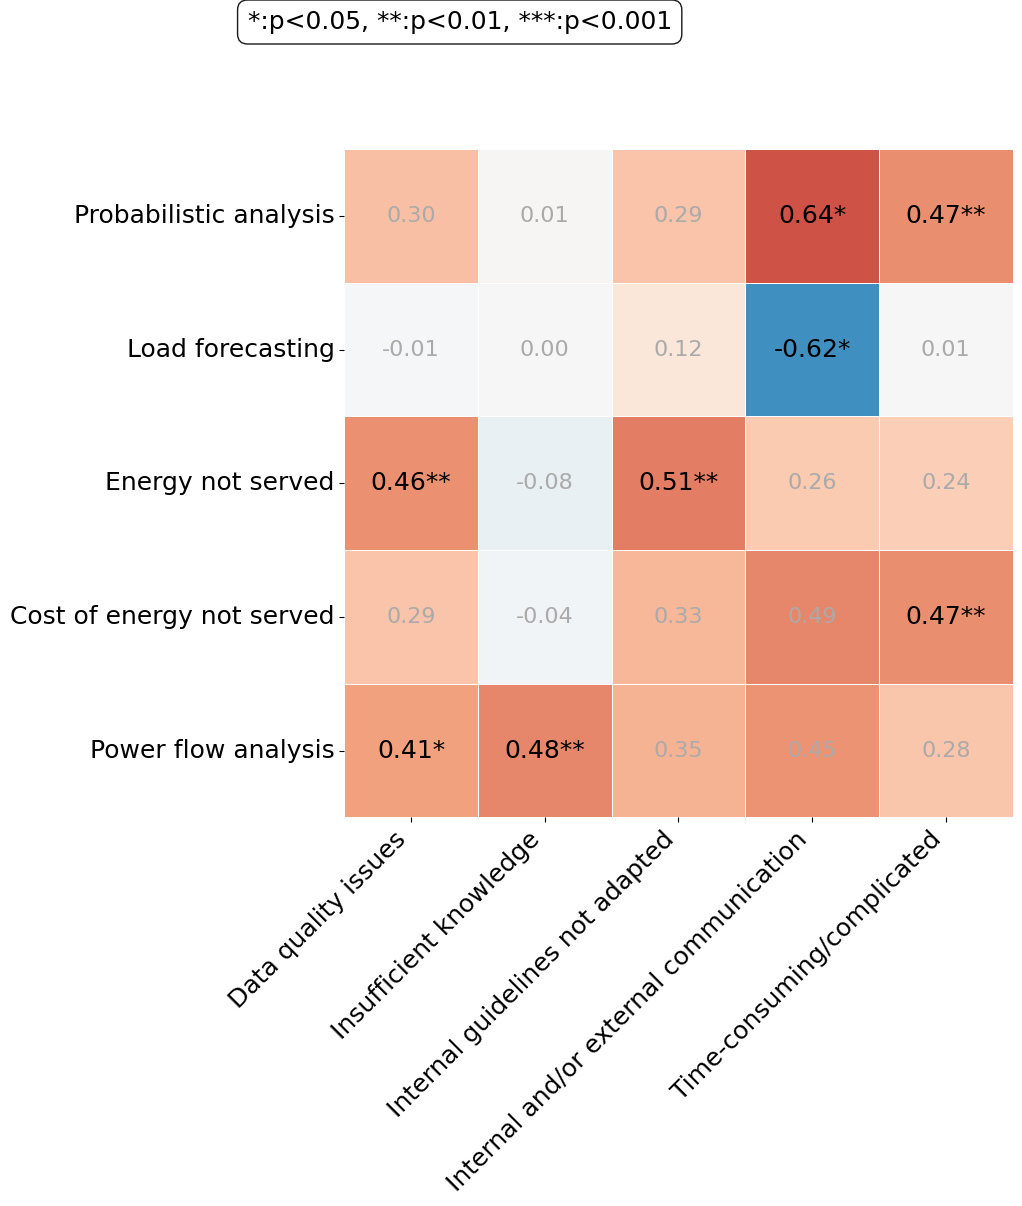

In [76]:
# 1. METHODS vs BARRIERS

# Plot heatmap (uses full data, shows all correlations)
plot_correlation_heatmap_with_significance(
    corr_mb, pval_mb,
    #f'Correlation: Methods vs Barriers ({DATA_SOURCE.upper()} data)',
    save_path=f'plots/correlation_method_barrier_{DATA_SOURCE}.pdf',
    figsize=(14, 10),
    top_k=5,
    min_p=0.05,
    min_r=0.4,
    fontsize=18
)

In [319]:
plot_single_correlation_scatter(
    method_plot_df, barrier_plot_df, 
    corr_mb, pval_mb,
    #method_name='probabilistic analysis', #'failure modeling','probabilistic analysis', 'power flow analysis','time series analysis'
    #barrier_name='Internal and/or external communication', #['Data Quality Issues', 'Insufficient Knowledge','Insufficient Tool Support', 'Internal Guidelines Not Adapted','Internal and/or external communication', 'Other Barriers','Results Difficult to Interpret', 'Time-consuming/Complicated']
    save_path='plots/time_series_analysis_vs_complicated.pdf'
)

KeyError: 'power flow analysis'

In [ ]:
# Plot scatter with FILTERED data
plot_correlation_scatter_grid_improved(
    method_plot_df, barrier_plot_df, corr_mb, pval_mb,
    top_n=12, min_pval=0.05,
    save_path=f'plots/correlation_method_barrier_scatter_{DATA_SOURCE}.pdf'
)

#### Method vs. softwares plot

In [ ]:

# FILTER DATA FOR SCATTER PLOT
if DATA_SOURCE == 'q':
    method_plot_df = method_df_filt.loc[q_indices]
    software_plot_df = software_df_filt.loc[q_indices]
elif DATA_SOURCE == 'i':
    method_plot_df = method_df_filt.loc[i_indices]
    software_plot_df = software_df_filt.loc[i_indices]
else:
    method_plot_df = method_df_filt
    software_plot_df = software_df_filt


In [ ]:

# 2. METHODS vs SOFTWARE

plot_correlation_heatmap_with_significance(
    corr_ms, pval_ms,
    f'Correlation: Methods vs Software ({DATA_SOURCE.upper()} data)',
    save_path=f'plots/correlation_method_software_{DATA_SOURCE}.pdf',
    figsize=(18, 14),
    top_k=10
)


plot_correlation_scatter_grid_improved(
    method_plot_df, software_plot_df, corr_ms, pval_ms,
    top_n=9, min_pval=0.05,
    save_path=f'plots/correlation_method_software_scatter_{DATA_SOURCE}.pdf'
)

#### Softwares vs barriers plots

In [ ]:
# FILTER DATA FOR SCATTER PLOT
if DATA_SOURCE == 'q':
    software_plot_df = software_df_filt.loc[q_indices]
    barrier_plot_df = barrier_df_filt.loc[q_indices]
elif DATA_SOURCE == 'i':
    software_plot_df = software_df_filt.loc[i_indices]
    barrier_plot_df = barrier_df_filt.loc[i_indices]
else:
    software_plot_df = software_df_filt
    barrier_plot_df = barrier_df_filt

In [ ]:



# 3. SOFTWARE vs BARRIERS


plot_correlation_heatmap_with_significance(
    corr_sb, pval_sb,
    f'Correlation: Software vs Barriers ({DATA_SOURCE.upper()} data)',
    save_path=f'plots/correlation_software_barrier_{DATA_SOURCE}.pdf',
    figsize=(14, 10),
    top_k=15
)


plot_correlation_scatter_grid_improved(
    software_plot_df, barrier_plot_df, corr_sb, pval_sb,
    top_n=9, min_pval=0.05,
    save_path=f'plots/correlation_software_barrier_scatter_{DATA_SOURCE}.pdf'
)


## Compare results with IEEE data

In [ ]:
df_industry_software = pd.DataFrame.from_dict(q_usage, orient='index')
df_ieee_software = df_ieee_software.set_index('software_name')


In [ ]:
df_software_comparison_total = df_software_comparison[['Software', 'Total Count', 'Total (%)']].rename(
    columns={'Total Count': 'count', 'Total (%)': 'percentage'}
)
df_software_comparison_total = df_software_comparison_total.set_index('Software')

In [ ]:
def plot_software_comparison_simple(df1, df2, name_mapping=None,
                                   count_col='count',
                                   dataset1_label='Dataset 1',
                                   dataset2_label='Dataset 2',
                                   title='Software Comparison',
                                   save_path=None, figsize=(12, 8),
                                   sort_by='total', top_n=None):
    """
    Compare software usage between two DataFrames (both with software as index)
    
    Parameters:
    -----------
    df1 : DataFrame
        First dataset with software names as index
    df2 : DataFrame
        Second dataset with software names as index
    name_mapping : dict, optional
        {original_name: standard_name} for both datasets
    count_col : str
        Column name containing counts (same in both DataFrames)
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Apply name mapping if provided
    if name_mapping:
        df1 = df1.copy()
        df2 = df2.copy()
        df1.index = df1.index.map(lambda x: name_mapping.get(x, x))
        df2.index = df2.index.map(lambda x: name_mapping.get(x, x))
        
        # Group by index after mapping (in case multiple names map to same)
        df1 = df1.groupby(df1.index)[count_col].sum().to_frame(name=count_col)
        df2 = df2.groupby(df2.index)[count_col].sum().to_frame(name=count_col)
    
    # Merge on index
    combined = pd.merge(
        df1[[count_col]], df2[[count_col]], 
        left_index=True, right_index=True, 
        how='outer', suffixes=('_1', '_2')
    ).fillna(0)
    
    combined.columns = ['count1', 'count2']
    combined['total'] = combined['count1'] + combined['count2']
    
    # Sort
    if sort_by == 'total':
        combined = combined.sort_values('total', ascending=False)
    elif sort_by == 'dataset1':
        combined = combined.sort_values('count1', ascending=False)
    elif sort_by == 'dataset2':
        combined = combined.sort_values('count2', ascending=False)
    elif sort_by == 'name':
        combined = combined.sort_index()
    
    # Top N filter
    if top_n:
        combined = combined.head(top_n)
    
    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    
    x = np.arange(len(combined))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, combined['count1'], width, 
                   label=dataset1_label, color='steelblue', alpha=0.8,
                   edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x + width/2, combined['count2'], width,
                   label=dataset2_label, color='coral', alpha=0.8,
                   edgecolor='black', linewidth=0.5)
    
    # Value labels
    #for bars in [bars1, bars2]:
    #    for bar in bars:
    #        height = bar.get_height()
    #        if height > 0:
    ##            ax.text(bar.get_x() + bar.get_width()/2., height,
    #                   f'{int(height)}',
    #                   ha='center', va='bottom', fontsize=9)
    
    # Formatting
    ax.set_xlabel('Software', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Usage ({count_col} of responses)', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(combined.index, rotation=45, ha='right')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
    
    plt.show()
    plt.close(fig)
    
    return combined

In [ ]:
# Check column names
print("df_ieee_software columns:", df_ieee_software.columns.tolist())

print("df_software_comparison_total columns:", df_software_comparison_total.columns.tolist())


In [ ]:
comparison = plot_software_comparison_simple(
    df_software_comparison_total, df_ieee_software,
    name_mapping=SOFTWARE_COMPARISON_MAPPING,
    count_col='percentage',
    dataset1_label='Norwegian DSOs (n=24)',
    dataset2_label='Industry Survey (n=50)',
    title='Software Usage Comparison',
    save_path='plots/software_comparison.pdf',
    sort_by='total',
    top_n=50
)

print("\n=== Comparison Table ===")
print(comparison)